
METRICS
          model   N      MAE     RMSE       R2     Bias
 High-bias + J0 389 0.005572 0.008211 0.819191 0.000473
 High-bias only 389 0.005412 0.008131 0.822700 0.000512
Ensemble (mean) 389 0.005064 0.007693 0.841255 0.000493

Paired test, High-bias + J0 vs High-bias only (absolute error):
  mean AE difference : +0.000160
  Wilcoxon p         : 0.4313
  paired t-test p    : 0.4665
  High-bias + J0 better on 190 / 389 modules

Ensemble vs average single model (absolute error):
  mean AE difference : -0.000428
  Wilcoxon p         : 0.000000
  ensemble better on 173 / 389 modules
  beats BEST single on 49 / 389 modules

Prediction correlation : 0.9554
Residual correlation   : 0.7724

NOTE: CONTROL_CSV is not set. Part of the ensemble gain is plain
variance reduction from averaging two models, not the J0 channel.
Train a second high-bias-only model with a different seed and set
CONTROL_CSV to separate the two effects.


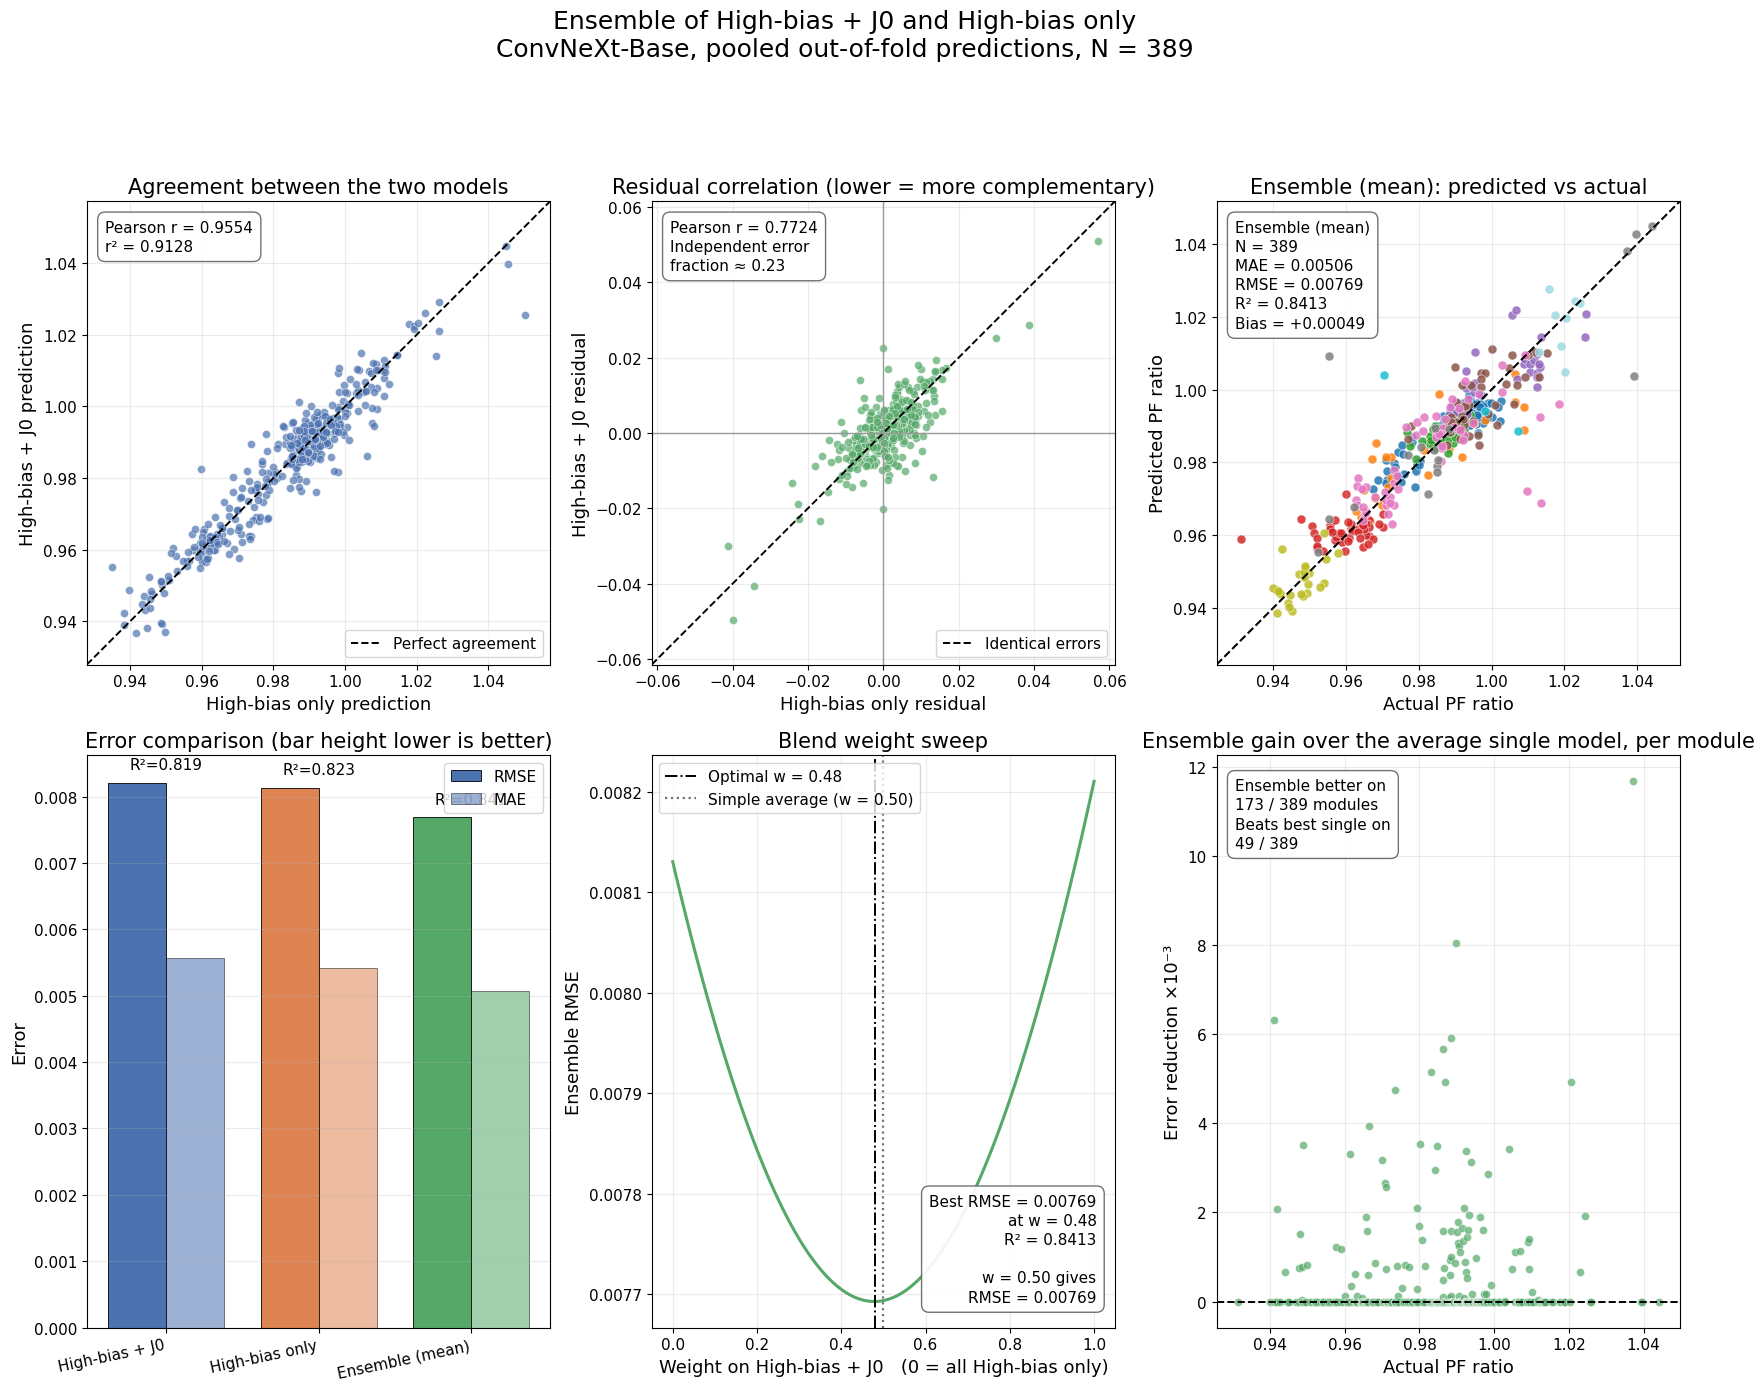


Saved:
- ensemble_convnext_highbias_j0_vs_highbias_figure.png
- ensemble_convnext_highbias_j0_vs_highbias_figure.pdf
- ensemble_convnext_highbias_j0_vs_highbias_predictions.csv
- ensemble_convnext_highbias_j0_vs_highbias_metrics.csv


In [1]:
"""
Ensemble analysis: high-bias + J0  vs  high-bias only

Reads the two out-of-fold prediction files, averages them, and produces a
multi-panel figure plus a metrics table.

IMPORTANT CAVEAT FOR THE WRITE-UP
---------------------------------
Averaging ANY two independently-trained models reduces prediction variance and
usually improves R2, whether or not their inputs differ. Part of the ensemble
gain here is therefore plain variance reduction, not physics.

To claim the J0 channel contributes complementary information, run the control:
train a second high-bias-only model with a different seed and average those two.
Then compare:

    gain from (high+J0) + (high only)      <- what this script measures
    gain from (high only A) + (high only B) <- the control

Only the excess of the first over the second is attributable to the J0 map.
Set CONTROL_CSV below once you have that second high-bias-only run and the
script will compute both.
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import mean_absolute_error, r2_score


# =========================================================
# CONFIG
# =========================================================
MODEL_A_CSV = "cv5_convnext_base_highbias_j0_oof_test_predictions.csv"
MODEL_B_CSV = "cv5_convnext_base_highbias_only_oof_test_predictions.csv"

MODEL_A_LABEL = "High-bias + J0"
MODEL_B_LABEL = "High-bias only"
ENSEMBLE_LABEL = "Ensemble (mean)"

# Optional control: a second high-bias-only run with a different seed.
# Leave as None until you have it.
CONTROL_CSV = None
CONTROL_LABEL = "High-bias only (seed B)"

# Blend weight: predicted = W * A + (1 - W) * B. 0.5 = simple average.
ENSEMBLE_WEIGHT = 0.5

OUTPUT_PREFIX = "ensemble_convnext_highbias_j0_vs_highbias"

# ---- Font sizes: change these to control the figure text ----
FONT = {
    "title": 15,          # panel titles
    "suptitle": 18,       # figure title
    "axis_label": 13,     # x and y axis labels
    "tick": 11,           # tick numbers
    "legend": 11,
    "annotation": 11,     # metric boxes inside panels
}

# ---- Other appearance ----
FIGSIZE = (17, 14)
DPI = 300
POINT_SIZE = 34
POINT_ALPHA = 0.70
COLOR_A = "#4C72B0"
COLOR_B = "#DD8452"
COLOR_ENSEMBLE = "#55A868"


def apply_font_sizes():
    plt.rcParams.update({
        "axes.titlesize": FONT["title"],
        "axes.labelsize": FONT["axis_label"],
        "xtick.labelsize": FONT["tick"],
        "ytick.labelsize": FONT["tick"],
        "legend.fontsize": FONT["legend"],
        "figure.titlesize": FONT["suptitle"],
    })


# =========================================================
# LOAD AND ALIGN
# =========================================================
def load_predictions(path, label):
    if not os.path.exists(path):
        raise FileNotFoundError(f"{label}: file not found -> {path}")

    df = pd.read_csv(path)

    needed = {"sample_uid", "actual_pf_ratio", "predicted_pf_ratio"}
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"{label} is missing columns: {sorted(missing)}")

    if df["sample_uid"].duplicated().any():
        raise ValueError(f"{label} contains duplicate sample_uid values.")

    return df.set_index("sample_uid").sort_index()


def metrics(actual, predicted):
    residual = predicted - actual
    return {
        "N": len(actual),
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": float(np.sqrt(np.mean(residual ** 2))),
        "R2": r2_score(actual, predicted),
        "Bias": float(np.mean(residual)),
    }


def metrics_text(name, m):
    return (
        f"{name}\n"
        f"N = {m['N']}\n"
        f"MAE = {m['MAE']:.5f}\n"
        f"RMSE = {m['RMSE']:.5f}\n"
        f"R² = {m['R2']:.4f}\n"
        f"Bias = {m['Bias']:+.5f}"
    )


def annotate(ax, text, loc="upper left"):
    x, y, ha, va = (0.04, 0.96, "left", "top")
    if loc == "lower right":
        x, y, ha, va = (0.96, 0.04, "right", "bottom")

    ax.text(
        x, y, text, transform=ax.transAxes, ha=ha, va=va,
        fontsize=FONT["annotation"], linespacing=1.35,
        bbox=dict(boxstyle="round,pad=0.5", facecolor="white",
                  edgecolor="0.4", alpha=0.92),
        zorder=6,
    )


# =========================================================
# PANELS
# =========================================================
def panel_model_correlation(ax, pred_a, pred_b):
    """Do the two models agree? Tight cloud = redundant, spread = complementary."""
    lo = min(pred_a.min(), pred_b.min())
    hi = max(pred_a.max(), pred_b.max())
    pad = (hi - lo) * 0.06
    lo, hi = lo - pad, hi + pad

    ax.scatter(pred_b, pred_a, s=POINT_SIZE, alpha=POINT_ALPHA,
               color=COLOR_A, edgecolors="white", linewidths=0.4)
    ax.plot([lo, hi], [lo, hi], "--", color="black", linewidth=1.4,
            label="Perfect agreement")

    r = np.corrcoef(pred_a, pred_b)[0, 1]

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(f"{MODEL_B_LABEL} prediction")
    ax.set_ylabel(f"{MODEL_A_LABEL} prediction")
    ax.set_title("Agreement between the two models")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="lower right")

    annotate(ax, f"Pearson r = {r:.4f}\nr² = {r ** 2:.4f}")


def panel_residual_correlation(ax, res_a, res_b):
    """
    The key panel for the ensemble argument. Residual correlation well below 1
    means the two models fail on different modules, which is exactly what makes
    averaging help.
    """
    lim = max(np.abs(res_a).max(), np.abs(res_b).max()) * 1.08

    ax.scatter(res_b, res_a, s=POINT_SIZE, alpha=POINT_ALPHA,
               color=COLOR_ENSEMBLE, edgecolors="white", linewidths=0.4)
    ax.plot([-lim, lim], [-lim, lim], "--", color="black", linewidth=1.4,
            label="Identical errors")
    ax.axhline(0, color="0.6", linewidth=1.0)
    ax.axvline(0, color="0.6", linewidth=1.0)

    r = np.corrcoef(res_a, res_b)[0, 1]

    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(f"{MODEL_B_LABEL} residual")
    ax.set_ylabel(f"{MODEL_A_LABEL} residual")
    ax.set_title("Residual correlation (lower = more complementary)")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="lower right")

    annotate(
        ax,
        f"Pearson r = {r:.4f}\n"
        f"Independent error\nfraction ≈ {1 - r:.2f}",
    )


def panel_ensemble_scatter(ax, actual, pred_ens, make_values=None):
    lo = min(actual.min(), pred_ens.min())
    hi = max(actual.max(), pred_ens.max())
    pad = (hi - lo) * 0.06
    lo, hi = lo - pad, hi + pad

    if make_values is not None:
        makes = sorted(pd.Series(make_values).astype(str).unique())
        cmap = plt.colormaps.get_cmap("tab20")
        palette = {m: cmap(i / max(1, len(makes) - 1)) for i, m in enumerate(makes)}

        for m in makes:
            sel = np.asarray(make_values).astype(str) == m
            ax.scatter(actual[sel], pred_ens[sel], s=POINT_SIZE + 8,
                       color=palette[m], alpha=0.85, edgecolors="white",
                       linewidths=0.4, label=m)
    else:
        ax.scatter(actual, pred_ens, s=POINT_SIZE + 8, color=COLOR_ENSEMBLE,
                   alpha=0.85, edgecolors="white", linewidths=0.4)

    ax.plot([lo, hi], [lo, hi], "--", color="black", linewidth=1.5)

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Actual PF ratio")
    ax.set_ylabel("Predicted PF ratio")
    ax.set_title(f"{ENSEMBLE_LABEL}: predicted vs actual")
    ax.grid(True, alpha=0.25)

    annotate(ax, metrics_text(ENSEMBLE_LABEL, metrics(actual, pred_ens)))


def panel_metric_bars(ax, rows):
    """Side-by-side RMSE and MAE for every model."""
    names = [r["model"] for r in rows]
    x = np.arange(len(names))
    width = 0.38

    colors = [COLOR_A, COLOR_B, COLOR_ENSEMBLE, "0.55"][:len(names)]

    ax.bar(x - width / 2, [r["RMSE"] for r in rows], width,
           label="RMSE", color=colors, edgecolor="black", linewidth=0.6)
    ax.bar(x + width / 2, [r["MAE"] for r in rows], width,
           label="MAE", color=colors, alpha=0.55,
           edgecolor="black", linewidth=0.6)

    for i, r in enumerate(rows):
        ax.text(i, max(r["RMSE"], r["MAE"]) * 1.02, f"R²={r['R2']:.3f}",
                ha="center", va="bottom", fontsize=FONT["annotation"])

    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=12, ha="right")
    ax.set_ylabel("Error")
    ax.set_title("Error comparison (bar height lower is better)")
    ax.grid(True, alpha=0.25, axis="y")
    ax.legend()


def panel_weight_sweep(ax, actual, pred_a, pred_b):
    """
    How does performance vary with blend weight? A minimum near the middle is
    evidence both models carry useful and partly independent information.
    """
    weights = np.linspace(0, 1, 101)
    rmses, r2s = [], []

    for w in weights:
        p = w * pred_a + (1 - w) * pred_b
        rmses.append(np.sqrt(np.mean((p - actual) ** 2)))
        r2s.append(r2_score(actual, p))

    rmses = np.asarray(rmses)
    best = int(np.argmin(rmses))

    ax.plot(weights, rmses, linewidth=2.2, color=COLOR_ENSEMBLE)
    ax.axvline(weights[best], linestyle="-.", color="black", linewidth=1.4,
               label=f"Optimal w = {weights[best]:.2f}")
    ax.axvline(0.5, linestyle=":", color="0.45", linewidth=1.6,
               label="Simple average (w = 0.50)")

    ax.set_xlabel(f"Weight on {MODEL_A_LABEL}   (0 = all {MODEL_B_LABEL})")
    ax.set_ylabel("Ensemble RMSE")
    ax.set_title("Blend weight sweep")
    ax.grid(True, alpha=0.25)
    ax.legend()

    annotate(
        ax,
        f"Best RMSE = {rmses[best]:.5f}\n"
        f"at w = {weights[best]:.2f}\n"
        f"R² = {r2s[best]:.4f}\n\n"
        f"w = 0.50 gives\nRMSE = {rmses[50]:.5f}",
        loc="lower right",
    )

    return float(weights[best]), float(rmses[best])


def panel_per_module_gain(ax, actual, pred_a, pred_b, pred_ens):
    """
    Where does the ensemble actually help? Positive bars = ensemble beat the
    better of the two single models on that module.
    """
    ae_a = np.abs(pred_a - actual)
    ae_b = np.abs(pred_b - actual)
    ae_ens = np.abs(pred_ens - actual)

    best_single = np.minimum(ae_a, ae_b)
    gain_vs_mean_single = (ae_a + ae_b) / 2 - ae_ens

    order = np.argsort(actual)

    ax.scatter(actual[order], gain_vs_mean_single[order] * 1000,
               s=POINT_SIZE, alpha=POINT_ALPHA, color=COLOR_ENSEMBLE,
               edgecolors="white", linewidths=0.4)
    ax.axhline(0, linestyle="--", color="black", linewidth=1.4)

    ax.set_xlabel("Actual PF ratio")
    ax.set_ylabel("Error reduction ×10⁻³")
    ax.set_title("Ensemble gain over the average single model, per module")
    ax.grid(True, alpha=0.25)

    annotate(
        ax,
        f"Ensemble better on\n{int((gain_vs_mean_single > 0).sum())} / {len(actual)} modules\n"
        f"Beats best single on\n{int((ae_ens < best_single).sum())} / {len(actual)}",
    )


# =========================================================
# MAIN
# =========================================================
def main():
    apply_font_sizes()

    a = load_predictions(MODEL_A_CSV, MODEL_A_LABEL)
    b = load_predictions(MODEL_B_CSV, MODEL_B_LABEL)

    common = a.index.intersection(b.index)
    if len(common) == 0:
        raise ValueError("The two files share no sample_uid values.")

    if len(common) < len(a) or len(common) < len(b):
        print(
            f"WARNING: files do not cover the same modules. "
            f"A has {len(a)}, B has {len(b)}, using the {len(common)} in common."
        )

    a = a.loc[common]
    b = b.loc[common]

    actual = a["actual_pf_ratio"].to_numpy()
    actual_b = b["actual_pf_ratio"].to_numpy()

    if not np.allclose(actual, actual_b, atol=1e-9):
        raise ValueError(
            "Ground-truth PF ratios disagree between the two files. "
            "The runs are not on the same targets."
        )

    pred_a = a["predicted_pf_ratio"].to_numpy()
    pred_b = b["predicted_pf_ratio"].to_numpy()
    pred_ens = ENSEMBLE_WEIGHT * pred_a + (1 - ENSEMBLE_WEIGHT) * pred_b

    res_a = pred_a - actual
    res_b = pred_b - actual

    make_values = a["make_plot"].to_numpy() if "make_plot" in a.columns else None

    # ---- Metrics table ----
    rows = [
        {"model": MODEL_A_LABEL, **metrics(actual, pred_a)},
        {"model": MODEL_B_LABEL, **metrics(actual, pred_b)},
        {"model": ENSEMBLE_LABEL, **metrics(actual, pred_ens)},
    ]

    control_pred = None
    if CONTROL_CSV:
        c = load_predictions(CONTROL_CSV, CONTROL_LABEL).loc[common]
        control_pred = c["predicted_pf_ratio"].to_numpy()
        control_ens = 0.5 * pred_b + 0.5 * control_pred
        rows.append({"model": CONTROL_LABEL, **metrics(actual, control_pred)})
        rows.append({
            "model": "Control ensemble (high-only ×2)",
            **metrics(actual, control_ens),
        })

    table = pd.DataFrame(rows)

    print("\n" + "=" * 78)
    print("METRICS")
    print("=" * 78)
    print(table.to_string(index=False, float_format=lambda v: f"{v:.6f}"))

    # ---- Significance of the single-model difference ----
    w = stats.wilcoxon(np.abs(res_a), np.abs(res_b))
    t = stats.ttest_rel(np.abs(res_a), np.abs(res_b))

    print(f"\nPaired test, {MODEL_A_LABEL} vs {MODEL_B_LABEL} (absolute error):")
    print(f"  mean AE difference : {np.mean(np.abs(res_a) - np.abs(res_b)):+.6f}")
    print(f"  Wilcoxon p         : {w.pvalue:.4f}")
    print(f"  paired t-test p    : {t.pvalue:.4f}")
    print(f"  {MODEL_A_LABEL} better on "
          f"{int((np.abs(res_a) < np.abs(res_b)).sum())} / {len(actual)} modules")

    # ---- Significance of the ensemble gain ----
    ae_ens = np.abs(pred_ens - actual)
    ae_best_single = np.minimum(np.abs(res_a), np.abs(res_b))
    ae_mean_single = (np.abs(res_a) + np.abs(res_b)) / 2

    w_ens = stats.wilcoxon(ae_ens, ae_mean_single)
    print(f"\nEnsemble vs average single model (absolute error):")
    print(f"  mean AE difference : {np.mean(ae_ens - ae_mean_single):+.6f}")
    print(f"  Wilcoxon p         : {w_ens.pvalue:.6f}")
    print(f"  ensemble better on "
          f"{int((ae_ens < ae_mean_single).sum())} / {len(actual)} modules")
    print(f"  beats BEST single on "
          f"{int((ae_ens < ae_best_single).sum())} / {len(actual)} modules")

    print(f"\nPrediction correlation : {np.corrcoef(pred_a, pred_b)[0, 1]:.4f}")
    print(f"Residual correlation   : {np.corrcoef(res_a, res_b)[0, 1]:.4f}")

    if CONTROL_CSV is None:
        print(
            "\nNOTE: CONTROL_CSV is not set. Part of the ensemble gain is plain\n"
            "variance reduction from averaging two models, not the J0 channel.\n"
            "Train a second high-bias-only model with a different seed and set\n"
            "CONTROL_CSV to separate the two effects."
        )

    # ---- Figure ----
    fig, axes = plt.subplots(2, 3, figsize=FIGSIZE)

    panel_model_correlation(axes[0, 0], pred_a, pred_b)
    panel_residual_correlation(axes[0, 1], res_a, res_b)
    panel_ensemble_scatter(axes[0, 2], actual, pred_ens, make_values)
    panel_metric_bars(axes[1, 0], rows)
    best_w, best_rmse = panel_weight_sweep(axes[1, 1], actual, pred_a, pred_b)
    panel_per_module_gain(axes[1, 2], actual, pred_a, pred_b, pred_ens)

    fig.suptitle(
        f"Ensemble of {MODEL_A_LABEL} and {MODEL_B_LABEL}\n"
        f"ConvNeXt-Base, pooled out-of-fold predictions, N = {len(actual)}",
        y=0.99,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    fig.savefig(f"{OUTPUT_PREFIX}_figure.png", dpi=DPI, bbox_inches="tight")
    fig.savefig(f"{OUTPUT_PREFIX}_figure.pdf", bbox_inches="tight")
    plt.show()

    # ---- Save ----
    out = a[[c for c in ["ELHPath", "Make", "make_plot", "fold"] if c in a.columns]].copy()
    out["actual_pf_ratio"] = actual
    out[f"pred_{MODEL_A_LABEL}"] = pred_a
    out[f"pred_{MODEL_B_LABEL}"] = pred_b
    out["pred_ensemble"] = pred_ens
    out["residual_ensemble"] = pred_ens - actual
    out["absolute_error_ensemble"] = np.abs(pred_ens - actual)

    if control_pred is not None:
        out[f"pred_{CONTROL_LABEL}"] = control_pred

    out.to_csv(f"{OUTPUT_PREFIX}_predictions.csv")
    table.to_csv(f"{OUTPUT_PREFIX}_metrics.csv", index=False)

    print("\nSaved:")
    print(f"- {OUTPUT_PREFIX}_figure.png")
    print(f"- {OUTPUT_PREFIX}_figure.pdf")
    print(f"- {OUTPUT_PREFIX}_predictions.csv")
    print(f"- {OUTPUT_PREFIX}_metrics.csv")


if __name__ == "__main__":
    main()



METRICS
                  model   N      MAE     RMSE       R2     Bias
High-bias only (seed A) 389 0.005410 0.008166 0.821177 0.000121
High-bias only (seed B) 389 0.005412 0.008131 0.822700 0.000512
        Ensemble (mean) 389 0.005155 0.007905 0.832388 0.000317

Paired test, High-bias only (seed A) vs High-bias only (seed B) (absolute error):
  mean AE difference : -0.000002
  Wilcoxon p         : 0.7476
  paired t-test p    : 0.9920
  High-bias only (seed A) better on 186 / 389 modules

Ensemble vs average single model (absolute error):
  mean AE difference : -0.000255
  Wilcoxon p         : 0.000000
  ensemble better on 153 / 389 modules
  beats BEST single on 39 / 389 modules

Prediction correlation : 0.9790
Residual correlation   : 0.8835

NOTE: CONTROL_CSV is not set. Part of the ensemble gain is plain
variance reduction from averaging two models, not the J0 channel.
Train a second high-bias-only model with a different seed and set
CONTROL_CSV to separate the two effects.


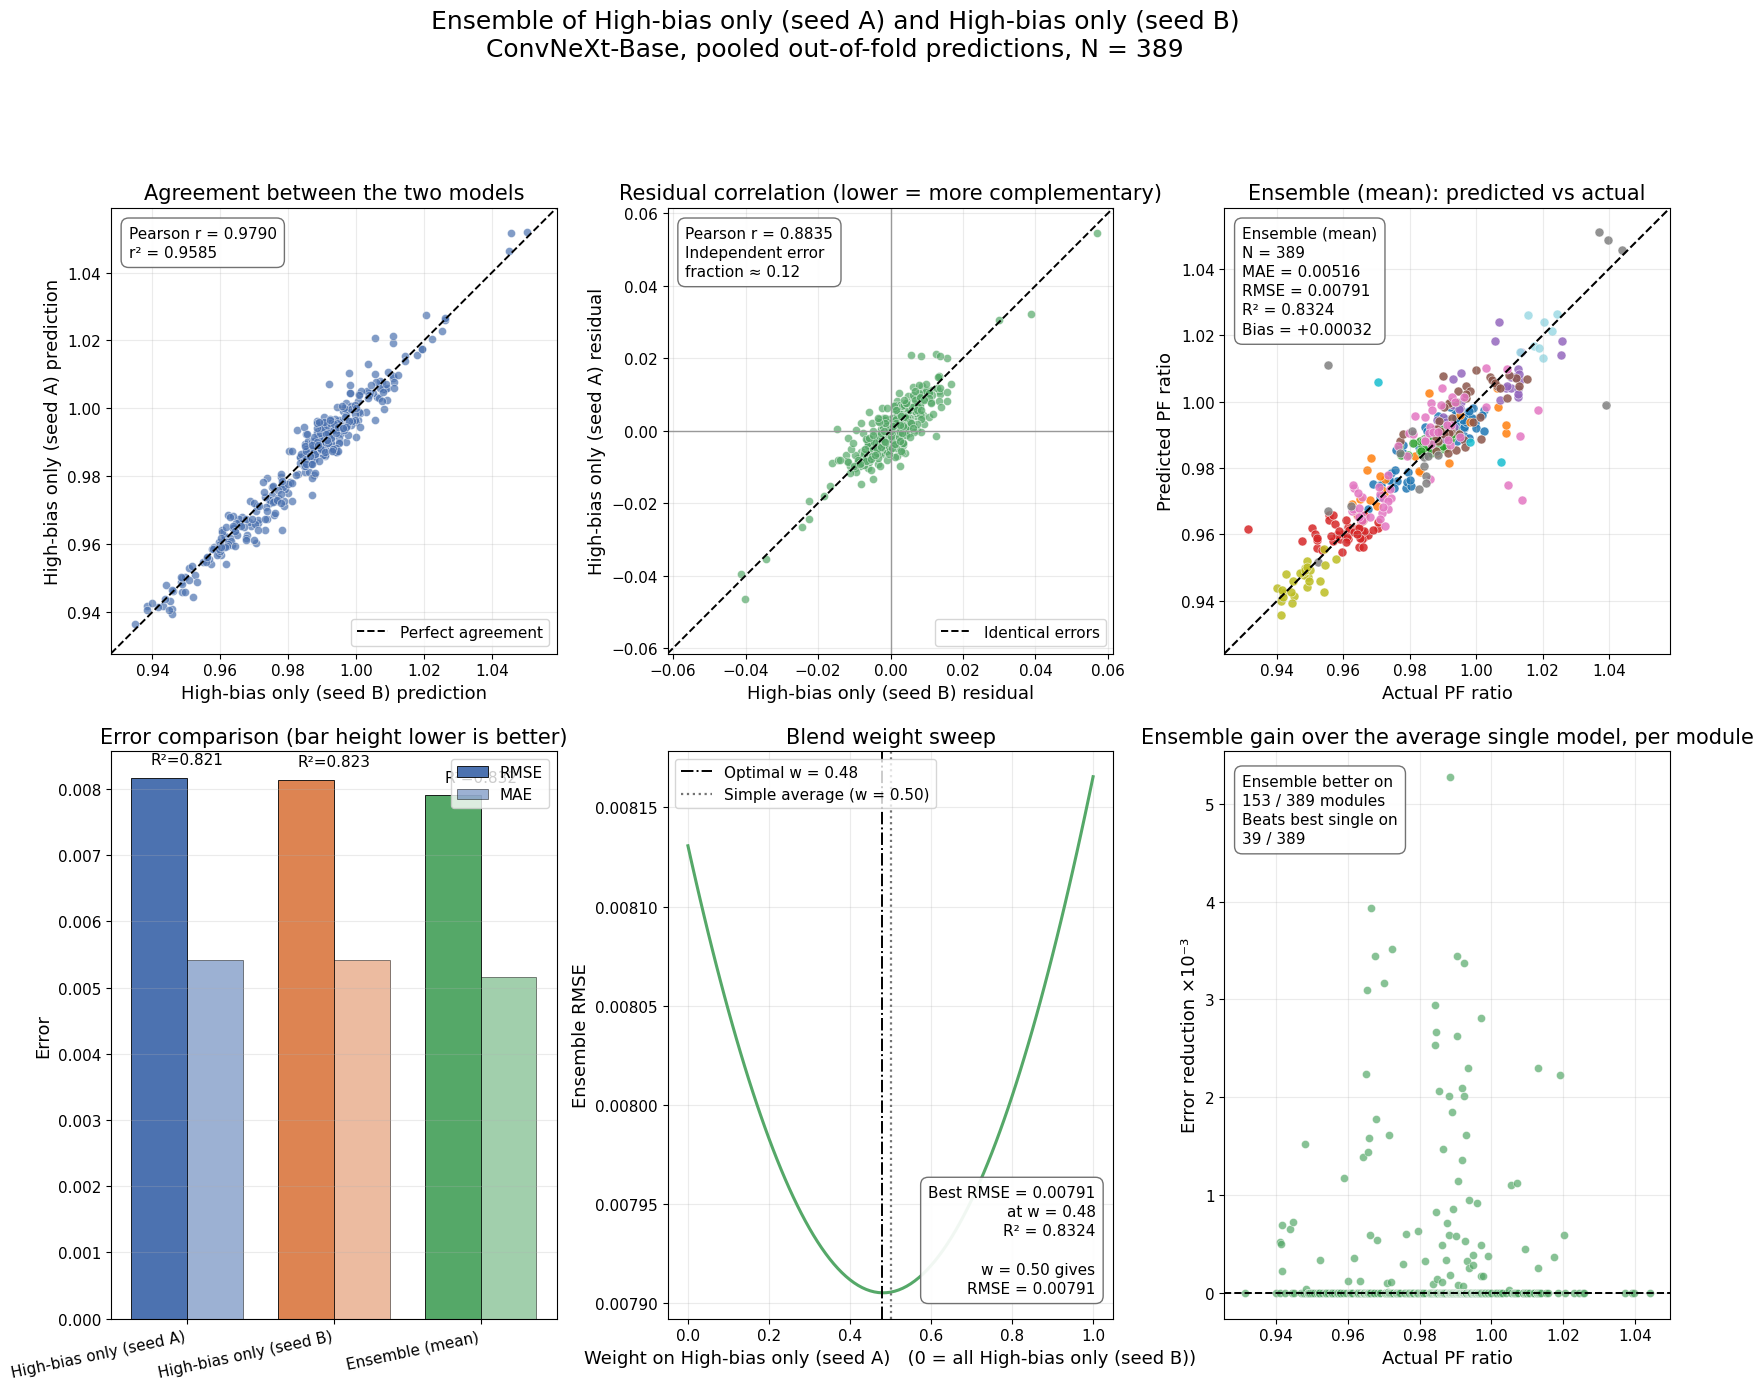


Saved:
- ensemble_convnext_highbias_only_vs_highbias_only_figure.png
- ensemble_convnext_highbias_only_vs_highbias_only_figure.pdf
- ensemble_convnext_highbias_only_vs_highbias_only_predictions.csv
- ensemble_convnext_highbias_only_vs_highbias_only_metrics.csv


In [2]:
"""
Ensemble analysis: high-bias + J0  vs  high-bias only

Reads the two out-of-fold prediction files, averages them, and produces a
multi-panel figure plus a metrics table.

IMPORTANT CAVEAT FOR THE WRITE-UP
---------------------------------
Averaging ANY two independently-trained models reduces prediction variance and
usually improves R2, whether or not their inputs differ. Part of the ensemble
gain here is therefore plain variance reduction, not physics.

To claim the J0 channel contributes complementary information, run the control:
train a second high-bias-only model with a different seed and average those two.
Then compare:

    gain from (high+J0) + (high only)      <- what this script measures
    gain from (high only A) + (high only B) <- the control

Only the excess of the first over the second is attributable to the J0 map.
Set CONTROL_CSV below once you have that second high-bias-only run and the
script will compute both.
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import mean_absolute_error, r2_score


# =========================================================
# CONFIG
# =========================================================
MODEL_A_CSV = "cv5_convnext_base_highbias_only_seedB_oof_test_predictions.csv"
MODEL_B_CSV = "cv5_convnext_base_highbias_only_oof_test_predictions.csv"

MODEL_A_LABEL = "High-bias only (seed A)"
MODEL_B_LABEL = "High-bias only (seed B)"
ENSEMBLE_LABEL = "Ensemble (mean)"

# Optional control: a second high-bias-only run with a different seed.
# Leave as None until you have it.
CONTROL_CSV = None
CONTROL_LABEL = "High-bias only (seed B)"

# Blend weight: predicted = W * A + (1 - W) * B. 0.5 = simple average.
ENSEMBLE_WEIGHT = 0.5

OUTPUT_PREFIX = "ensemble_convnext_highbias_only_vs_highbias_only"

# ---- Font sizes: change these to control the figure text ----
FONT = {
    "title": 15,          # panel titles
    "suptitle": 18,       # figure title
    "axis_label": 13,     # x and y axis labels
    "tick": 11,           # tick numbers
    "legend": 11,
    "annotation": 11,     # metric boxes inside panels
}

# ---- Other appearance ----
FIGSIZE = (17, 14)
DPI = 300
POINT_SIZE = 34
POINT_ALPHA = 0.70
COLOR_A = "#4C72B0"
COLOR_B = "#DD8452"
COLOR_ENSEMBLE = "#55A868"


def apply_font_sizes():
    plt.rcParams.update({
        "axes.titlesize": FONT["title"],
        "axes.labelsize": FONT["axis_label"],
        "xtick.labelsize": FONT["tick"],
        "ytick.labelsize": FONT["tick"],
        "legend.fontsize": FONT["legend"],
        "figure.titlesize": FONT["suptitle"],
    })


# =========================================================
# LOAD AND ALIGN
# =========================================================
def load_predictions(path, label):
    if not os.path.exists(path):
        raise FileNotFoundError(f"{label}: file not found -> {path}")

    df = pd.read_csv(path)

    needed = {"sample_uid", "actual_pf_ratio", "predicted_pf_ratio"}
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"{label} is missing columns: {sorted(missing)}")

    if df["sample_uid"].duplicated().any():
        raise ValueError(f"{label} contains duplicate sample_uid values.")

    return df.set_index("sample_uid").sort_index()


def metrics(actual, predicted):
    residual = predicted - actual
    return {
        "N": len(actual),
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": float(np.sqrt(np.mean(residual ** 2))),
        "R2": r2_score(actual, predicted),
        "Bias": float(np.mean(residual)),
    }


def metrics_text(name, m):
    return (
        f"{name}\n"
        f"N = {m['N']}\n"
        f"MAE = {m['MAE']:.5f}\n"
        f"RMSE = {m['RMSE']:.5f}\n"
        f"R² = {m['R2']:.4f}\n"
        f"Bias = {m['Bias']:+.5f}"
    )


def annotate(ax, text, loc="upper left"):
    x, y, ha, va = (0.04, 0.96, "left", "top")
    if loc == "lower right":
        x, y, ha, va = (0.96, 0.04, "right", "bottom")

    ax.text(
        x, y, text, transform=ax.transAxes, ha=ha, va=va,
        fontsize=FONT["annotation"], linespacing=1.35,
        bbox=dict(boxstyle="round,pad=0.5", facecolor="white",
                  edgecolor="0.4", alpha=0.92),
        zorder=6,
    )


# =========================================================
# PANELS
# =========================================================
def panel_model_correlation(ax, pred_a, pred_b):
    """Do the two models agree? Tight cloud = redundant, spread = complementary."""
    lo = min(pred_a.min(), pred_b.min())
    hi = max(pred_a.max(), pred_b.max())
    pad = (hi - lo) * 0.06
    lo, hi = lo - pad, hi + pad

    ax.scatter(pred_b, pred_a, s=POINT_SIZE, alpha=POINT_ALPHA,
               color=COLOR_A, edgecolors="white", linewidths=0.4)
    ax.plot([lo, hi], [lo, hi], "--", color="black", linewidth=1.4,
            label="Perfect agreement")

    r = np.corrcoef(pred_a, pred_b)[0, 1]

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(f"{MODEL_B_LABEL} prediction")
    ax.set_ylabel(f"{MODEL_A_LABEL} prediction")
    ax.set_title("Agreement between the two models")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="lower right")

    annotate(ax, f"Pearson r = {r:.4f}\nr² = {r ** 2:.4f}")


def panel_residual_correlation(ax, res_a, res_b):
    """
    The key panel for the ensemble argument. Residual correlation well below 1
    means the two models fail on different modules, which is exactly what makes
    averaging help.
    """
    lim = max(np.abs(res_a).max(), np.abs(res_b).max()) * 1.08

    ax.scatter(res_b, res_a, s=POINT_SIZE, alpha=POINT_ALPHA,
               color=COLOR_ENSEMBLE, edgecolors="white", linewidths=0.4)
    ax.plot([-lim, lim], [-lim, lim], "--", color="black", linewidth=1.4,
            label="Identical errors")
    ax.axhline(0, color="0.6", linewidth=1.0)
    ax.axvline(0, color="0.6", linewidth=1.0)

    r = np.corrcoef(res_a, res_b)[0, 1]

    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(f"{MODEL_B_LABEL} residual")
    ax.set_ylabel(f"{MODEL_A_LABEL} residual")
    ax.set_title("Residual correlation (lower = more complementary)")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="lower right")

    annotate(
        ax,
        f"Pearson r = {r:.4f}\n"
        f"Independent error\nfraction ≈ {1 - r:.2f}",
    )


def panel_ensemble_scatter(ax, actual, pred_ens, make_values=None):
    lo = min(actual.min(), pred_ens.min())
    hi = max(actual.max(), pred_ens.max())
    pad = (hi - lo) * 0.06
    lo, hi = lo - pad, hi + pad

    if make_values is not None:
        makes = sorted(pd.Series(make_values).astype(str).unique())
        cmap = plt.colormaps.get_cmap("tab20")
        palette = {m: cmap(i / max(1, len(makes) - 1)) for i, m in enumerate(makes)}

        for m in makes:
            sel = np.asarray(make_values).astype(str) == m
            ax.scatter(actual[sel], pred_ens[sel], s=POINT_SIZE + 8,
                       color=palette[m], alpha=0.85, edgecolors="white",
                       linewidths=0.4, label=m)
    else:
        ax.scatter(actual, pred_ens, s=POINT_SIZE + 8, color=COLOR_ENSEMBLE,
                   alpha=0.85, edgecolors="white", linewidths=0.4)

    ax.plot([lo, hi], [lo, hi], "--", color="black", linewidth=1.5)

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Actual PF ratio")
    ax.set_ylabel("Predicted PF ratio")
    ax.set_title(f"{ENSEMBLE_LABEL}: predicted vs actual")
    ax.grid(True, alpha=0.25)

    annotate(ax, metrics_text(ENSEMBLE_LABEL, metrics(actual, pred_ens)))


def panel_metric_bars(ax, rows):
    """Side-by-side RMSE and MAE for every model."""
    names = [r["model"] for r in rows]
    x = np.arange(len(names))
    width = 0.38

    colors = [COLOR_A, COLOR_B, COLOR_ENSEMBLE, "0.55"][:len(names)]

    ax.bar(x - width / 2, [r["RMSE"] for r in rows], width,
           label="RMSE", color=colors, edgecolor="black", linewidth=0.6)
    ax.bar(x + width / 2, [r["MAE"] for r in rows], width,
           label="MAE", color=colors, alpha=0.55,
           edgecolor="black", linewidth=0.6)

    for i, r in enumerate(rows):
        ax.text(i, max(r["RMSE"], r["MAE"]) * 1.02, f"R²={r['R2']:.3f}",
                ha="center", va="bottom", fontsize=FONT["annotation"])

    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=12, ha="right")
    ax.set_ylabel("Error")
    ax.set_title("Error comparison (bar height lower is better)")
    ax.grid(True, alpha=0.25, axis="y")
    ax.legend()


def panel_weight_sweep(ax, actual, pred_a, pred_b):
    """
    How does performance vary with blend weight? A minimum near the middle is
    evidence both models carry useful and partly independent information.
    """
    weights = np.linspace(0, 1, 101)
    rmses, r2s = [], []

    for w in weights:
        p = w * pred_a + (1 - w) * pred_b
        rmses.append(np.sqrt(np.mean((p - actual) ** 2)))
        r2s.append(r2_score(actual, p))

    rmses = np.asarray(rmses)
    best = int(np.argmin(rmses))

    ax.plot(weights, rmses, linewidth=2.2, color=COLOR_ENSEMBLE)
    ax.axvline(weights[best], linestyle="-.", color="black", linewidth=1.4,
               label=f"Optimal w = {weights[best]:.2f}")
    ax.axvline(0.5, linestyle=":", color="0.45", linewidth=1.6,
               label="Simple average (w = 0.50)")

    ax.set_xlabel(f"Weight on {MODEL_A_LABEL}   (0 = all {MODEL_B_LABEL})")
    ax.set_ylabel("Ensemble RMSE")
    ax.set_title("Blend weight sweep")
    ax.grid(True, alpha=0.25)
    ax.legend()

    annotate(
        ax,
        f"Best RMSE = {rmses[best]:.5f}\n"
        f"at w = {weights[best]:.2f}\n"
        f"R² = {r2s[best]:.4f}\n\n"
        f"w = 0.50 gives\nRMSE = {rmses[50]:.5f}",
        loc="lower right",
    )

    return float(weights[best]), float(rmses[best])


def panel_per_module_gain(ax, actual, pred_a, pred_b, pred_ens):
    """
    Where does the ensemble actually help? Positive bars = ensemble beat the
    better of the two single models on that module.
    """
    ae_a = np.abs(pred_a - actual)
    ae_b = np.abs(pred_b - actual)
    ae_ens = np.abs(pred_ens - actual)

    best_single = np.minimum(ae_a, ae_b)
    gain_vs_mean_single = (ae_a + ae_b) / 2 - ae_ens

    order = np.argsort(actual)

    ax.scatter(actual[order], gain_vs_mean_single[order] * 1000,
               s=POINT_SIZE, alpha=POINT_ALPHA, color=COLOR_ENSEMBLE,
               edgecolors="white", linewidths=0.4)
    ax.axhline(0, linestyle="--", color="black", linewidth=1.4)

    ax.set_xlabel("Actual PF ratio")
    ax.set_ylabel("Error reduction ×10⁻³")
    ax.set_title("Ensemble gain over the average single model, per module")
    ax.grid(True, alpha=0.25)

    annotate(
        ax,
        f"Ensemble better on\n{int((gain_vs_mean_single > 0).sum())} / {len(actual)} modules\n"
        f"Beats best single on\n{int((ae_ens < best_single).sum())} / {len(actual)}",
    )


# =========================================================
# MAIN
# =========================================================
def main():
    apply_font_sizes()

    a = load_predictions(MODEL_A_CSV, MODEL_A_LABEL)
    b = load_predictions(MODEL_B_CSV, MODEL_B_LABEL)

    common = a.index.intersection(b.index)
    if len(common) == 0:
        raise ValueError("The two files share no sample_uid values.")

    if len(common) < len(a) or len(common) < len(b):
        print(
            f"WARNING: files do not cover the same modules. "
            f"A has {len(a)}, B has {len(b)}, using the {len(common)} in common."
        )

    a = a.loc[common]
    b = b.loc[common]

    actual = a["actual_pf_ratio"].to_numpy()
    actual_b = b["actual_pf_ratio"].to_numpy()

    if not np.allclose(actual, actual_b, atol=1e-9):
        raise ValueError(
            "Ground-truth PF ratios disagree between the two files. "
            "The runs are not on the same targets."
        )

    pred_a = a["predicted_pf_ratio"].to_numpy()
    pred_b = b["predicted_pf_ratio"].to_numpy()
    pred_ens = ENSEMBLE_WEIGHT * pred_a + (1 - ENSEMBLE_WEIGHT) * pred_b

    res_a = pred_a - actual
    res_b = pred_b - actual

    make_values = a["make_plot"].to_numpy() if "make_plot" in a.columns else None

    # ---- Metrics table ----
    rows = [
        {"model": MODEL_A_LABEL, **metrics(actual, pred_a)},
        {"model": MODEL_B_LABEL, **metrics(actual, pred_b)},
        {"model": ENSEMBLE_LABEL, **metrics(actual, pred_ens)},
    ]

    control_pred = None
    if CONTROL_CSV:
        c = load_predictions(CONTROL_CSV, CONTROL_LABEL).loc[common]
        control_pred = c["predicted_pf_ratio"].to_numpy()
        control_ens = 0.5 * pred_b + 0.5 * control_pred
        rows.append({"model": CONTROL_LABEL, **metrics(actual, control_pred)})
        rows.append({
            "model": "Control ensemble (high-only ×2)",
            **metrics(actual, control_ens),
        })

    table = pd.DataFrame(rows)

    print("\n" + "=" * 78)
    print("METRICS")
    print("=" * 78)
    print(table.to_string(index=False, float_format=lambda v: f"{v:.6f}"))

    # ---- Significance of the single-model difference ----
    w = stats.wilcoxon(np.abs(res_a), np.abs(res_b))
    t = stats.ttest_rel(np.abs(res_a), np.abs(res_b))

    print(f"\nPaired test, {MODEL_A_LABEL} vs {MODEL_B_LABEL} (absolute error):")
    print(f"  mean AE difference : {np.mean(np.abs(res_a) - np.abs(res_b)):+.6f}")
    print(f"  Wilcoxon p         : {w.pvalue:.4f}")
    print(f"  paired t-test p    : {t.pvalue:.4f}")
    print(f"  {MODEL_A_LABEL} better on "
          f"{int((np.abs(res_a) < np.abs(res_b)).sum())} / {len(actual)} modules")

    # ---- Significance of the ensemble gain ----
    ae_ens = np.abs(pred_ens - actual)
    ae_best_single = np.minimum(np.abs(res_a), np.abs(res_b))
    ae_mean_single = (np.abs(res_a) + np.abs(res_b)) / 2

    w_ens = stats.wilcoxon(ae_ens, ae_mean_single)
    print(f"\nEnsemble vs average single model (absolute error):")
    print(f"  mean AE difference : {np.mean(ae_ens - ae_mean_single):+.6f}")
    print(f"  Wilcoxon p         : {w_ens.pvalue:.6f}")
    print(f"  ensemble better on "
          f"{int((ae_ens < ae_mean_single).sum())} / {len(actual)} modules")
    print(f"  beats BEST single on "
          f"{int((ae_ens < ae_best_single).sum())} / {len(actual)} modules")

    print(f"\nPrediction correlation : {np.corrcoef(pred_a, pred_b)[0, 1]:.4f}")
    print(f"Residual correlation   : {np.corrcoef(res_a, res_b)[0, 1]:.4f}")

    if CONTROL_CSV is None:
        print(
            "\nNOTE: CONTROL_CSV is not set. Part of the ensemble gain is plain\n"
            "variance reduction from averaging two models, not the J0 channel.\n"
            "Train a second high-bias-only model with a different seed and set\n"
            "CONTROL_CSV to separate the two effects."
        )

    # ---- Figure ----
    fig, axes = plt.subplots(2, 3, figsize=FIGSIZE)

    panel_model_correlation(axes[0, 0], pred_a, pred_b)
    panel_residual_correlation(axes[0, 1], res_a, res_b)
    panel_ensemble_scatter(axes[0, 2], actual, pred_ens, make_values)
    panel_metric_bars(axes[1, 0], rows)
    best_w, best_rmse = panel_weight_sweep(axes[1, 1], actual, pred_a, pred_b)
    panel_per_module_gain(axes[1, 2], actual, pred_a, pred_b, pred_ens)

    fig.suptitle(
        f"Ensemble of {MODEL_A_LABEL} and {MODEL_B_LABEL}\n"
        f"ConvNeXt-Base, pooled out-of-fold predictions, N = {len(actual)}",
        y=0.99,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    fig.savefig(f"{OUTPUT_PREFIX}_figure.png", dpi=DPI, bbox_inches="tight")
    fig.savefig(f"{OUTPUT_PREFIX}_figure.pdf", bbox_inches="tight")
    plt.show()

    # ---- Save ----
    out = a[[c for c in ["ELHPath", "Make", "make_plot", "fold"] if c in a.columns]].copy()
    out["actual_pf_ratio"] = actual
    out[f"pred_{MODEL_A_LABEL}"] = pred_a
    out[f"pred_{MODEL_B_LABEL}"] = pred_b
    out["pred_ensemble"] = pred_ens
    out["residual_ensemble"] = pred_ens - actual
    out["absolute_error_ensemble"] = np.abs(pred_ens - actual)

    if control_pred is not None:
        out[f"pred_{CONTROL_LABEL}"] = control_pred

    out.to_csv(f"{OUTPUT_PREFIX}_predictions.csv")
    table.to_csv(f"{OUTPUT_PREFIX}_metrics.csv", index=False)

    print("\nSaved:")
    print(f"- {OUTPUT_PREFIX}_figure.png")
    print(f"- {OUTPUT_PREFIX}_figure.pdf")
    print(f"- {OUTPUT_PREFIX}_predictions.csv")
    print(f"- {OUTPUT_PREFIX}_metrics.csv")


if __name__ == "__main__":
    main()



METRICS
                  model   N      MAE     RMSE       R2     Bias
High-bias only (seed B) 389 0.005410 0.008166 0.821177 0.000121
         High-bias + J0 389 0.005572 0.008211 0.819191 0.000473
        Ensemble (mean) 389 0.005070 0.007669 0.842243 0.000297

Paired test, High-bias only (seed B) vs High-bias + J0 (absolute error):
  mean AE difference : -0.000162
  Wilcoxon p         : 0.7213
  paired t-test p    : 0.4630
  High-bias only (seed B) better on 199 / 389 modules

Ensemble vs average single model (absolute error):
  mean AE difference : -0.000421
  Wilcoxon p         : 0.000000
  ensemble better on 167 / 389 modules
  beats BEST single on 45 / 389 modules

Prediction correlation : 0.9546
Residual correlation   : 0.7551

NOTE: CONTROL_CSV is not set. Part of the ensemble gain is plain
variance reduction from averaging two models, not the J0 channel.
Train a second high-bias-only model with a different seed and set
CONTROL_CSV to separate the two effects.


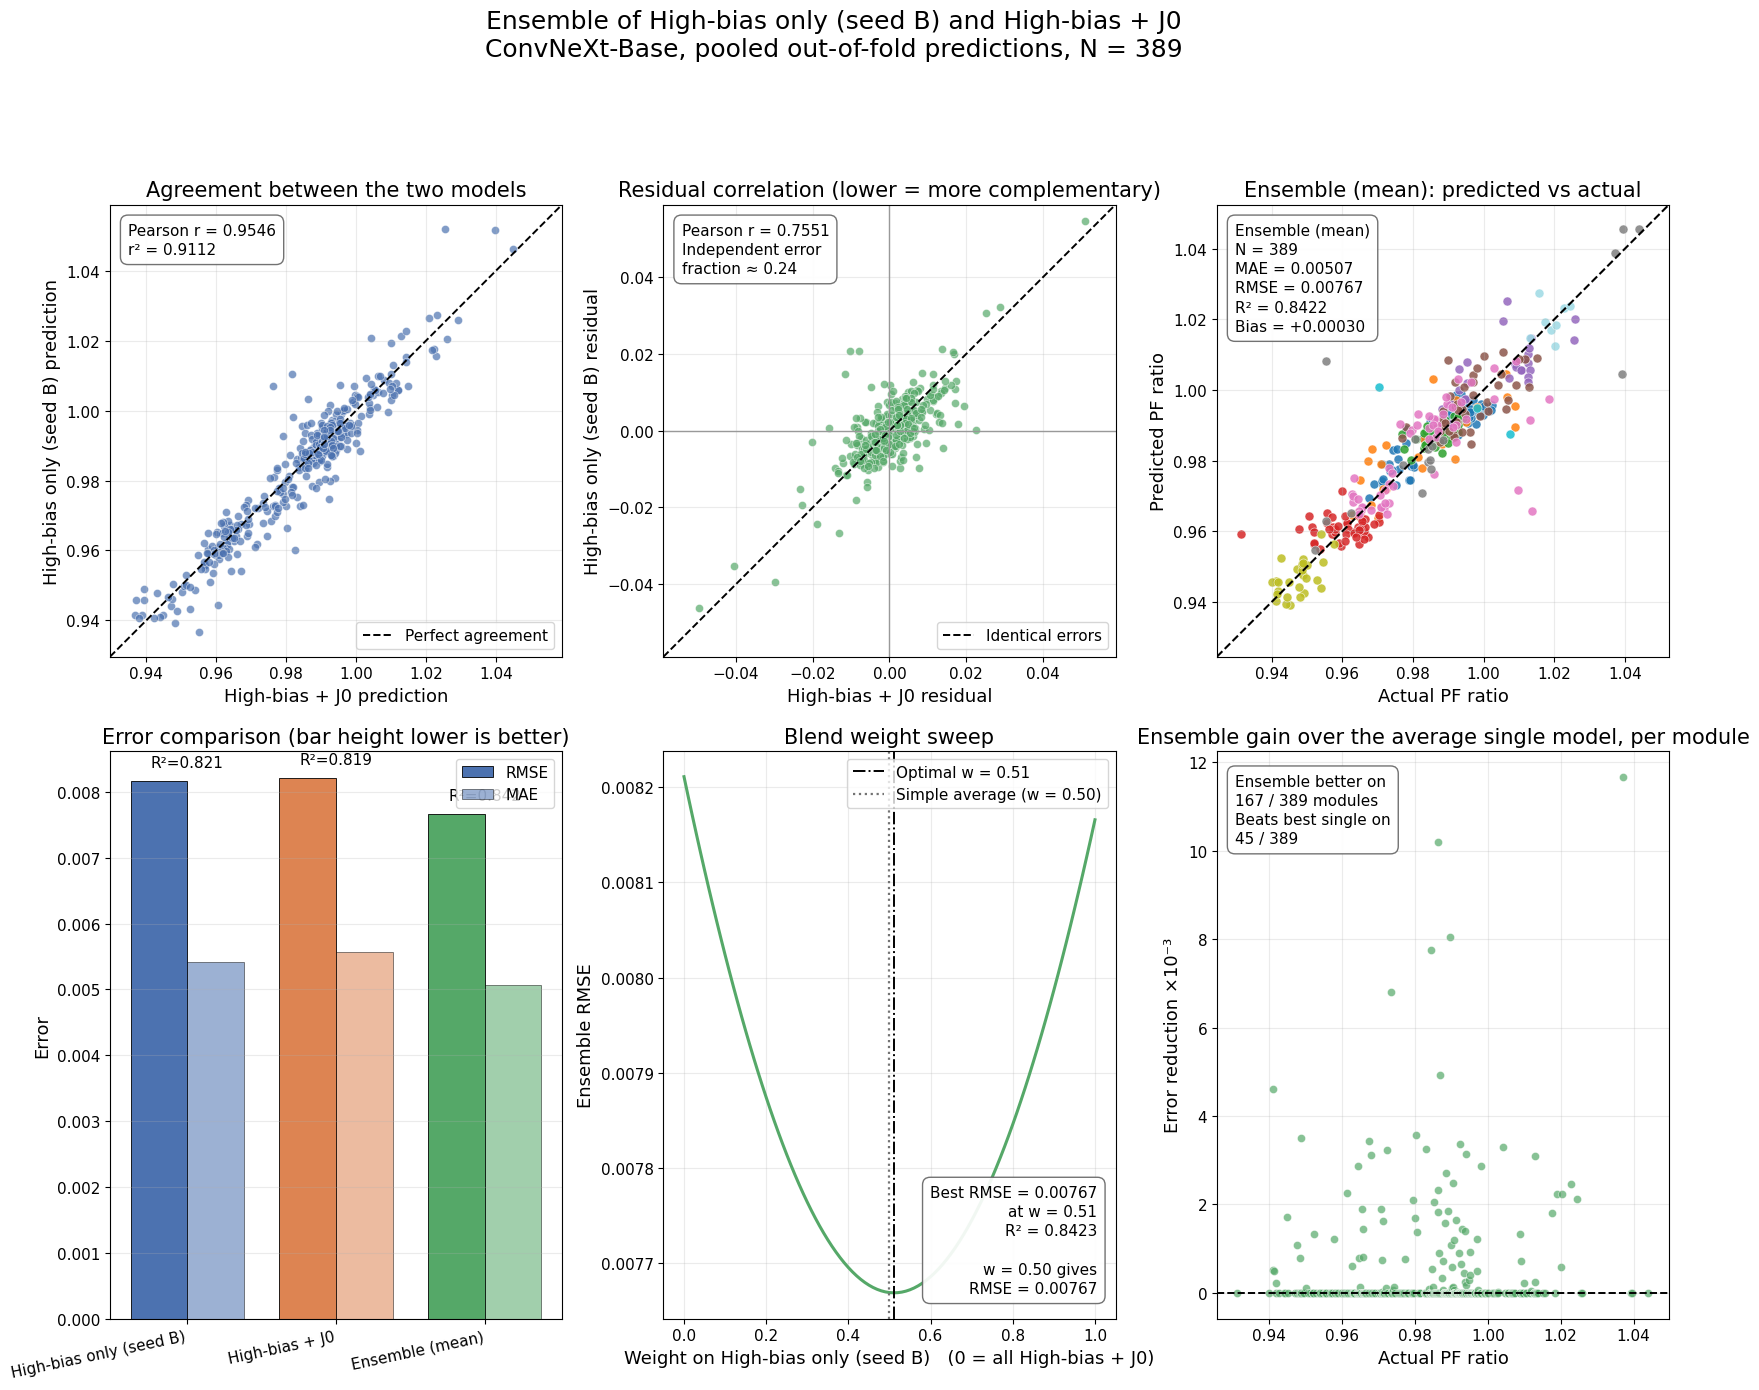


Saved:
- ensemble_convnext_highbias_only_vs_highbias_j0_figure.png
- ensemble_convnext_highbias_only_vs_highbias_j0_figure.pdf
- ensemble_convnext_highbias_only_vs_highbias_j0_predictions.csv
- ensemble_convnext_highbias_only_vs_highbias_j0_metrics.csv


In [3]:
"""
Ensemble analysis: high-bias + J0  vs  high-bias only

Reads the two out-of-fold prediction files, averages them, and produces a
multi-panel figure plus a metrics table.

IMPORTANT CAVEAT FOR THE WRITE-UP
---------------------------------
Averaging ANY two independently-trained models reduces prediction variance and
usually improves R2, whether or not their inputs differ. Part of the ensemble
gain here is therefore plain variance reduction, not physics.

To claim the J0 channel contributes complementary information, run the control:
train a second high-bias-only model with a different seed and average those two.
Then compare:

    gain from (high+J0) + (high only)      <- what this script measures
    gain from (high only A) + (high only B) <- the control

Only the excess of the first over the second is attributable to the J0 map.
Set CONTROL_CSV below once you have that second high-bias-only run and the
script will compute both.
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import mean_absolute_error, r2_score


# =========================================================
# CONFIG
# =========================================================
MODEL_A_CSV = "cv5_convnext_base_highbias_only_seedB_oof_test_predictions.csv"
MODEL_B_CSV = "cv5_convnext_base_highbias_j0_oof_test_predictions.csv"

MODEL_A_LABEL = "High-bias only (seed B)"
MODEL_B_LABEL = "High-bias + J0"
ENSEMBLE_LABEL = "Ensemble (mean)"

# Optional control: a second high-bias-only run with a different seed.
# Leave as None until you have it.
CONTROL_CSV = None
CONTROL_LABEL = "High-bias only (seed B)"

# Blend weight: predicted = W * A + (1 - W) * B. 0.5 = simple average.
ENSEMBLE_WEIGHT = 0.5

OUTPUT_PREFIX = "ensemble_convnext_highbias_only_vs_highbias_j0"

# ---- Font sizes: change these to control the figure text ----
FONT = {
    "title": 15,          # panel titles
    "suptitle": 18,       # figure title
    "axis_label": 13,     # x and y axis labels
    "tick": 11,           # tick numbers
    "legend": 11,
    "annotation": 11,     # metric boxes inside panels
}

# ---- Other appearance ----
FIGSIZE = (17, 14)
DPI = 300
POINT_SIZE = 34
POINT_ALPHA = 0.70
COLOR_A = "#4C72B0"
COLOR_B = "#DD8452"
COLOR_ENSEMBLE = "#55A868"


def apply_font_sizes():
    plt.rcParams.update({
        "axes.titlesize": FONT["title"],
        "axes.labelsize": FONT["axis_label"],
        "xtick.labelsize": FONT["tick"],
        "ytick.labelsize": FONT["tick"],
        "legend.fontsize": FONT["legend"],
        "figure.titlesize": FONT["suptitle"],
    })


# =========================================================
# LOAD AND ALIGN
# =========================================================
def load_predictions(path, label):
    if not os.path.exists(path):
        raise FileNotFoundError(f"{label}: file not found -> {path}")

    df = pd.read_csv(path)

    needed = {"sample_uid", "actual_pf_ratio", "predicted_pf_ratio"}
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"{label} is missing columns: {sorted(missing)}")

    if df["sample_uid"].duplicated().any():
        raise ValueError(f"{label} contains duplicate sample_uid values.")

    return df.set_index("sample_uid").sort_index()


def metrics(actual, predicted):
    residual = predicted - actual
    return {
        "N": len(actual),
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": float(np.sqrt(np.mean(residual ** 2))),
        "R2": r2_score(actual, predicted),
        "Bias": float(np.mean(residual)),
    }


def metrics_text(name, m):
    return (
        f"{name}\n"
        f"N = {m['N']}\n"
        f"MAE = {m['MAE']:.5f}\n"
        f"RMSE = {m['RMSE']:.5f}\n"
        f"R² = {m['R2']:.4f}\n"
        f"Bias = {m['Bias']:+.5f}"
    )


def annotate(ax, text, loc="upper left"):
    x, y, ha, va = (0.04, 0.96, "left", "top")
    if loc == "lower right":
        x, y, ha, va = (0.96, 0.04, "right", "bottom")

    ax.text(
        x, y, text, transform=ax.transAxes, ha=ha, va=va,
        fontsize=FONT["annotation"], linespacing=1.35,
        bbox=dict(boxstyle="round,pad=0.5", facecolor="white",
                  edgecolor="0.4", alpha=0.92),
        zorder=6,
    )


# =========================================================
# PANELS
# =========================================================
def panel_model_correlation(ax, pred_a, pred_b):
    """Do the two models agree? Tight cloud = redundant, spread = complementary."""
    lo = min(pred_a.min(), pred_b.min())
    hi = max(pred_a.max(), pred_b.max())
    pad = (hi - lo) * 0.06
    lo, hi = lo - pad, hi + pad

    ax.scatter(pred_b, pred_a, s=POINT_SIZE, alpha=POINT_ALPHA,
               color=COLOR_A, edgecolors="white", linewidths=0.4)
    ax.plot([lo, hi], [lo, hi], "--", color="black", linewidth=1.4,
            label="Perfect agreement")

    r = np.corrcoef(pred_a, pred_b)[0, 1]

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(f"{MODEL_B_LABEL} prediction")
    ax.set_ylabel(f"{MODEL_A_LABEL} prediction")
    ax.set_title("Agreement between the two models")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="lower right")

    annotate(ax, f"Pearson r = {r:.4f}\nr² = {r ** 2:.4f}")


def panel_residual_correlation(ax, res_a, res_b):
    """
    The key panel for the ensemble argument. Residual correlation well below 1
    means the two models fail on different modules, which is exactly what makes
    averaging help.
    """
    lim = max(np.abs(res_a).max(), np.abs(res_b).max()) * 1.08

    ax.scatter(res_b, res_a, s=POINT_SIZE, alpha=POINT_ALPHA,
               color=COLOR_ENSEMBLE, edgecolors="white", linewidths=0.4)
    ax.plot([-lim, lim], [-lim, lim], "--", color="black", linewidth=1.4,
            label="Identical errors")
    ax.axhline(0, color="0.6", linewidth=1.0)
    ax.axvline(0, color="0.6", linewidth=1.0)

    r = np.corrcoef(res_a, res_b)[0, 1]

    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(f"{MODEL_B_LABEL} residual")
    ax.set_ylabel(f"{MODEL_A_LABEL} residual")
    ax.set_title("Residual correlation (lower = more complementary)")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="lower right")

    annotate(
        ax,
        f"Pearson r = {r:.4f}\n"
        f"Independent error\nfraction ≈ {1 - r:.2f}",
    )


def panel_ensemble_scatter(ax, actual, pred_ens, make_values=None):
    lo = min(actual.min(), pred_ens.min())
    hi = max(actual.max(), pred_ens.max())
    pad = (hi - lo) * 0.06
    lo, hi = lo - pad, hi + pad

    if make_values is not None:
        makes = sorted(pd.Series(make_values).astype(str).unique())
        cmap = plt.colormaps.get_cmap("tab20")
        palette = {m: cmap(i / max(1, len(makes) - 1)) for i, m in enumerate(makes)}

        for m in makes:
            sel = np.asarray(make_values).astype(str) == m
            ax.scatter(actual[sel], pred_ens[sel], s=POINT_SIZE + 8,
                       color=palette[m], alpha=0.85, edgecolors="white",
                       linewidths=0.4, label=m)
    else:
        ax.scatter(actual, pred_ens, s=POINT_SIZE + 8, color=COLOR_ENSEMBLE,
                   alpha=0.85, edgecolors="white", linewidths=0.4)

    ax.plot([lo, hi], [lo, hi], "--", color="black", linewidth=1.5)

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Actual PF ratio")
    ax.set_ylabel("Predicted PF ratio")
    ax.set_title(f"{ENSEMBLE_LABEL}: predicted vs actual")
    ax.grid(True, alpha=0.25)

    annotate(ax, metrics_text(ENSEMBLE_LABEL, metrics(actual, pred_ens)))


def panel_metric_bars(ax, rows):
    """Side-by-side RMSE and MAE for every model."""
    names = [r["model"] for r in rows]
    x = np.arange(len(names))
    width = 0.38

    colors = [COLOR_A, COLOR_B, COLOR_ENSEMBLE, "0.55"][:len(names)]

    ax.bar(x - width / 2, [r["RMSE"] for r in rows], width,
           label="RMSE", color=colors, edgecolor="black", linewidth=0.6)
    ax.bar(x + width / 2, [r["MAE"] for r in rows], width,
           label="MAE", color=colors, alpha=0.55,
           edgecolor="black", linewidth=0.6)

    for i, r in enumerate(rows):
        ax.text(i, max(r["RMSE"], r["MAE"]) * 1.02, f"R²={r['R2']:.3f}",
                ha="center", va="bottom", fontsize=FONT["annotation"])

    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=12, ha="right")
    ax.set_ylabel("Error")
    ax.set_title("Error comparison (bar height lower is better)")
    ax.grid(True, alpha=0.25, axis="y")
    ax.legend()


def panel_weight_sweep(ax, actual, pred_a, pred_b):
    """
    How does performance vary with blend weight? A minimum near the middle is
    evidence both models carry useful and partly independent information.
    """
    weights = np.linspace(0, 1, 101)
    rmses, r2s = [], []

    for w in weights:
        p = w * pred_a + (1 - w) * pred_b
        rmses.append(np.sqrt(np.mean((p - actual) ** 2)))
        r2s.append(r2_score(actual, p))

    rmses = np.asarray(rmses)
    best = int(np.argmin(rmses))

    ax.plot(weights, rmses, linewidth=2.2, color=COLOR_ENSEMBLE)
    ax.axvline(weights[best], linestyle="-.", color="black", linewidth=1.4,
               label=f"Optimal w = {weights[best]:.2f}")
    ax.axvline(0.5, linestyle=":", color="0.45", linewidth=1.6,
               label="Simple average (w = 0.50)")

    ax.set_xlabel(f"Weight on {MODEL_A_LABEL}   (0 = all {MODEL_B_LABEL})")
    ax.set_ylabel("Ensemble RMSE")
    ax.set_title("Blend weight sweep")
    ax.grid(True, alpha=0.25)
    ax.legend()

    annotate(
        ax,
        f"Best RMSE = {rmses[best]:.5f}\n"
        f"at w = {weights[best]:.2f}\n"
        f"R² = {r2s[best]:.4f}\n\n"
        f"w = 0.50 gives\nRMSE = {rmses[50]:.5f}",
        loc="lower right",
    )

    return float(weights[best]), float(rmses[best])


def panel_per_module_gain(ax, actual, pred_a, pred_b, pred_ens):
    """
    Where does the ensemble actually help? Positive bars = ensemble beat the
    better of the two single models on that module.
    """
    ae_a = np.abs(pred_a - actual)
    ae_b = np.abs(pred_b - actual)
    ae_ens = np.abs(pred_ens - actual)

    best_single = np.minimum(ae_a, ae_b)
    gain_vs_mean_single = (ae_a + ae_b) / 2 - ae_ens

    order = np.argsort(actual)

    ax.scatter(actual[order], gain_vs_mean_single[order] * 1000,
               s=POINT_SIZE, alpha=POINT_ALPHA, color=COLOR_ENSEMBLE,
               edgecolors="white", linewidths=0.4)
    ax.axhline(0, linestyle="--", color="black", linewidth=1.4)

    ax.set_xlabel("Actual PF ratio")
    ax.set_ylabel("Error reduction ×10⁻³")
    ax.set_title("Ensemble gain over the average single model, per module")
    ax.grid(True, alpha=0.25)

    annotate(
        ax,
        f"Ensemble better on\n{int((gain_vs_mean_single > 0).sum())} / {len(actual)} modules\n"
        f"Beats best single on\n{int((ae_ens < best_single).sum())} / {len(actual)}",
    )


# =========================================================
# MAIN
# =========================================================
def main():
    apply_font_sizes()

    a = load_predictions(MODEL_A_CSV, MODEL_A_LABEL)
    b = load_predictions(MODEL_B_CSV, MODEL_B_LABEL)

    common = a.index.intersection(b.index)
    if len(common) == 0:
        raise ValueError("The two files share no sample_uid values.")

    if len(common) < len(a) or len(common) < len(b):
        print(
            f"WARNING: files do not cover the same modules. "
            f"A has {len(a)}, B has {len(b)}, using the {len(common)} in common."
        )

    a = a.loc[common]
    b = b.loc[common]

    actual = a["actual_pf_ratio"].to_numpy()
    actual_b = b["actual_pf_ratio"].to_numpy()

    if not np.allclose(actual, actual_b, atol=1e-9):
        raise ValueError(
            "Ground-truth PF ratios disagree between the two files. "
            "The runs are not on the same targets."
        )

    pred_a = a["predicted_pf_ratio"].to_numpy()
    pred_b = b["predicted_pf_ratio"].to_numpy()
    pred_ens = ENSEMBLE_WEIGHT * pred_a + (1 - ENSEMBLE_WEIGHT) * pred_b

    res_a = pred_a - actual
    res_b = pred_b - actual

    make_values = a["make_plot"].to_numpy() if "make_plot" in a.columns else None

    # ---- Metrics table ----
    rows = [
        {"model": MODEL_A_LABEL, **metrics(actual, pred_a)},
        {"model": MODEL_B_LABEL, **metrics(actual, pred_b)},
        {"model": ENSEMBLE_LABEL, **metrics(actual, pred_ens)},
    ]

    control_pred = None
    if CONTROL_CSV:
        c = load_predictions(CONTROL_CSV, CONTROL_LABEL).loc[common]
        control_pred = c["predicted_pf_ratio"].to_numpy()
        control_ens = 0.5 * pred_b + 0.5 * control_pred
        rows.append({"model": CONTROL_LABEL, **metrics(actual, control_pred)})
        rows.append({
            "model": "Control ensemble (high-only ×2)",
            **metrics(actual, control_ens),
        })

    table = pd.DataFrame(rows)

    print("\n" + "=" * 78)
    print("METRICS")
    print("=" * 78)
    print(table.to_string(index=False, float_format=lambda v: f"{v:.6f}"))

    # ---- Significance of the single-model difference ----
    w = stats.wilcoxon(np.abs(res_a), np.abs(res_b))
    t = stats.ttest_rel(np.abs(res_a), np.abs(res_b))

    print(f"\nPaired test, {MODEL_A_LABEL} vs {MODEL_B_LABEL} (absolute error):")
    print(f"  mean AE difference : {np.mean(np.abs(res_a) - np.abs(res_b)):+.6f}")
    print(f"  Wilcoxon p         : {w.pvalue:.4f}")
    print(f"  paired t-test p    : {t.pvalue:.4f}")
    print(f"  {MODEL_A_LABEL} better on "
          f"{int((np.abs(res_a) < np.abs(res_b)).sum())} / {len(actual)} modules")

    # ---- Significance of the ensemble gain ----
    ae_ens = np.abs(pred_ens - actual)
    ae_best_single = np.minimum(np.abs(res_a), np.abs(res_b))
    ae_mean_single = (np.abs(res_a) + np.abs(res_b)) / 2

    w_ens = stats.wilcoxon(ae_ens, ae_mean_single)
    print(f"\nEnsemble vs average single model (absolute error):")
    print(f"  mean AE difference : {np.mean(ae_ens - ae_mean_single):+.6f}")
    print(f"  Wilcoxon p         : {w_ens.pvalue:.6f}")
    print(f"  ensemble better on "
          f"{int((ae_ens < ae_mean_single).sum())} / {len(actual)} modules")
    print(f"  beats BEST single on "
          f"{int((ae_ens < ae_best_single).sum())} / {len(actual)} modules")

    print(f"\nPrediction correlation : {np.corrcoef(pred_a, pred_b)[0, 1]:.4f}")
    print(f"Residual correlation   : {np.corrcoef(res_a, res_b)[0, 1]:.4f}")

    if CONTROL_CSV is None:
        print(
            "\nNOTE: CONTROL_CSV is not set. Part of the ensemble gain is plain\n"
            "variance reduction from averaging two models, not the J0 channel.\n"
            "Train a second high-bias-only model with a different seed and set\n"
            "CONTROL_CSV to separate the two effects."
        )

    # ---- Figure ----
    fig, axes = plt.subplots(2, 3, figsize=FIGSIZE)

    panel_model_correlation(axes[0, 0], pred_a, pred_b)
    panel_residual_correlation(axes[0, 1], res_a, res_b)
    panel_ensemble_scatter(axes[0, 2], actual, pred_ens, make_values)
    panel_metric_bars(axes[1, 0], rows)
    best_w, best_rmse = panel_weight_sweep(axes[1, 1], actual, pred_a, pred_b)
    panel_per_module_gain(axes[1, 2], actual, pred_a, pred_b, pred_ens)

    fig.suptitle(
        f"Ensemble of {MODEL_A_LABEL} and {MODEL_B_LABEL}\n"
        f"ConvNeXt-Base, pooled out-of-fold predictions, N = {len(actual)}",
        y=0.99,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    fig.savefig(f"{OUTPUT_PREFIX}_figure.png", dpi=DPI, bbox_inches="tight")
    fig.savefig(f"{OUTPUT_PREFIX}_figure.pdf", bbox_inches="tight")
    plt.show()

    # ---- Save ----
    out = a[[c for c in ["ELHPath", "Make", "make_plot", "fold"] if c in a.columns]].copy()
    out["actual_pf_ratio"] = actual
    out[f"pred_{MODEL_A_LABEL}"] = pred_a
    out[f"pred_{MODEL_B_LABEL}"] = pred_b
    out["pred_ensemble"] = pred_ens
    out["residual_ensemble"] = pred_ens - actual
    out["absolute_error_ensemble"] = np.abs(pred_ens - actual)

    if control_pred is not None:
        out[f"pred_{CONTROL_LABEL}"] = control_pred

    out.to_csv(f"{OUTPUT_PREFIX}_predictions.csv")
    table.to_csv(f"{OUTPUT_PREFIX}_metrics.csv", index=False)

    print("\nSaved:")
    print(f"- {OUTPUT_PREFIX}_figure.png")
    print(f"- {OUTPUT_PREFIX}_figure.pdf")
    print(f"- {OUTPUT_PREFIX}_predictions.csv")
    print(f"- {OUTPUT_PREFIX}_metrics.csv")


if __name__ == "__main__":
    main()



METRICS
                  model   N      MAE     RMSE       R2     Bias
High-bias only (seed B) 389 0.005410 0.008166 0.821177 0.000121
High-bias only (seed C) 389 0.005683 0.008260 0.817018 0.000406
        Ensemble (mean) 389 0.005354 0.007990 0.828793 0.000264

Paired test, High-bias only (seed B) vs High-bias only (seed C) (absolute error):
  mean AE difference : -0.000273
  Wilcoxon p         : 0.0328
  paired t-test p    : 0.1031
  High-bias only (seed B) better on 214 / 389 modules

Ensemble vs average single model (absolute error):
  mean AE difference : -0.000192
  Wilcoxon p         : 0.000000
  ensemble better on 146 / 389 modules
  beats BEST single on 32 / 389 modules

Prediction correlation : 0.9809
Residual correlation   : 0.8933

NOTE: CONTROL_CSV is not set. Part of the ensemble gain is plain
variance reduction from averaging two models, not the J0 channel.
Train a second high-bias-only model with a different seed and set
CONTROL_CSV to separate the two effects.


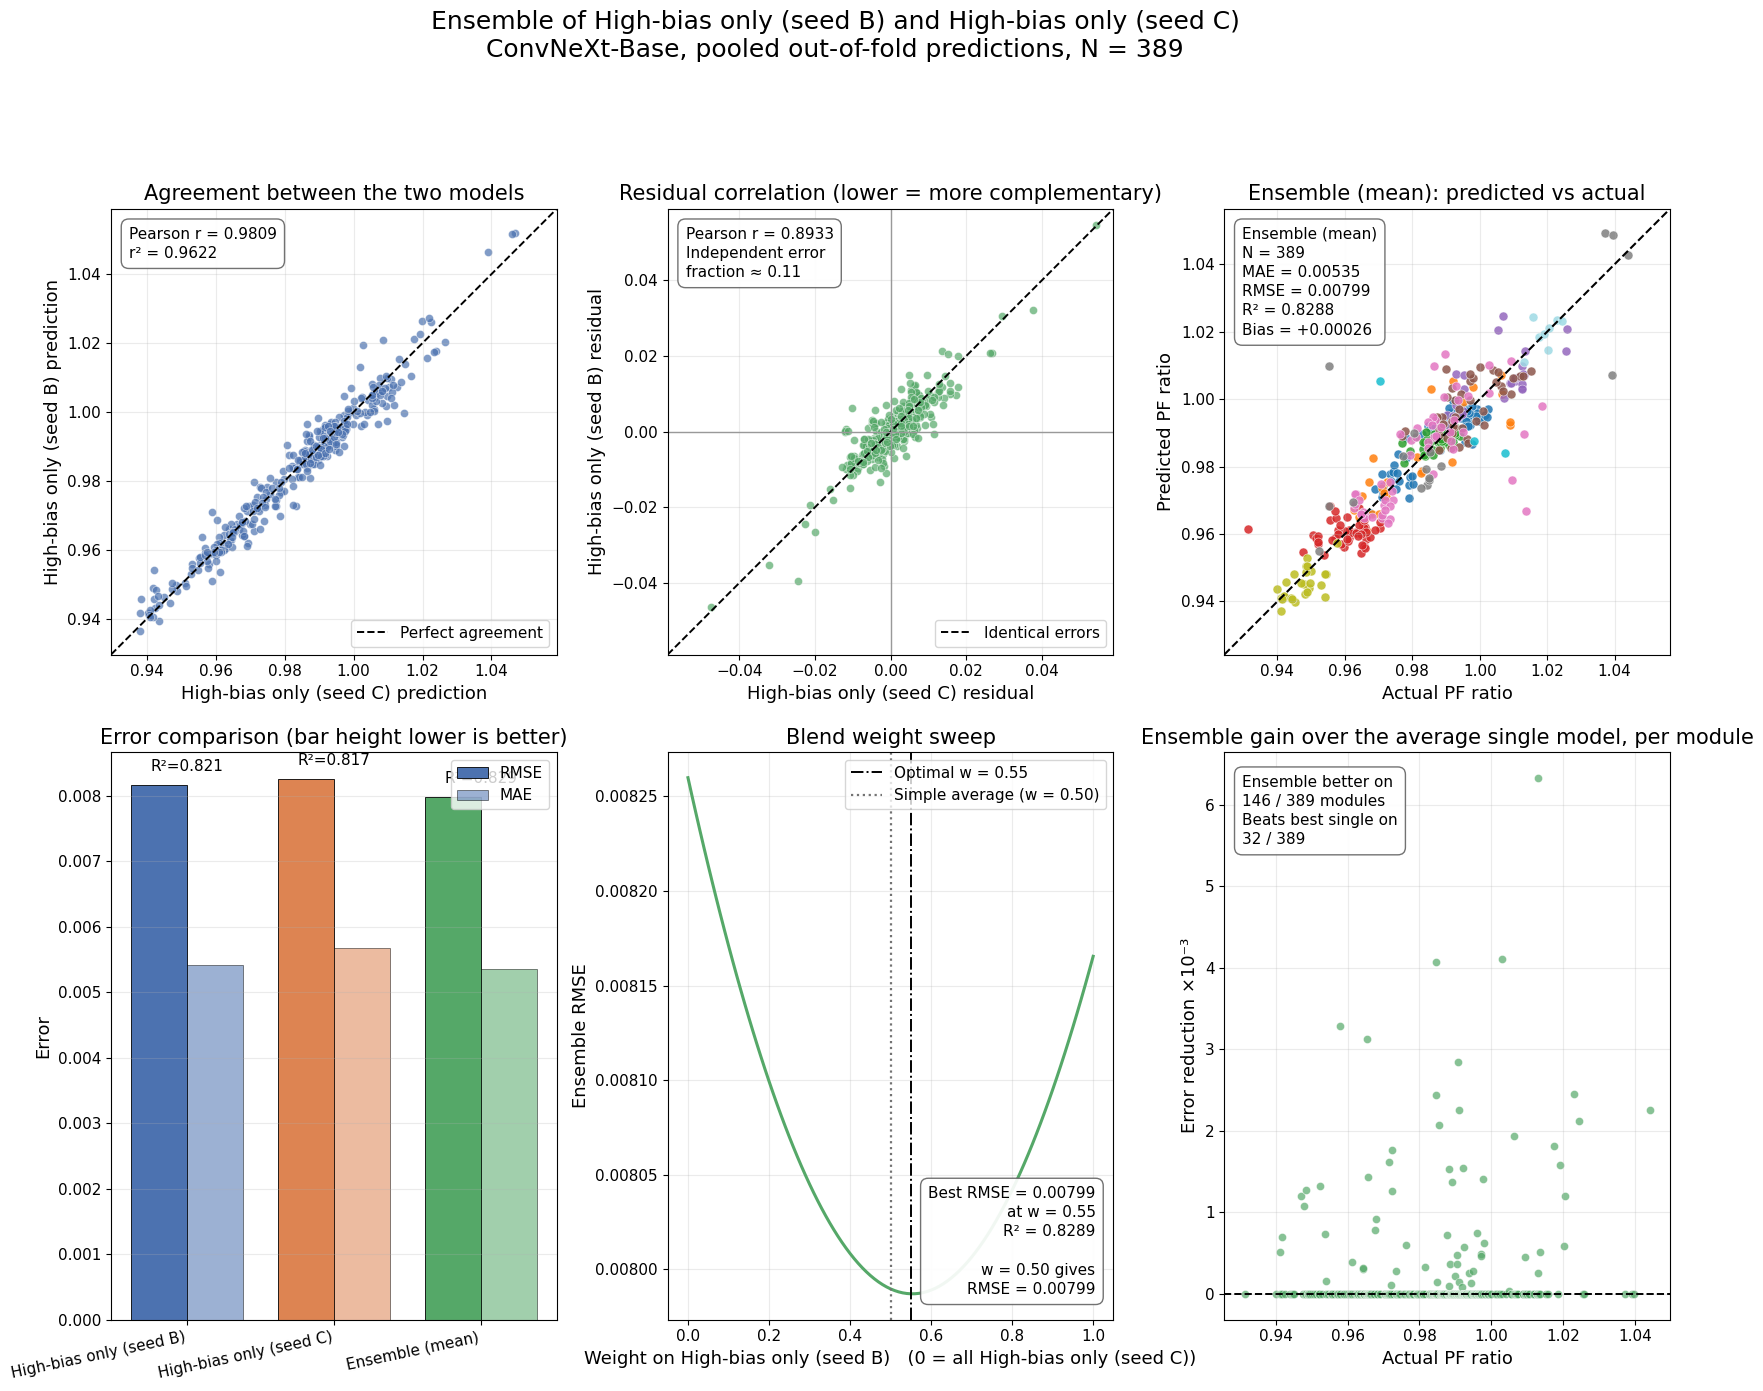


Saved:
- ensemble_convnext_highbias_only_seedB_vs_highbias_only_seedC_figure.png
- ensemble_convnext_highbias_only_seedB_vs_highbias_only_seedC_figure.pdf
- ensemble_convnext_highbias_only_seedB_vs_highbias_only_seedC_predictions.csv
- ensemble_convnext_highbias_only_seedB_vs_highbias_only_seedC_metrics.csv


In [4]:
"""
Ensemble analysis: high-bias + J0  vs  high-bias only

Reads the two out-of-fold prediction files, averages them, and produces a
multi-panel figure plus a metrics table.

IMPORTANT CAVEAT FOR THE WRITE-UP
---------------------------------
Averaging ANY two independently-trained models reduces prediction variance and
usually improves R2, whether or not their inputs differ. Part of the ensemble
gain here is therefore plain variance reduction, not physics.

To claim the J0 channel contributes complementary information, run the control:
train a second high-bias-only model with a different seed and average those two.
Then compare:

    gain from (high+J0) + (high only)      <- what this script measures
    gain from (high only A) + (high only B) <- the control

Only the excess of the first over the second is attributable to the J0 map.
Set CONTROL_CSV below once you have that second high-bias-only run and the
script will compute both.
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import mean_absolute_error, r2_score


# =========================================================
# CONFIG
# =========================================================
MODEL_A_CSV = "cv5_convnext_base_highbias_only_seedB_oof_test_predictions.csv"
MODEL_B_CSV = "cv5_convnext_base_highbias_only_seedC_oof_test_predictions.csv"

MODEL_A_LABEL = "High-bias only (seed B)"
MODEL_B_LABEL = "High-bias only (seed C)"
ENSEMBLE_LABEL = "Ensemble (mean)"

# Optional control: a second high-bias-only run with a different seed.
# Leave as None until you have it.
CONTROL_CSV = None
CONTROL_LABEL = "High-bias only (seed B)"

# Blend weight: predicted = W * A + (1 - W) * B. 0.5 = simple average.
ENSEMBLE_WEIGHT = 0.5

OUTPUT_PREFIX = "ensemble_convnext_highbias_only_seedB_vs_highbias_only_seedC"

# ---- Font sizes: change these to control the figure text ----
FONT = {
    "title": 15,          # panel titles
    "suptitle": 18,       # figure title
    "axis_label": 13,     # x and y axis labels
    "tick": 11,           # tick numbers
    "legend": 11,
    "annotation": 11,     # metric boxes inside panels
}

# ---- Other appearance ----
FIGSIZE = (17, 14)
DPI = 300
POINT_SIZE = 34
POINT_ALPHA = 0.70
COLOR_A = "#4C72B0"
COLOR_B = "#DD8452"
COLOR_ENSEMBLE = "#55A868"


def apply_font_sizes():
    plt.rcParams.update({
        "axes.titlesize": FONT["title"],
        "axes.labelsize": FONT["axis_label"],
        "xtick.labelsize": FONT["tick"],
        "ytick.labelsize": FONT["tick"],
        "legend.fontsize": FONT["legend"],
        "figure.titlesize": FONT["suptitle"],
    })


# =========================================================
# LOAD AND ALIGN
# =========================================================
def load_predictions(path, label):
    if not os.path.exists(path):
        raise FileNotFoundError(f"{label}: file not found -> {path}")

    df = pd.read_csv(path)

    needed = {"sample_uid", "actual_pf_ratio", "predicted_pf_ratio"}
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"{label} is missing columns: {sorted(missing)}")

    if df["sample_uid"].duplicated().any():
        raise ValueError(f"{label} contains duplicate sample_uid values.")

    return df.set_index("sample_uid").sort_index()


def metrics(actual, predicted):
    residual = predicted - actual
    return {
        "N": len(actual),
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": float(np.sqrt(np.mean(residual ** 2))),
        "R2": r2_score(actual, predicted),
        "Bias": float(np.mean(residual)),
    }


def metrics_text(name, m):
    return (
        f"{name}\n"
        f"N = {m['N']}\n"
        f"MAE = {m['MAE']:.5f}\n"
        f"RMSE = {m['RMSE']:.5f}\n"
        f"R² = {m['R2']:.4f}\n"
        f"Bias = {m['Bias']:+.5f}"
    )


def annotate(ax, text, loc="upper left"):
    x, y, ha, va = (0.04, 0.96, "left", "top")
    if loc == "lower right":
        x, y, ha, va = (0.96, 0.04, "right", "bottom")

    ax.text(
        x, y, text, transform=ax.transAxes, ha=ha, va=va,
        fontsize=FONT["annotation"], linespacing=1.35,
        bbox=dict(boxstyle="round,pad=0.5", facecolor="white",
                  edgecolor="0.4", alpha=0.92),
        zorder=6,
    )


# =========================================================
# PANELS
# =========================================================
def panel_model_correlation(ax, pred_a, pred_b):
    """Do the two models agree? Tight cloud = redundant, spread = complementary."""
    lo = min(pred_a.min(), pred_b.min())
    hi = max(pred_a.max(), pred_b.max())
    pad = (hi - lo) * 0.06
    lo, hi = lo - pad, hi + pad

    ax.scatter(pred_b, pred_a, s=POINT_SIZE, alpha=POINT_ALPHA,
               color=COLOR_A, edgecolors="white", linewidths=0.4)
    ax.plot([lo, hi], [lo, hi], "--", color="black", linewidth=1.4,
            label="Perfect agreement")

    r = np.corrcoef(pred_a, pred_b)[0, 1]

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(f"{MODEL_B_LABEL} prediction")
    ax.set_ylabel(f"{MODEL_A_LABEL} prediction")
    ax.set_title("Agreement between the two models")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="lower right")

    annotate(ax, f"Pearson r = {r:.4f}\nr² = {r ** 2:.4f}")


def panel_residual_correlation(ax, res_a, res_b):
    """
    The key panel for the ensemble argument. Residual correlation well below 1
    means the two models fail on different modules, which is exactly what makes
    averaging help.
    """
    lim = max(np.abs(res_a).max(), np.abs(res_b).max()) * 1.08

    ax.scatter(res_b, res_a, s=POINT_SIZE, alpha=POINT_ALPHA,
               color=COLOR_ENSEMBLE, edgecolors="white", linewidths=0.4)
    ax.plot([-lim, lim], [-lim, lim], "--", color="black", linewidth=1.4,
            label="Identical errors")
    ax.axhline(0, color="0.6", linewidth=1.0)
    ax.axvline(0, color="0.6", linewidth=1.0)

    r = np.corrcoef(res_a, res_b)[0, 1]

    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(f"{MODEL_B_LABEL} residual")
    ax.set_ylabel(f"{MODEL_A_LABEL} residual")
    ax.set_title("Residual correlation (lower = more complementary)")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="lower right")

    annotate(
        ax,
        f"Pearson r = {r:.4f}\n"
        f"Independent error\nfraction ≈ {1 - r:.2f}",
    )


def panel_ensemble_scatter(ax, actual, pred_ens, make_values=None):
    lo = min(actual.min(), pred_ens.min())
    hi = max(actual.max(), pred_ens.max())
    pad = (hi - lo) * 0.06
    lo, hi = lo - pad, hi + pad

    if make_values is not None:
        makes = sorted(pd.Series(make_values).astype(str).unique())
        cmap = plt.colormaps.get_cmap("tab20")
        palette = {m: cmap(i / max(1, len(makes) - 1)) for i, m in enumerate(makes)}

        for m in makes:
            sel = np.asarray(make_values).astype(str) == m
            ax.scatter(actual[sel], pred_ens[sel], s=POINT_SIZE + 8,
                       color=palette[m], alpha=0.85, edgecolors="white",
                       linewidths=0.4, label=m)
    else:
        ax.scatter(actual, pred_ens, s=POINT_SIZE + 8, color=COLOR_ENSEMBLE,
                   alpha=0.85, edgecolors="white", linewidths=0.4)

    ax.plot([lo, hi], [lo, hi], "--", color="black", linewidth=1.5)

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Actual PF ratio")
    ax.set_ylabel("Predicted PF ratio")
    ax.set_title(f"{ENSEMBLE_LABEL}: predicted vs actual")
    ax.grid(True, alpha=0.25)

    annotate(ax, metrics_text(ENSEMBLE_LABEL, metrics(actual, pred_ens)))


def panel_metric_bars(ax, rows):
    """Side-by-side RMSE and MAE for every model."""
    names = [r["model"] for r in rows]
    x = np.arange(len(names))
    width = 0.38

    colors = [COLOR_A, COLOR_B, COLOR_ENSEMBLE, "0.55"][:len(names)]

    ax.bar(x - width / 2, [r["RMSE"] for r in rows], width,
           label="RMSE", color=colors, edgecolor="black", linewidth=0.6)
    ax.bar(x + width / 2, [r["MAE"] for r in rows], width,
           label="MAE", color=colors, alpha=0.55,
           edgecolor="black", linewidth=0.6)

    for i, r in enumerate(rows):
        ax.text(i, max(r["RMSE"], r["MAE"]) * 1.02, f"R²={r['R2']:.3f}",
                ha="center", va="bottom", fontsize=FONT["annotation"])

    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=12, ha="right")
    ax.set_ylabel("Error")
    ax.set_title("Error comparison (bar height lower is better)")
    ax.grid(True, alpha=0.25, axis="y")
    ax.legend()


def panel_weight_sweep(ax, actual, pred_a, pred_b):
    """
    How does performance vary with blend weight? A minimum near the middle is
    evidence both models carry useful and partly independent information.
    """
    weights = np.linspace(0, 1, 101)
    rmses, r2s = [], []

    for w in weights:
        p = w * pred_a + (1 - w) * pred_b
        rmses.append(np.sqrt(np.mean((p - actual) ** 2)))
        r2s.append(r2_score(actual, p))

    rmses = np.asarray(rmses)
    best = int(np.argmin(rmses))

    ax.plot(weights, rmses, linewidth=2.2, color=COLOR_ENSEMBLE)
    ax.axvline(weights[best], linestyle="-.", color="black", linewidth=1.4,
               label=f"Optimal w = {weights[best]:.2f}")
    ax.axvline(0.5, linestyle=":", color="0.45", linewidth=1.6,
               label="Simple average (w = 0.50)")

    ax.set_xlabel(f"Weight on {MODEL_A_LABEL}   (0 = all {MODEL_B_LABEL})")
    ax.set_ylabel("Ensemble RMSE")
    ax.set_title("Blend weight sweep")
    ax.grid(True, alpha=0.25)
    ax.legend()

    annotate(
        ax,
        f"Best RMSE = {rmses[best]:.5f}\n"
        f"at w = {weights[best]:.2f}\n"
        f"R² = {r2s[best]:.4f}\n\n"
        f"w = 0.50 gives\nRMSE = {rmses[50]:.5f}",
        loc="lower right",
    )

    return float(weights[best]), float(rmses[best])


def panel_per_module_gain(ax, actual, pred_a, pred_b, pred_ens):
    """
    Where does the ensemble actually help? Positive bars = ensemble beat the
    better of the two single models on that module.
    """
    ae_a = np.abs(pred_a - actual)
    ae_b = np.abs(pred_b - actual)
    ae_ens = np.abs(pred_ens - actual)

    best_single = np.minimum(ae_a, ae_b)
    gain_vs_mean_single = (ae_a + ae_b) / 2 - ae_ens

    order = np.argsort(actual)

    ax.scatter(actual[order], gain_vs_mean_single[order] * 1000,
               s=POINT_SIZE, alpha=POINT_ALPHA, color=COLOR_ENSEMBLE,
               edgecolors="white", linewidths=0.4)
    ax.axhline(0, linestyle="--", color="black", linewidth=1.4)

    ax.set_xlabel("Actual PF ratio")
    ax.set_ylabel("Error reduction ×10⁻³")
    ax.set_title("Ensemble gain over the average single model, per module")
    ax.grid(True, alpha=0.25)

    annotate(
        ax,
        f"Ensemble better on\n{int((gain_vs_mean_single > 0).sum())} / {len(actual)} modules\n"
        f"Beats best single on\n{int((ae_ens < best_single).sum())} / {len(actual)}",
    )


# =========================================================
# MAIN
# =========================================================
def main():
    apply_font_sizes()

    a = load_predictions(MODEL_A_CSV, MODEL_A_LABEL)
    b = load_predictions(MODEL_B_CSV, MODEL_B_LABEL)

    common = a.index.intersection(b.index)
    if len(common) == 0:
        raise ValueError("The two files share no sample_uid values.")

    if len(common) < len(a) or len(common) < len(b):
        print(
            f"WARNING: files do not cover the same modules. "
            f"A has {len(a)}, B has {len(b)}, using the {len(common)} in common."
        )

    a = a.loc[common]
    b = b.loc[common]

    actual = a["actual_pf_ratio"].to_numpy()
    actual_b = b["actual_pf_ratio"].to_numpy()

    if not np.allclose(actual, actual_b, atol=1e-9):
        raise ValueError(
            "Ground-truth PF ratios disagree between the two files. "
            "The runs are not on the same targets."
        )

    pred_a = a["predicted_pf_ratio"].to_numpy()
    pred_b = b["predicted_pf_ratio"].to_numpy()
    pred_ens = ENSEMBLE_WEIGHT * pred_a + (1 - ENSEMBLE_WEIGHT) * pred_b

    res_a = pred_a - actual
    res_b = pred_b - actual

    make_values = a["make_plot"].to_numpy() if "make_plot" in a.columns else None

    # ---- Metrics table ----
    rows = [
        {"model": MODEL_A_LABEL, **metrics(actual, pred_a)},
        {"model": MODEL_B_LABEL, **metrics(actual, pred_b)},
        {"model": ENSEMBLE_LABEL, **metrics(actual, pred_ens)},
    ]

    control_pred = None
    if CONTROL_CSV:
        c = load_predictions(CONTROL_CSV, CONTROL_LABEL).loc[common]
        control_pred = c["predicted_pf_ratio"].to_numpy()
        control_ens = 0.5 * pred_b + 0.5 * control_pred
        rows.append({"model": CONTROL_LABEL, **metrics(actual, control_pred)})
        rows.append({
            "model": "Control ensemble (high-only ×2)",
            **metrics(actual, control_ens),
        })

    table = pd.DataFrame(rows)

    print("\n" + "=" * 78)
    print("METRICS")
    print("=" * 78)
    print(table.to_string(index=False, float_format=lambda v: f"{v:.6f}"))

    # ---- Significance of the single-model difference ----
    w = stats.wilcoxon(np.abs(res_a), np.abs(res_b))
    t = stats.ttest_rel(np.abs(res_a), np.abs(res_b))

    print(f"\nPaired test, {MODEL_A_LABEL} vs {MODEL_B_LABEL} (absolute error):")
    print(f"  mean AE difference : {np.mean(np.abs(res_a) - np.abs(res_b)):+.6f}")
    print(f"  Wilcoxon p         : {w.pvalue:.4f}")
    print(f"  paired t-test p    : {t.pvalue:.4f}")
    print(f"  {MODEL_A_LABEL} better on "
          f"{int((np.abs(res_a) < np.abs(res_b)).sum())} / {len(actual)} modules")

    # ---- Significance of the ensemble gain ----
    ae_ens = np.abs(pred_ens - actual)
    ae_best_single = np.minimum(np.abs(res_a), np.abs(res_b))
    ae_mean_single = (np.abs(res_a) + np.abs(res_b)) / 2

    w_ens = stats.wilcoxon(ae_ens, ae_mean_single)
    print(f"\nEnsemble vs average single model (absolute error):")
    print(f"  mean AE difference : {np.mean(ae_ens - ae_mean_single):+.6f}")
    print(f"  Wilcoxon p         : {w_ens.pvalue:.6f}")
    print(f"  ensemble better on "
          f"{int((ae_ens < ae_mean_single).sum())} / {len(actual)} modules")
    print(f"  beats BEST single on "
          f"{int((ae_ens < ae_best_single).sum())} / {len(actual)} modules")

    print(f"\nPrediction correlation : {np.corrcoef(pred_a, pred_b)[0, 1]:.4f}")
    print(f"Residual correlation   : {np.corrcoef(res_a, res_b)[0, 1]:.4f}")

    if CONTROL_CSV is None:
        print(
            "\nNOTE: CONTROL_CSV is not set. Part of the ensemble gain is plain\n"
            "variance reduction from averaging two models, not the J0 channel.\n"
            "Train a second high-bias-only model with a different seed and set\n"
            "CONTROL_CSV to separate the two effects."
        )

    # ---- Figure ----
    fig, axes = plt.subplots(2, 3, figsize=FIGSIZE)

    panel_model_correlation(axes[0, 0], pred_a, pred_b)
    panel_residual_correlation(axes[0, 1], res_a, res_b)
    panel_ensemble_scatter(axes[0, 2], actual, pred_ens, make_values)
    panel_metric_bars(axes[1, 0], rows)
    best_w, best_rmse = panel_weight_sweep(axes[1, 1], actual, pred_a, pred_b)
    panel_per_module_gain(axes[1, 2], actual, pred_a, pred_b, pred_ens)

    fig.suptitle(
        f"Ensemble of {MODEL_A_LABEL} and {MODEL_B_LABEL}\n"
        f"ConvNeXt-Base, pooled out-of-fold predictions, N = {len(actual)}",
        y=0.99,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    fig.savefig(f"{OUTPUT_PREFIX}_figure.png", dpi=DPI, bbox_inches="tight")
    fig.savefig(f"{OUTPUT_PREFIX}_figure.pdf", bbox_inches="tight")
    plt.show()

    # ---- Save ----
    out = a[[c for c in ["ELHPath", "Make", "make_plot", "fold"] if c in a.columns]].copy()
    out["actual_pf_ratio"] = actual
    out[f"pred_{MODEL_A_LABEL}"] = pred_a
    out[f"pred_{MODEL_B_LABEL}"] = pred_b
    out["pred_ensemble"] = pred_ens
    out["residual_ensemble"] = pred_ens - actual
    out["absolute_error_ensemble"] = np.abs(pred_ens - actual)

    if control_pred is not None:
        out[f"pred_{CONTROL_LABEL}"] = control_pred

    out.to_csv(f"{OUTPUT_PREFIX}_predictions.csv")
    table.to_csv(f"{OUTPUT_PREFIX}_metrics.csv", index=False)

    print("\nSaved:")
    print(f"- {OUTPUT_PREFIX}_figure.png")
    print(f"- {OUTPUT_PREFIX}_figure.pdf")
    print(f"- {OUTPUT_PREFIX}_predictions.csv")
    print(f"- {OUTPUT_PREFIX}_metrics.csv")


if __name__ == "__main__":
    main()



METRICS
                  model   N      MAE     RMSE       R2     Bias
High-bias only (seed A) 389 0.005412 0.008131 0.822700 0.000512
High-bias only (seed C) 389 0.005683 0.008260 0.817018 0.000406
        Ensemble (mean) 389 0.005302 0.007915 0.831975 0.000459

Paired test, High-bias only (seed A) vs High-bias only (seed C) (absolute error):
  mean AE difference : -0.000271
  Wilcoxon p         : 0.1991
  paired t-test p    : 0.1391
  High-bias only (seed A) better on 209 / 389 modules

Ensemble vs average single model (absolute error):
  mean AE difference : -0.000246
  Wilcoxon p         : 0.000000
  ensemble better on 157 / 389 modules
  beats BEST single on 35 / 389 modules

Prediction correlation : 0.9763
Residual correlation   : 0.8653

NOTE: CONTROL_CSV is not set. Part of the ensemble gain is plain
variance reduction from averaging two models, not the J0 channel.
Train a second high-bias-only model with a different seed and set
CONTROL_CSV to separate the two effects.


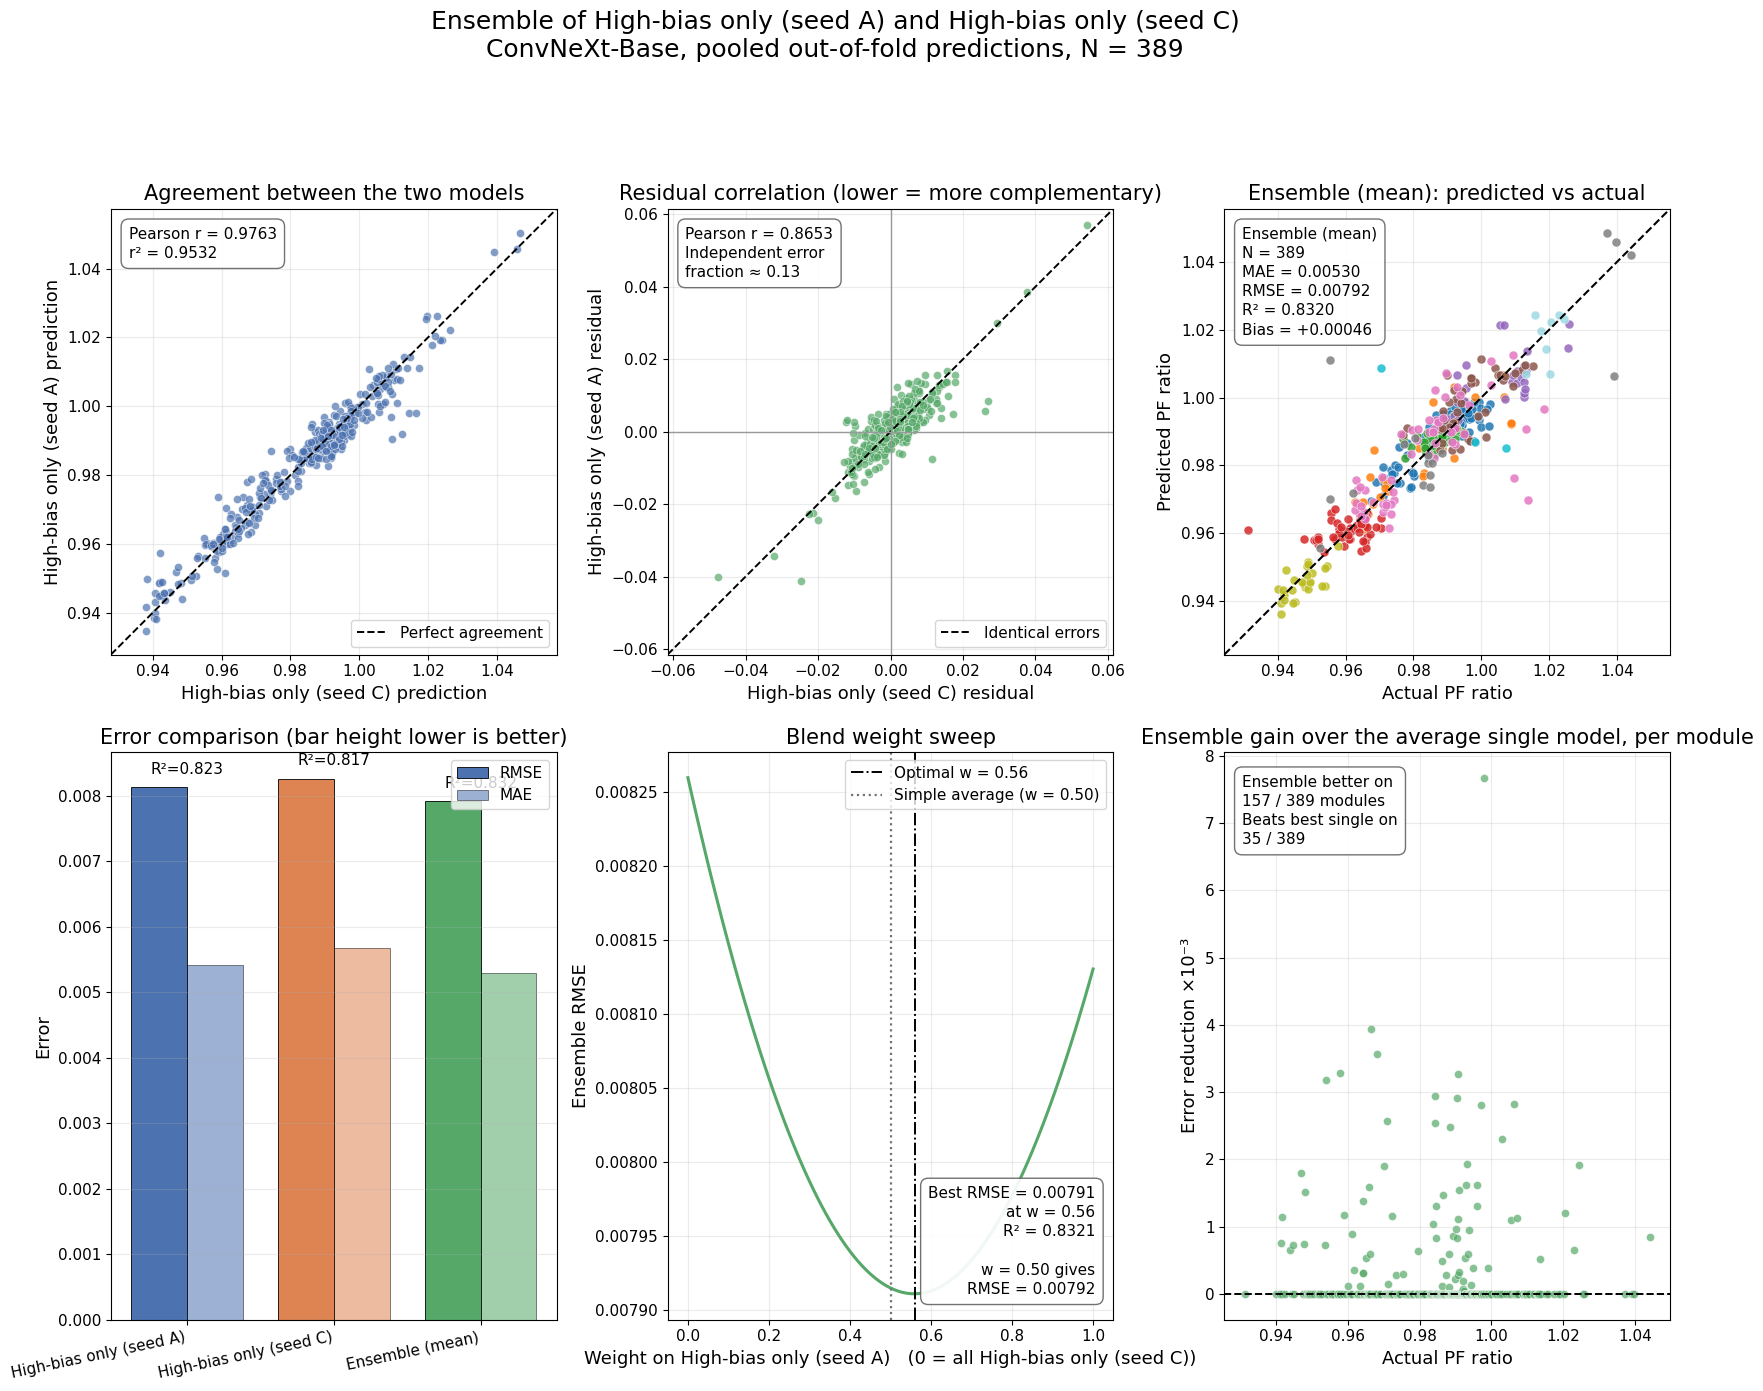


Saved:
- ensemble_convnext_highbias_only_seedA_vs_highbias_only_seedC_figure.png
- ensemble_convnext_highbias_only_seedA_vs_highbias_only_seedC_figure.pdf
- ensemble_convnext_highbias_only_seedA_vs_highbias_only_seedC_predictions.csv
- ensemble_convnext_highbias_only_seedA_vs_highbias_only_seedC_metrics.csv


In [5]:
"""
Ensemble analysis: high-bias + J0  vs  high-bias only

Reads the two out-of-fold prediction files, averages them, and produces a
multi-panel figure plus a metrics table.

IMPORTANT CAVEAT FOR THE WRITE-UP
---------------------------------
Averaging ANY two independently-trained models reduces prediction variance and
usually improves R2, whether or not their inputs differ. Part of the ensemble
gain here is therefore plain variance reduction, not physics.

To claim the J0 channel contributes complementary information, run the control:
train a second high-bias-only model with a different seed and average those two.
Then compare:

    gain from (high+J0) + (high only)      <- what this script measures
    gain from (high only A) + (high only B) <- the control

Only the excess of the first over the second is attributable to the J0 map.
Set CONTROL_CSV below once you have that second high-bias-only run and the
script will compute both.
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import mean_absolute_error, r2_score


# =========================================================
# CONFIG
# =========================================================
MODEL_A_CSV = "cv5_convnext_base_highbias_only_oof_test_predictions.csv"
MODEL_B_CSV = "cv5_convnext_base_highbias_only_seedC_oof_test_predictions.csv"

MODEL_A_LABEL = "High-bias only (seed A)"
MODEL_B_LABEL = "High-bias only (seed C)"
ENSEMBLE_LABEL = "Ensemble (mean)"

# Optional control: a second high-bias-only run with a different seed.
# Leave as None until you have it.
CONTROL_CSV = None
CONTROL_LABEL = "High-bias only (seed B)"

# Blend weight: predicted = W * A + (1 - W) * B. 0.5 = simple average.
ENSEMBLE_WEIGHT = 0.5

OUTPUT_PREFIX = "ensemble_convnext_highbias_only_seedA_vs_highbias_only_seedC"

# ---- Font sizes: change these to control the figure text ----
FONT = {
    "title": 15,          # panel titles
    "suptitle": 18,       # figure title
    "axis_label": 13,     # x and y axis labels
    "tick": 11,           # tick numbers
    "legend": 11,
    "annotation": 11,     # metric boxes inside panels
}

# ---- Other appearance ----
FIGSIZE = (17, 14)
DPI = 300
POINT_SIZE = 34
POINT_ALPHA = 0.70
COLOR_A = "#4C72B0"
COLOR_B = "#DD8452"
COLOR_ENSEMBLE = "#55A868"


def apply_font_sizes():
    plt.rcParams.update({
        "axes.titlesize": FONT["title"],
        "axes.labelsize": FONT["axis_label"],
        "xtick.labelsize": FONT["tick"],
        "ytick.labelsize": FONT["tick"],
        "legend.fontsize": FONT["legend"],
        "figure.titlesize": FONT["suptitle"],
    })


# =========================================================
# LOAD AND ALIGN
# =========================================================
def load_predictions(path, label):
    if not os.path.exists(path):
        raise FileNotFoundError(f"{label}: file not found -> {path}")

    df = pd.read_csv(path)

    needed = {"sample_uid", "actual_pf_ratio", "predicted_pf_ratio"}
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"{label} is missing columns: {sorted(missing)}")

    if df["sample_uid"].duplicated().any():
        raise ValueError(f"{label} contains duplicate sample_uid values.")

    return df.set_index("sample_uid").sort_index()


def metrics(actual, predicted):
    residual = predicted - actual
    return {
        "N": len(actual),
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": float(np.sqrt(np.mean(residual ** 2))),
        "R2": r2_score(actual, predicted),
        "Bias": float(np.mean(residual)),
    }


def metrics_text(name, m):
    return (
        f"{name}\n"
        f"N = {m['N']}\n"
        f"MAE = {m['MAE']:.5f}\n"
        f"RMSE = {m['RMSE']:.5f}\n"
        f"R² = {m['R2']:.4f}\n"
        f"Bias = {m['Bias']:+.5f}"
    )


def annotate(ax, text, loc="upper left"):
    x, y, ha, va = (0.04, 0.96, "left", "top")
    if loc == "lower right":
        x, y, ha, va = (0.96, 0.04, "right", "bottom")

    ax.text(
        x, y, text, transform=ax.transAxes, ha=ha, va=va,
        fontsize=FONT["annotation"], linespacing=1.35,
        bbox=dict(boxstyle="round,pad=0.5", facecolor="white",
                  edgecolor="0.4", alpha=0.92),
        zorder=6,
    )


# =========================================================
# PANELS
# =========================================================
def panel_model_correlation(ax, pred_a, pred_b):
    """Do the two models agree? Tight cloud = redundant, spread = complementary."""
    lo = min(pred_a.min(), pred_b.min())
    hi = max(pred_a.max(), pred_b.max())
    pad = (hi - lo) * 0.06
    lo, hi = lo - pad, hi + pad

    ax.scatter(pred_b, pred_a, s=POINT_SIZE, alpha=POINT_ALPHA,
               color=COLOR_A, edgecolors="white", linewidths=0.4)
    ax.plot([lo, hi], [lo, hi], "--", color="black", linewidth=1.4,
            label="Perfect agreement")

    r = np.corrcoef(pred_a, pred_b)[0, 1]

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(f"{MODEL_B_LABEL} prediction")
    ax.set_ylabel(f"{MODEL_A_LABEL} prediction")
    ax.set_title("Agreement between the two models")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="lower right")

    annotate(ax, f"Pearson r = {r:.4f}\nr² = {r ** 2:.4f}")


def panel_residual_correlation(ax, res_a, res_b):
    """
    The key panel for the ensemble argument. Residual correlation well below 1
    means the two models fail on different modules, which is exactly what makes
    averaging help.
    """
    lim = max(np.abs(res_a).max(), np.abs(res_b).max()) * 1.08

    ax.scatter(res_b, res_a, s=POINT_SIZE, alpha=POINT_ALPHA,
               color=COLOR_ENSEMBLE, edgecolors="white", linewidths=0.4)
    ax.plot([-lim, lim], [-lim, lim], "--", color="black", linewidth=1.4,
            label="Identical errors")
    ax.axhline(0, color="0.6", linewidth=1.0)
    ax.axvline(0, color="0.6", linewidth=1.0)

    r = np.corrcoef(res_a, res_b)[0, 1]

    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(f"{MODEL_B_LABEL} residual")
    ax.set_ylabel(f"{MODEL_A_LABEL} residual")
    ax.set_title("Residual correlation (lower = more complementary)")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="lower right")

    annotate(
        ax,
        f"Pearson r = {r:.4f}\n"
        f"Independent error\nfraction ≈ {1 - r:.2f}",
    )


def panel_ensemble_scatter(ax, actual, pred_ens, make_values=None):
    lo = min(actual.min(), pred_ens.min())
    hi = max(actual.max(), pred_ens.max())
    pad = (hi - lo) * 0.06
    lo, hi = lo - pad, hi + pad

    if make_values is not None:
        makes = sorted(pd.Series(make_values).astype(str).unique())
        cmap = plt.colormaps.get_cmap("tab20")
        palette = {m: cmap(i / max(1, len(makes) - 1)) for i, m in enumerate(makes)}

        for m in makes:
            sel = np.asarray(make_values).astype(str) == m
            ax.scatter(actual[sel], pred_ens[sel], s=POINT_SIZE + 8,
                       color=palette[m], alpha=0.85, edgecolors="white",
                       linewidths=0.4, label=m)
    else:
        ax.scatter(actual, pred_ens, s=POINT_SIZE + 8, color=COLOR_ENSEMBLE,
                   alpha=0.85, edgecolors="white", linewidths=0.4)

    ax.plot([lo, hi], [lo, hi], "--", color="black", linewidth=1.5)

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Actual PF ratio")
    ax.set_ylabel("Predicted PF ratio")
    ax.set_title(f"{ENSEMBLE_LABEL}: predicted vs actual")
    ax.grid(True, alpha=0.25)

    annotate(ax, metrics_text(ENSEMBLE_LABEL, metrics(actual, pred_ens)))


def panel_metric_bars(ax, rows):
    """Side-by-side RMSE and MAE for every model."""
    names = [r["model"] for r in rows]
    x = np.arange(len(names))
    width = 0.38

    colors = [COLOR_A, COLOR_B, COLOR_ENSEMBLE, "0.55"][:len(names)]

    ax.bar(x - width / 2, [r["RMSE"] for r in rows], width,
           label="RMSE", color=colors, edgecolor="black", linewidth=0.6)
    ax.bar(x + width / 2, [r["MAE"] for r in rows], width,
           label="MAE", color=colors, alpha=0.55,
           edgecolor="black", linewidth=0.6)

    for i, r in enumerate(rows):
        ax.text(i, max(r["RMSE"], r["MAE"]) * 1.02, f"R²={r['R2']:.3f}",
                ha="center", va="bottom", fontsize=FONT["annotation"])

    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=12, ha="right")
    ax.set_ylabel("Error")
    ax.set_title("Error comparison (bar height lower is better)")
    ax.grid(True, alpha=0.25, axis="y")
    ax.legend()


def panel_weight_sweep(ax, actual, pred_a, pred_b):
    """
    How does performance vary with blend weight? A minimum near the middle is
    evidence both models carry useful and partly independent information.
    """
    weights = np.linspace(0, 1, 101)
    rmses, r2s = [], []

    for w in weights:
        p = w * pred_a + (1 - w) * pred_b
        rmses.append(np.sqrt(np.mean((p - actual) ** 2)))
        r2s.append(r2_score(actual, p))

    rmses = np.asarray(rmses)
    best = int(np.argmin(rmses))

    ax.plot(weights, rmses, linewidth=2.2, color=COLOR_ENSEMBLE)
    ax.axvline(weights[best], linestyle="-.", color="black", linewidth=1.4,
               label=f"Optimal w = {weights[best]:.2f}")
    ax.axvline(0.5, linestyle=":", color="0.45", linewidth=1.6,
               label="Simple average (w = 0.50)")

    ax.set_xlabel(f"Weight on {MODEL_A_LABEL}   (0 = all {MODEL_B_LABEL})")
    ax.set_ylabel("Ensemble RMSE")
    ax.set_title("Blend weight sweep")
    ax.grid(True, alpha=0.25)
    ax.legend()

    annotate(
        ax,
        f"Best RMSE = {rmses[best]:.5f}\n"
        f"at w = {weights[best]:.2f}\n"
        f"R² = {r2s[best]:.4f}\n\n"
        f"w = 0.50 gives\nRMSE = {rmses[50]:.5f}",
        loc="lower right",
    )

    return float(weights[best]), float(rmses[best])


def panel_per_module_gain(ax, actual, pred_a, pred_b, pred_ens):
    """
    Where does the ensemble actually help? Positive bars = ensemble beat the
    better of the two single models on that module.
    """
    ae_a = np.abs(pred_a - actual)
    ae_b = np.abs(pred_b - actual)
    ae_ens = np.abs(pred_ens - actual)

    best_single = np.minimum(ae_a, ae_b)
    gain_vs_mean_single = (ae_a + ae_b) / 2 - ae_ens

    order = np.argsort(actual)

    ax.scatter(actual[order], gain_vs_mean_single[order] * 1000,
               s=POINT_SIZE, alpha=POINT_ALPHA, color=COLOR_ENSEMBLE,
               edgecolors="white", linewidths=0.4)
    ax.axhline(0, linestyle="--", color="black", linewidth=1.4)

    ax.set_xlabel("Actual PF ratio")
    ax.set_ylabel("Error reduction ×10⁻³")
    ax.set_title("Ensemble gain over the average single model, per module")
    ax.grid(True, alpha=0.25)

    annotate(
        ax,
        f"Ensemble better on\n{int((gain_vs_mean_single > 0).sum())} / {len(actual)} modules\n"
        f"Beats best single on\n{int((ae_ens < best_single).sum())} / {len(actual)}",
    )


# =========================================================
# MAIN
# =========================================================
def main():
    apply_font_sizes()

    a = load_predictions(MODEL_A_CSV, MODEL_A_LABEL)
    b = load_predictions(MODEL_B_CSV, MODEL_B_LABEL)

    common = a.index.intersection(b.index)
    if len(common) == 0:
        raise ValueError("The two files share no sample_uid values.")

    if len(common) < len(a) or len(common) < len(b):
        print(
            f"WARNING: files do not cover the same modules. "
            f"A has {len(a)}, B has {len(b)}, using the {len(common)} in common."
        )

    a = a.loc[common]
    b = b.loc[common]

    actual = a["actual_pf_ratio"].to_numpy()
    actual_b = b["actual_pf_ratio"].to_numpy()

    if not np.allclose(actual, actual_b, atol=1e-9):
        raise ValueError(
            "Ground-truth PF ratios disagree between the two files. "
            "The runs are not on the same targets."
        )

    pred_a = a["predicted_pf_ratio"].to_numpy()
    pred_b = b["predicted_pf_ratio"].to_numpy()
    pred_ens = ENSEMBLE_WEIGHT * pred_a + (1 - ENSEMBLE_WEIGHT) * pred_b

    res_a = pred_a - actual
    res_b = pred_b - actual

    make_values = a["make_plot"].to_numpy() if "make_plot" in a.columns else None

    # ---- Metrics table ----
    rows = [
        {"model": MODEL_A_LABEL, **metrics(actual, pred_a)},
        {"model": MODEL_B_LABEL, **metrics(actual, pred_b)},
        {"model": ENSEMBLE_LABEL, **metrics(actual, pred_ens)},
    ]

    control_pred = None
    if CONTROL_CSV:
        c = load_predictions(CONTROL_CSV, CONTROL_LABEL).loc[common]
        control_pred = c["predicted_pf_ratio"].to_numpy()
        control_ens = 0.5 * pred_b + 0.5 * control_pred
        rows.append({"model": CONTROL_LABEL, **metrics(actual, control_pred)})
        rows.append({
            "model": "Control ensemble (high-only ×2)",
            **metrics(actual, control_ens),
        })

    table = pd.DataFrame(rows)

    print("\n" + "=" * 78)
    print("METRICS")
    print("=" * 78)
    print(table.to_string(index=False, float_format=lambda v: f"{v:.6f}"))

    # ---- Significance of the single-model difference ----
    w = stats.wilcoxon(np.abs(res_a), np.abs(res_b))
    t = stats.ttest_rel(np.abs(res_a), np.abs(res_b))

    print(f"\nPaired test, {MODEL_A_LABEL} vs {MODEL_B_LABEL} (absolute error):")
    print(f"  mean AE difference : {np.mean(np.abs(res_a) - np.abs(res_b)):+.6f}")
    print(f"  Wilcoxon p         : {w.pvalue:.4f}")
    print(f"  paired t-test p    : {t.pvalue:.4f}")
    print(f"  {MODEL_A_LABEL} better on "
          f"{int((np.abs(res_a) < np.abs(res_b)).sum())} / {len(actual)} modules")

    # ---- Significance of the ensemble gain ----
    ae_ens = np.abs(pred_ens - actual)
    ae_best_single = np.minimum(np.abs(res_a), np.abs(res_b))
    ae_mean_single = (np.abs(res_a) + np.abs(res_b)) / 2

    w_ens = stats.wilcoxon(ae_ens, ae_mean_single)
    print(f"\nEnsemble vs average single model (absolute error):")
    print(f"  mean AE difference : {np.mean(ae_ens - ae_mean_single):+.6f}")
    print(f"  Wilcoxon p         : {w_ens.pvalue:.6f}")
    print(f"  ensemble better on "
          f"{int((ae_ens < ae_mean_single).sum())} / {len(actual)} modules")
    print(f"  beats BEST single on "
          f"{int((ae_ens < ae_best_single).sum())} / {len(actual)} modules")

    print(f"\nPrediction correlation : {np.corrcoef(pred_a, pred_b)[0, 1]:.4f}")
    print(f"Residual correlation   : {np.corrcoef(res_a, res_b)[0, 1]:.4f}")

    if CONTROL_CSV is None:
        print(
            "\nNOTE: CONTROL_CSV is not set. Part of the ensemble gain is plain\n"
            "variance reduction from averaging two models, not the J0 channel.\n"
            "Train a second high-bias-only model with a different seed and set\n"
            "CONTROL_CSV to separate the two effects."
        )

    # ---- Figure ----
    fig, axes = plt.subplots(2, 3, figsize=FIGSIZE)

    panel_model_correlation(axes[0, 0], pred_a, pred_b)
    panel_residual_correlation(axes[0, 1], res_a, res_b)
    panel_ensemble_scatter(axes[0, 2], actual, pred_ens, make_values)
    panel_metric_bars(axes[1, 0], rows)
    best_w, best_rmse = panel_weight_sweep(axes[1, 1], actual, pred_a, pred_b)
    panel_per_module_gain(axes[1, 2], actual, pred_a, pred_b, pred_ens)

    fig.suptitle(
        f"Ensemble of {MODEL_A_LABEL} and {MODEL_B_LABEL}\n"
        f"ConvNeXt-Base, pooled out-of-fold predictions, N = {len(actual)}",
        y=0.99,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    fig.savefig(f"{OUTPUT_PREFIX}_figure.png", dpi=DPI, bbox_inches="tight")
    fig.savefig(f"{OUTPUT_PREFIX}_figure.pdf", bbox_inches="tight")
    plt.show()

    # ---- Save ----
    out = a[[c for c in ["ELHPath", "Make", "make_plot", "fold"] if c in a.columns]].copy()
    out["actual_pf_ratio"] = actual
    out[f"pred_{MODEL_A_LABEL}"] = pred_a
    out[f"pred_{MODEL_B_LABEL}"] = pred_b
    out["pred_ensemble"] = pred_ens
    out["residual_ensemble"] = pred_ens - actual
    out["absolute_error_ensemble"] = np.abs(pred_ens - actual)

    if control_pred is not None:
        out[f"pred_{CONTROL_LABEL}"] = control_pred

    out.to_csv(f"{OUTPUT_PREFIX}_predictions.csv")
    table.to_csv(f"{OUTPUT_PREFIX}_metrics.csv", index=False)

    print("\nSaved:")
    print(f"- {OUTPUT_PREFIX}_figure.png")
    print(f"- {OUTPUT_PREFIX}_figure.pdf")
    print(f"- {OUTPUT_PREFIX}_predictions.csv")
    print(f"- {OUTPUT_PREFIX}_metrics.csv")


if __name__ == "__main__":
    main()



METRICS
                  model   N      MAE     RMSE       R2     Bias
         High-bias + J0 389 0.005572 0.008211 0.819191 0.000473
High-bias only (seed C) 389 0.005683 0.008260 0.817018 0.000406
        Ensemble (mean) 389 0.005142 0.007656 0.842815 0.000440

Paired test, High-bias + J0 vs High-bias only (seed C) (absolute error):
  mean AE difference : -0.000111
  Wilcoxon p         : 0.4387
  paired t-test p    : 0.6243
  High-bias + J0 better on 197 / 389 modules

Ensemble vs average single model (absolute error):
  mean AE difference : -0.000485
  Wilcoxon p         : 0.000000
  ensemble better on 179 / 389 modules
  beats BEST single on 56 / 389 modules

Prediction correlation : 0.9503
Residual correlation   : 0.7276

NOTE: CONTROL_CSV is not set. Part of the ensemble gain is plain
variance reduction from averaging two models, not the J0 channel.
Train a second high-bias-only model with a different seed and set
CONTROL_CSV to separate the two effects.


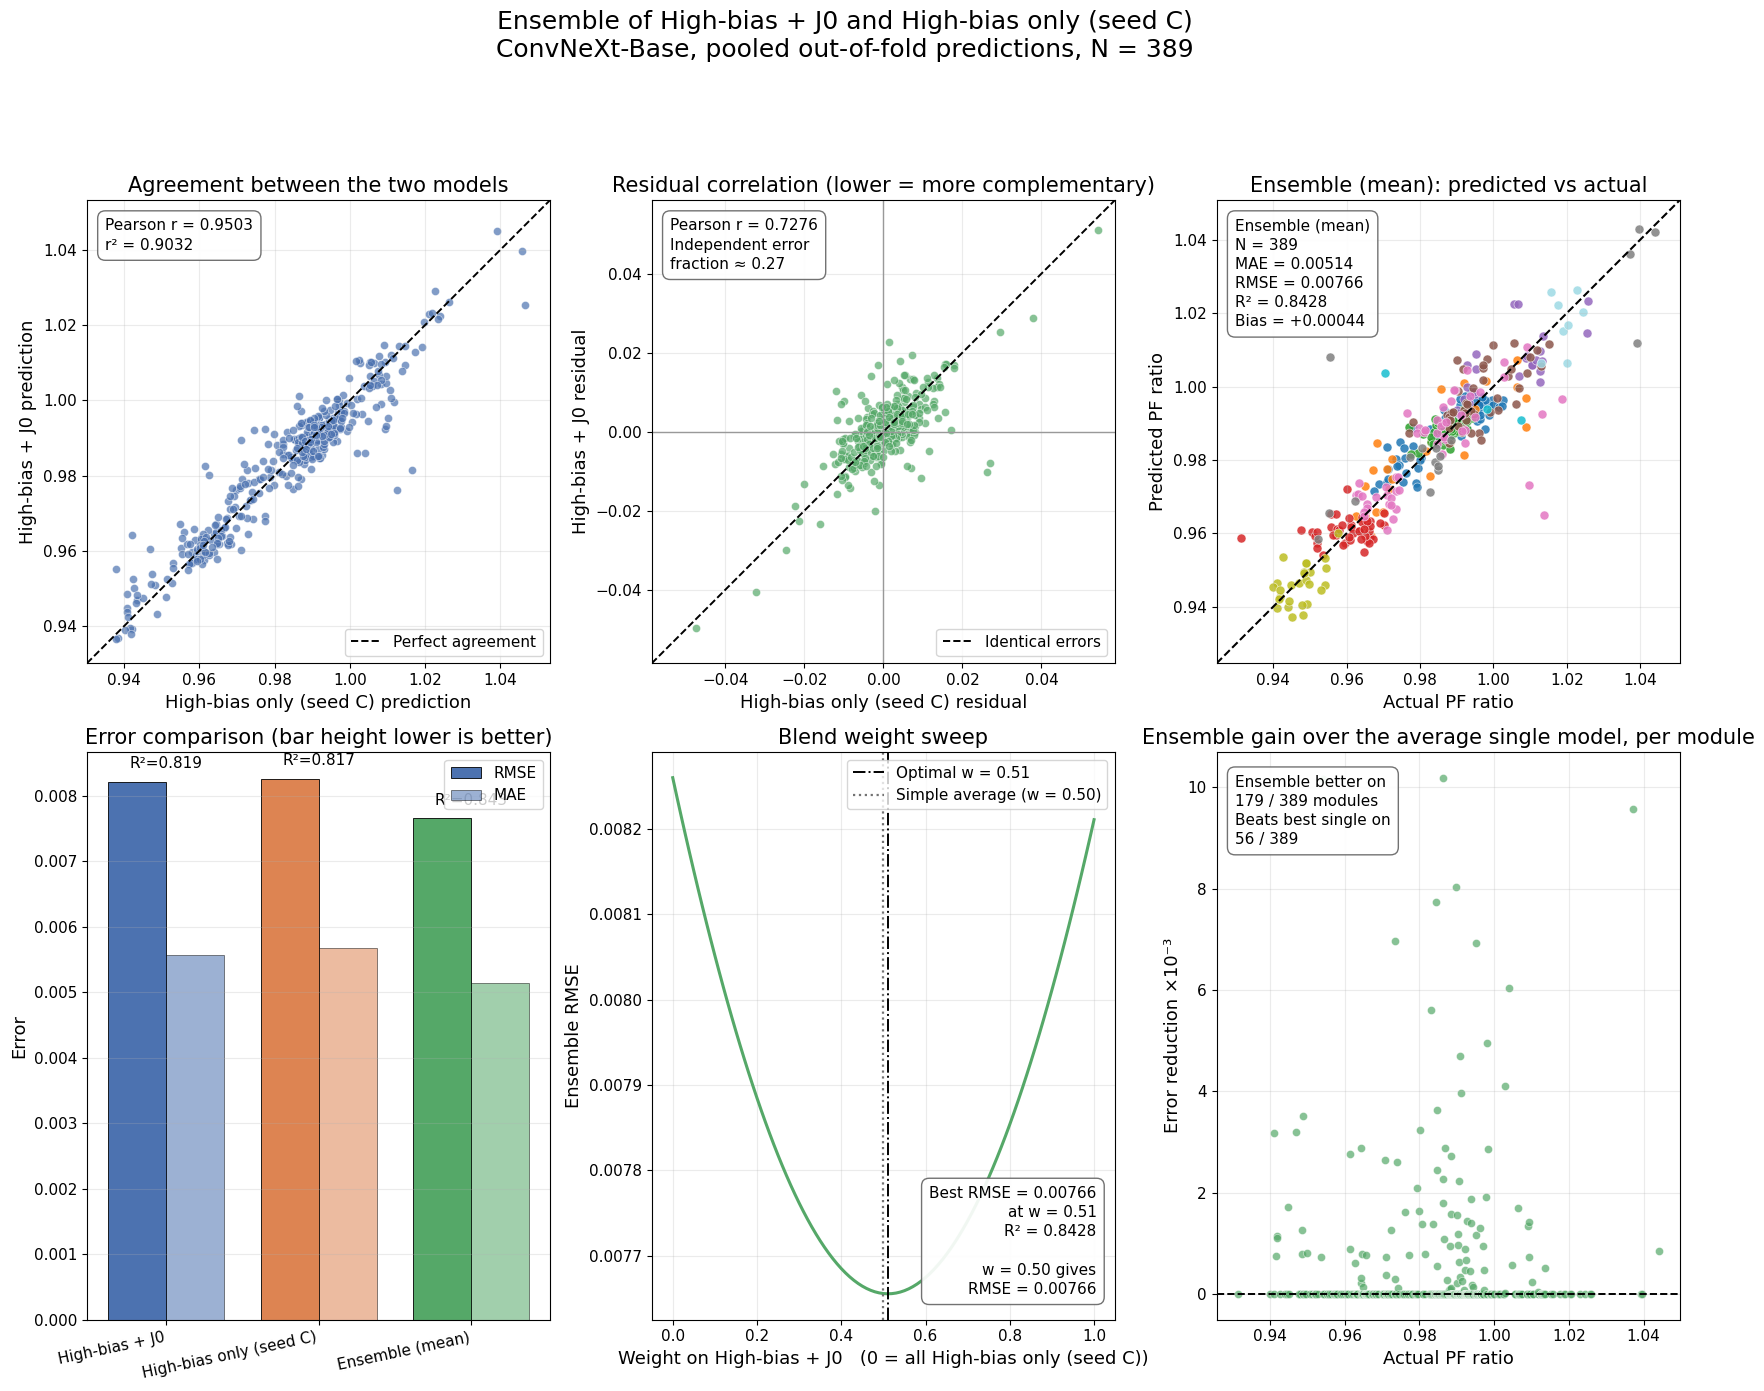


Saved:
- ensemble_convnext_highbias_j0_vs_highbias_only_seedC_figure.png
- ensemble_convnext_highbias_j0_vs_highbias_only_seedC_figure.pdf
- ensemble_convnext_highbias_j0_vs_highbias_only_seedC_predictions.csv
- ensemble_convnext_highbias_j0_vs_highbias_only_seedC_metrics.csv


In [6]:
"""
Ensemble analysis: high-bias + J0  vs  high-bias only

Reads the two out-of-fold prediction files, averages them, and produces a
multi-panel figure plus a metrics table.

IMPORTANT CAVEAT FOR THE WRITE-UP
---------------------------------
Averaging ANY two independently-trained models reduces prediction variance and
usually improves R2, whether or not their inputs differ. Part of the ensemble
gain here is therefore plain variance reduction, not physics.

To claim the J0 channel contributes complementary information, run the control:
train a second high-bias-only model with a different seed and average those two.
Then compare:

    gain from (high+J0) + (high only)      <- what this script measures
    gain from (high only A) + (high only B) <- the control

Only the excess of the first over the second is attributable to the J0 map.
Set CONTROL_CSV below once you have that second high-bias-only run and the
script will compute both.
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import mean_absolute_error, r2_score


# =========================================================
# CONFIG
# =========================================================
MODEL_A_CSV = "cv5_convnext_base_highbias_j0_oof_test_predictions.csv"
MODEL_B_CSV = "cv5_convnext_base_highbias_only_seedC_oof_test_predictions.csv"

MODEL_A_LABEL = "High-bias + J0"
MODEL_B_LABEL = "High-bias only (seed C)"
ENSEMBLE_LABEL = "Ensemble (mean)"

# Optional control: a second high-bias-only run with a different seed.
# Leave as None until you have it.
CONTROL_CSV = None
CONTROL_LABEL = "High-bias only (seed B)"

# Blend weight: predicted = W * A + (1 - W) * B. 0.5 = simple average.
ENSEMBLE_WEIGHT = 0.5

OUTPUT_PREFIX = "ensemble_convnext_highbias_j0_vs_highbias_only_seedC"

# ---- Font sizes: change these to control the figure text ----
FONT = {
    "title": 15,          # panel titles
    "suptitle": 18,       # figure title
    "axis_label": 13,     # x and y axis labels
    "tick": 11,           # tick numbers
    "legend": 11,
    "annotation": 11,     # metric boxes inside panels
}

# ---- Other appearance ----
FIGSIZE = (17, 14)
DPI = 300
POINT_SIZE = 34
POINT_ALPHA = 0.70
COLOR_A = "#4C72B0"
COLOR_B = "#DD8452"
COLOR_ENSEMBLE = "#55A868"


def apply_font_sizes():
    plt.rcParams.update({
        "axes.titlesize": FONT["title"],
        "axes.labelsize": FONT["axis_label"],
        "xtick.labelsize": FONT["tick"],
        "ytick.labelsize": FONT["tick"],
        "legend.fontsize": FONT["legend"],
        "figure.titlesize": FONT["suptitle"],
    })


# =========================================================
# LOAD AND ALIGN
# =========================================================
def load_predictions(path, label):
    if not os.path.exists(path):
        raise FileNotFoundError(f"{label}: file not found -> {path}")

    df = pd.read_csv(path)

    needed = {"sample_uid", "actual_pf_ratio", "predicted_pf_ratio"}
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"{label} is missing columns: {sorted(missing)}")

    if df["sample_uid"].duplicated().any():
        raise ValueError(f"{label} contains duplicate sample_uid values.")

    return df.set_index("sample_uid").sort_index()


def metrics(actual, predicted):
    residual = predicted - actual
    return {
        "N": len(actual),
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": float(np.sqrt(np.mean(residual ** 2))),
        "R2": r2_score(actual, predicted),
        "Bias": float(np.mean(residual)),
    }


def metrics_text(name, m):
    return (
        f"{name}\n"
        f"N = {m['N']}\n"
        f"MAE = {m['MAE']:.5f}\n"
        f"RMSE = {m['RMSE']:.5f}\n"
        f"R² = {m['R2']:.4f}\n"
        f"Bias = {m['Bias']:+.5f}"
    )


def annotate(ax, text, loc="upper left"):
    x, y, ha, va = (0.04, 0.96, "left", "top")
    if loc == "lower right":
        x, y, ha, va = (0.96, 0.04, "right", "bottom")

    ax.text(
        x, y, text, transform=ax.transAxes, ha=ha, va=va,
        fontsize=FONT["annotation"], linespacing=1.35,
        bbox=dict(boxstyle="round,pad=0.5", facecolor="white",
                  edgecolor="0.4", alpha=0.92),
        zorder=6,
    )


# =========================================================
# PANELS
# =========================================================
def panel_model_correlation(ax, pred_a, pred_b):
    """Do the two models agree? Tight cloud = redundant, spread = complementary."""
    lo = min(pred_a.min(), pred_b.min())
    hi = max(pred_a.max(), pred_b.max())
    pad = (hi - lo) * 0.06
    lo, hi = lo - pad, hi + pad

    ax.scatter(pred_b, pred_a, s=POINT_SIZE, alpha=POINT_ALPHA,
               color=COLOR_A, edgecolors="white", linewidths=0.4)
    ax.plot([lo, hi], [lo, hi], "--", color="black", linewidth=1.4,
            label="Perfect agreement")

    r = np.corrcoef(pred_a, pred_b)[0, 1]

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(f"{MODEL_B_LABEL} prediction")
    ax.set_ylabel(f"{MODEL_A_LABEL} prediction")
    ax.set_title("Agreement between the two models")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="lower right")

    annotate(ax, f"Pearson r = {r:.4f}\nr² = {r ** 2:.4f}")


def panel_residual_correlation(ax, res_a, res_b):
    """
    The key panel for the ensemble argument. Residual correlation well below 1
    means the two models fail on different modules, which is exactly what makes
    averaging help.
    """
    lim = max(np.abs(res_a).max(), np.abs(res_b).max()) * 1.08

    ax.scatter(res_b, res_a, s=POINT_SIZE, alpha=POINT_ALPHA,
               color=COLOR_ENSEMBLE, edgecolors="white", linewidths=0.4)
    ax.plot([-lim, lim], [-lim, lim], "--", color="black", linewidth=1.4,
            label="Identical errors")
    ax.axhline(0, color="0.6", linewidth=1.0)
    ax.axvline(0, color="0.6", linewidth=1.0)

    r = np.corrcoef(res_a, res_b)[0, 1]

    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(f"{MODEL_B_LABEL} residual")
    ax.set_ylabel(f"{MODEL_A_LABEL} residual")
    ax.set_title("Residual correlation (lower = more complementary)")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="lower right")

    annotate(
        ax,
        f"Pearson r = {r:.4f}\n"
        f"Independent error\nfraction ≈ {1 - r:.2f}",
    )


def panel_ensemble_scatter(ax, actual, pred_ens, make_values=None):
    lo = min(actual.min(), pred_ens.min())
    hi = max(actual.max(), pred_ens.max())
    pad = (hi - lo) * 0.06
    lo, hi = lo - pad, hi + pad

    if make_values is not None:
        makes = sorted(pd.Series(make_values).astype(str).unique())
        cmap = plt.colormaps.get_cmap("tab20")
        palette = {m: cmap(i / max(1, len(makes) - 1)) for i, m in enumerate(makes)}

        for m in makes:
            sel = np.asarray(make_values).astype(str) == m
            ax.scatter(actual[sel], pred_ens[sel], s=POINT_SIZE + 8,
                       color=palette[m], alpha=0.85, edgecolors="white",
                       linewidths=0.4, label=m)
    else:
        ax.scatter(actual, pred_ens, s=POINT_SIZE + 8, color=COLOR_ENSEMBLE,
                   alpha=0.85, edgecolors="white", linewidths=0.4)

    ax.plot([lo, hi], [lo, hi], "--", color="black", linewidth=1.5)

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Actual PF ratio")
    ax.set_ylabel("Predicted PF ratio")
    ax.set_title(f"{ENSEMBLE_LABEL}: predicted vs actual")
    ax.grid(True, alpha=0.25)

    annotate(ax, metrics_text(ENSEMBLE_LABEL, metrics(actual, pred_ens)))


def panel_metric_bars(ax, rows):
    """Side-by-side RMSE and MAE for every model."""
    names = [r["model"] for r in rows]
    x = np.arange(len(names))
    width = 0.38

    colors = [COLOR_A, COLOR_B, COLOR_ENSEMBLE, "0.55"][:len(names)]

    ax.bar(x - width / 2, [r["RMSE"] for r in rows], width,
           label="RMSE", color=colors, edgecolor="black", linewidth=0.6)
    ax.bar(x + width / 2, [r["MAE"] for r in rows], width,
           label="MAE", color=colors, alpha=0.55,
           edgecolor="black", linewidth=0.6)

    for i, r in enumerate(rows):
        ax.text(i, max(r["RMSE"], r["MAE"]) * 1.02, f"R²={r['R2']:.3f}",
                ha="center", va="bottom", fontsize=FONT["annotation"])

    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=12, ha="right")
    ax.set_ylabel("Error")
    ax.set_title("Error comparison (bar height lower is better)")
    ax.grid(True, alpha=0.25, axis="y")
    ax.legend()


def panel_weight_sweep(ax, actual, pred_a, pred_b):
    """
    How does performance vary with blend weight? A minimum near the middle is
    evidence both models carry useful and partly independent information.
    """
    weights = np.linspace(0, 1, 101)
    rmses, r2s = [], []

    for w in weights:
        p = w * pred_a + (1 - w) * pred_b
        rmses.append(np.sqrt(np.mean((p - actual) ** 2)))
        r2s.append(r2_score(actual, p))

    rmses = np.asarray(rmses)
    best = int(np.argmin(rmses))

    ax.plot(weights, rmses, linewidth=2.2, color=COLOR_ENSEMBLE)
    ax.axvline(weights[best], linestyle="-.", color="black", linewidth=1.4,
               label=f"Optimal w = {weights[best]:.2f}")
    ax.axvline(0.5, linestyle=":", color="0.45", linewidth=1.6,
               label="Simple average (w = 0.50)")

    ax.set_xlabel(f"Weight on {MODEL_A_LABEL}   (0 = all {MODEL_B_LABEL})")
    ax.set_ylabel("Ensemble RMSE")
    ax.set_title("Blend weight sweep")
    ax.grid(True, alpha=0.25)
    ax.legend()

    annotate(
        ax,
        f"Best RMSE = {rmses[best]:.5f}\n"
        f"at w = {weights[best]:.2f}\n"
        f"R² = {r2s[best]:.4f}\n\n"
        f"w = 0.50 gives\nRMSE = {rmses[50]:.5f}",
        loc="lower right",
    )

    return float(weights[best]), float(rmses[best])


def panel_per_module_gain(ax, actual, pred_a, pred_b, pred_ens):
    """
    Where does the ensemble actually help? Positive bars = ensemble beat the
    better of the two single models on that module.
    """
    ae_a = np.abs(pred_a - actual)
    ae_b = np.abs(pred_b - actual)
    ae_ens = np.abs(pred_ens - actual)

    best_single = np.minimum(ae_a, ae_b)
    gain_vs_mean_single = (ae_a + ae_b) / 2 - ae_ens

    order = np.argsort(actual)

    ax.scatter(actual[order], gain_vs_mean_single[order] * 1000,
               s=POINT_SIZE, alpha=POINT_ALPHA, color=COLOR_ENSEMBLE,
               edgecolors="white", linewidths=0.4)
    ax.axhline(0, linestyle="--", color="black", linewidth=1.4)

    ax.set_xlabel("Actual PF ratio")
    ax.set_ylabel("Error reduction ×10⁻³")
    ax.set_title("Ensemble gain over the average single model, per module")
    ax.grid(True, alpha=0.25)

    annotate(
        ax,
        f"Ensemble better on\n{int((gain_vs_mean_single > 0).sum())} / {len(actual)} modules\n"
        f"Beats best single on\n{int((ae_ens < best_single).sum())} / {len(actual)}",
    )


# =========================================================
# MAIN
# =========================================================
def main():
    apply_font_sizes()

    a = load_predictions(MODEL_A_CSV, MODEL_A_LABEL)
    b = load_predictions(MODEL_B_CSV, MODEL_B_LABEL)

    common = a.index.intersection(b.index)
    if len(common) == 0:
        raise ValueError("The two files share no sample_uid values.")

    if len(common) < len(a) or len(common) < len(b):
        print(
            f"WARNING: files do not cover the same modules. "
            f"A has {len(a)}, B has {len(b)}, using the {len(common)} in common."
        )

    a = a.loc[common]
    b = b.loc[common]

    actual = a["actual_pf_ratio"].to_numpy()
    actual_b = b["actual_pf_ratio"].to_numpy()

    if not np.allclose(actual, actual_b, atol=1e-9):
        raise ValueError(
            "Ground-truth PF ratios disagree between the two files. "
            "The runs are not on the same targets."
        )

    pred_a = a["predicted_pf_ratio"].to_numpy()
    pred_b = b["predicted_pf_ratio"].to_numpy()
    pred_ens = ENSEMBLE_WEIGHT * pred_a + (1 - ENSEMBLE_WEIGHT) * pred_b

    res_a = pred_a - actual
    res_b = pred_b - actual

    make_values = a["make_plot"].to_numpy() if "make_plot" in a.columns else None

    # ---- Metrics table ----
    rows = [
        {"model": MODEL_A_LABEL, **metrics(actual, pred_a)},
        {"model": MODEL_B_LABEL, **metrics(actual, pred_b)},
        {"model": ENSEMBLE_LABEL, **metrics(actual, pred_ens)},
    ]

    control_pred = None
    if CONTROL_CSV:
        c = load_predictions(CONTROL_CSV, CONTROL_LABEL).loc[common]
        control_pred = c["predicted_pf_ratio"].to_numpy()
        control_ens = 0.5 * pred_b + 0.5 * control_pred
        rows.append({"model": CONTROL_LABEL, **metrics(actual, control_pred)})
        rows.append({
            "model": "Control ensemble (high-only ×2)",
            **metrics(actual, control_ens),
        })

    table = pd.DataFrame(rows)

    print("\n" + "=" * 78)
    print("METRICS")
    print("=" * 78)
    print(table.to_string(index=False, float_format=lambda v: f"{v:.6f}"))

    # ---- Significance of the single-model difference ----
    w = stats.wilcoxon(np.abs(res_a), np.abs(res_b))
    t = stats.ttest_rel(np.abs(res_a), np.abs(res_b))

    print(f"\nPaired test, {MODEL_A_LABEL} vs {MODEL_B_LABEL} (absolute error):")
    print(f"  mean AE difference : {np.mean(np.abs(res_a) - np.abs(res_b)):+.6f}")
    print(f"  Wilcoxon p         : {w.pvalue:.4f}")
    print(f"  paired t-test p    : {t.pvalue:.4f}")
    print(f"  {MODEL_A_LABEL} better on "
          f"{int((np.abs(res_a) < np.abs(res_b)).sum())} / {len(actual)} modules")

    # ---- Significance of the ensemble gain ----
    ae_ens = np.abs(pred_ens - actual)
    ae_best_single = np.minimum(np.abs(res_a), np.abs(res_b))
    ae_mean_single = (np.abs(res_a) + np.abs(res_b)) / 2

    w_ens = stats.wilcoxon(ae_ens, ae_mean_single)
    print(f"\nEnsemble vs average single model (absolute error):")
    print(f"  mean AE difference : {np.mean(ae_ens - ae_mean_single):+.6f}")
    print(f"  Wilcoxon p         : {w_ens.pvalue:.6f}")
    print(f"  ensemble better on "
          f"{int((ae_ens < ae_mean_single).sum())} / {len(actual)} modules")
    print(f"  beats BEST single on "
          f"{int((ae_ens < ae_best_single).sum())} / {len(actual)} modules")

    print(f"\nPrediction correlation : {np.corrcoef(pred_a, pred_b)[0, 1]:.4f}")
    print(f"Residual correlation   : {np.corrcoef(res_a, res_b)[0, 1]:.4f}")

    if CONTROL_CSV is None:
        print(
            "\nNOTE: CONTROL_CSV is not set. Part of the ensemble gain is plain\n"
            "variance reduction from averaging two models, not the J0 channel.\n"
            "Train a second high-bias-only model with a different seed and set\n"
            "CONTROL_CSV to separate the two effects."
        )

    # ---- Figure ----
    fig, axes = plt.subplots(2, 3, figsize=FIGSIZE)

    panel_model_correlation(axes[0, 0], pred_a, pred_b)
    panel_residual_correlation(axes[0, 1], res_a, res_b)
    panel_ensemble_scatter(axes[0, 2], actual, pred_ens, make_values)
    panel_metric_bars(axes[1, 0], rows)
    best_w, best_rmse = panel_weight_sweep(axes[1, 1], actual, pred_a, pred_b)
    panel_per_module_gain(axes[1, 2], actual, pred_a, pred_b, pred_ens)

    fig.suptitle(
        f"Ensemble of {MODEL_A_LABEL} and {MODEL_B_LABEL}\n"
        f"ConvNeXt-Base, pooled out-of-fold predictions, N = {len(actual)}",
        y=0.99,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    fig.savefig(f"{OUTPUT_PREFIX}_figure.png", dpi=DPI, bbox_inches="tight")
    fig.savefig(f"{OUTPUT_PREFIX}_figure.pdf", bbox_inches="tight")
    plt.show()

    # ---- Save ----
    out = a[[c for c in ["ELHPath", "Make", "make_plot", "fold"] if c in a.columns]].copy()
    out["actual_pf_ratio"] = actual
    out[f"pred_{MODEL_A_LABEL}"] = pred_a
    out[f"pred_{MODEL_B_LABEL}"] = pred_b
    out["pred_ensemble"] = pred_ens
    out["residual_ensemble"] = pred_ens - actual
    out["absolute_error_ensemble"] = np.abs(pred_ens - actual)

    if control_pred is not None:
        out[f"pred_{CONTROL_LABEL}"] = control_pred

    out.to_csv(f"{OUTPUT_PREFIX}_predictions.csv")
    table.to_csv(f"{OUTPUT_PREFIX}_metrics.csv", index=False)

    print("\nSaved:")
    print(f"- {OUTPUT_PREFIX}_figure.png")
    print(f"- {OUTPUT_PREFIX}_figure.pdf")
    print(f"- {OUTPUT_PREFIX}_predictions.csv")
    print(f"- {OUTPUT_PREFIX}_metrics.csv")


if __name__ == "__main__":
    main()



METRICS
                  model   N      MAE     RMSE       R2     Bias
         High-bias + J0 389 0.005412 0.008131 0.822700 0.000512
High-bias only (seed C) 389 0.005683 0.008260 0.817018 0.000406
        Ensemble (mean) 389 0.005302 0.007915 0.831975 0.000459

Paired test, High-bias + J0 vs High-bias only (seed C) (absolute error):
  mean AE difference : -0.000271
  Wilcoxon p         : 0.1991
  paired t-test p    : 0.1391
  High-bias + J0 better on 209 / 389 modules

Ensemble vs average single model (absolute error):
  mean AE difference : -0.000246
  Wilcoxon p         : 0.000000
  ensemble better on 157 / 389 modules
  beats BEST single on 35 / 389 modules

Prediction correlation : 0.9763
Residual correlation   : 0.8653

NOTE: CONTROL_CSV is not set. Part of the ensemble gain is plain
variance reduction from averaging two models, not the J0 channel.
Train a second high-bias-only model with a different seed and set
CONTROL_CSV to separate the two effects.


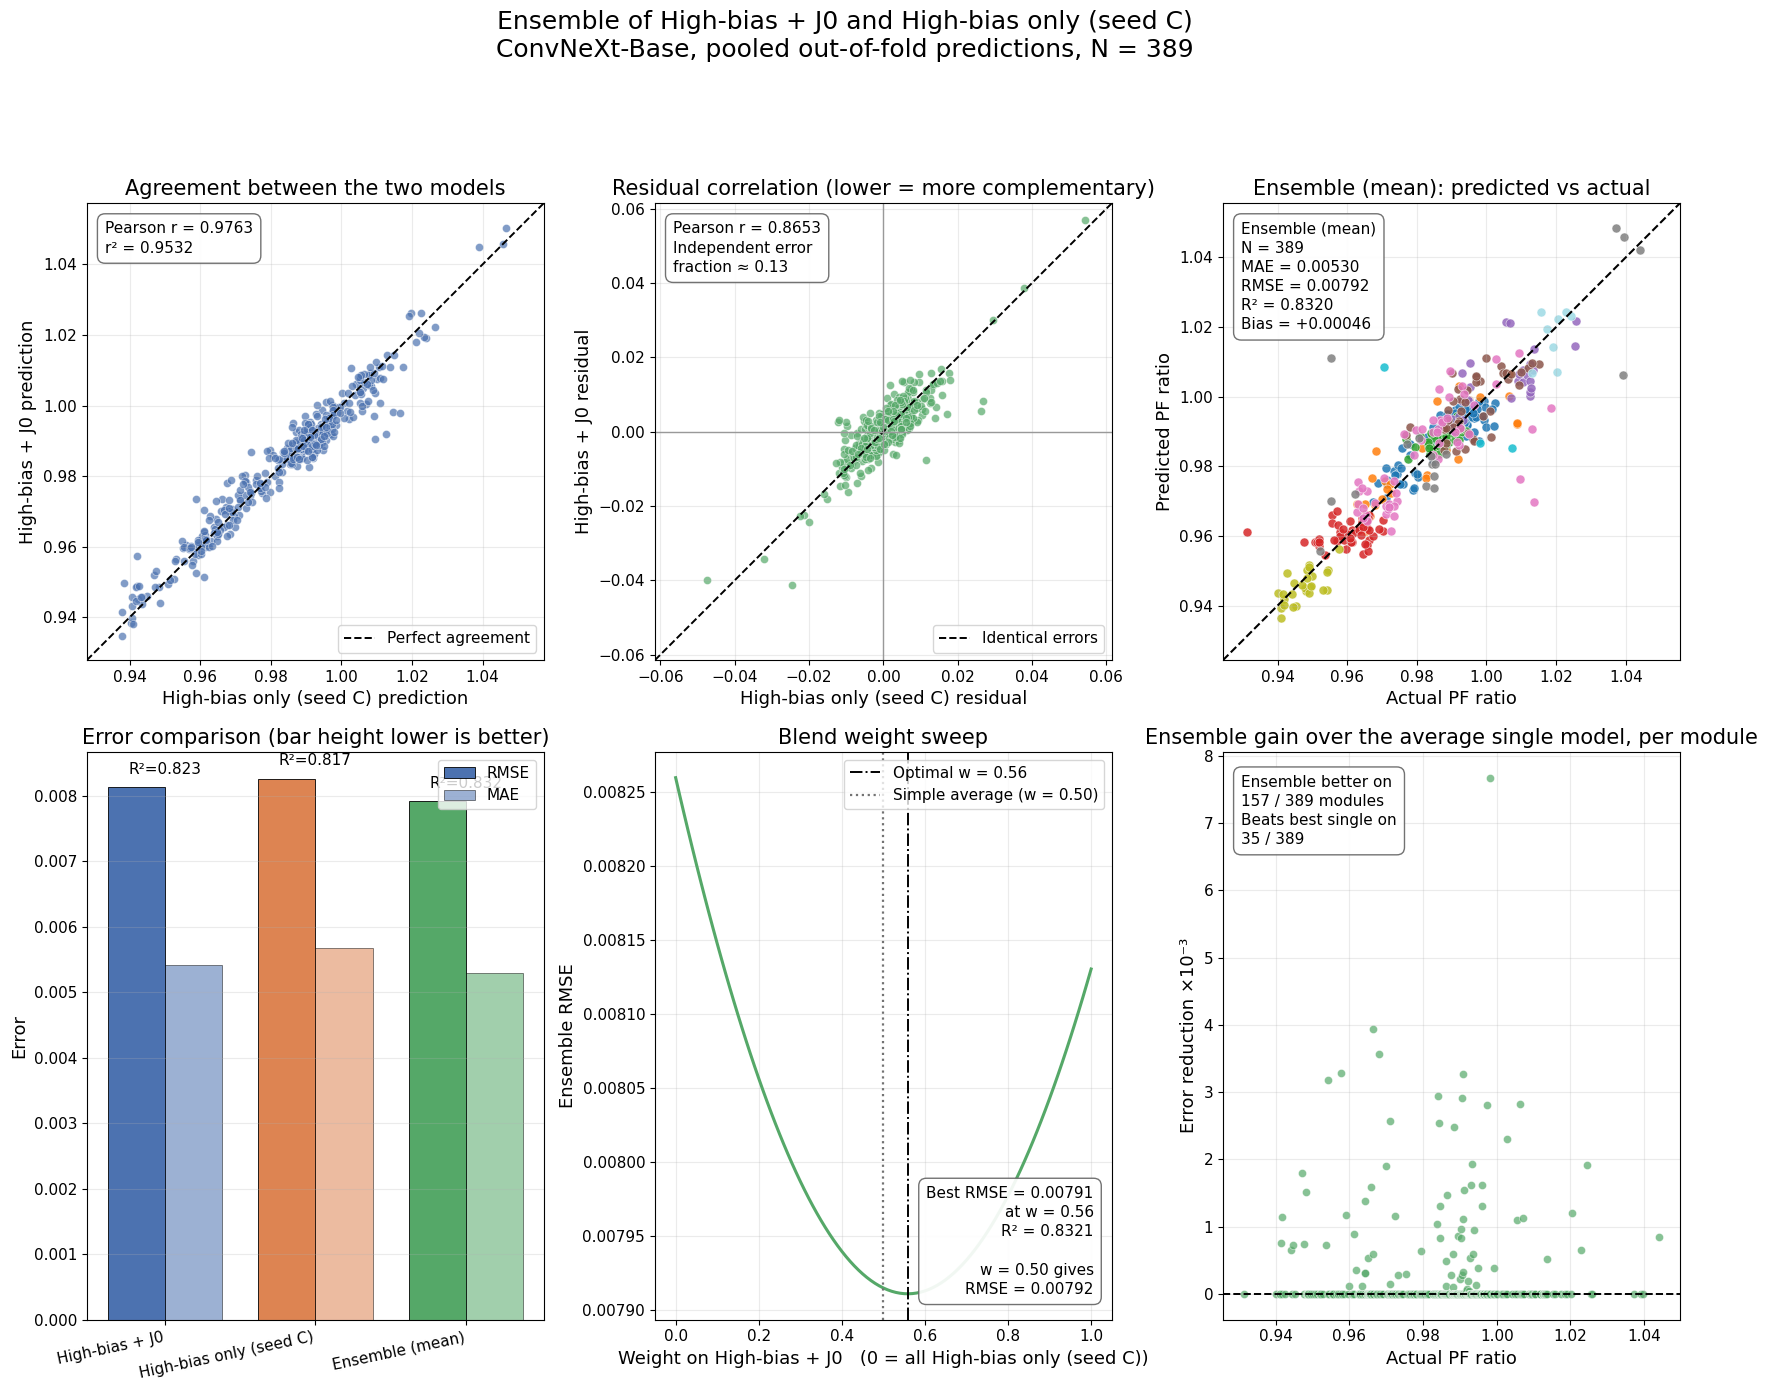


Saved:
- ensemble_convnext_highbias_seed A_vs_highbias_only_seedC_figure.png
- ensemble_convnext_highbias_seed A_vs_highbias_only_seedC_figure.pdf
- ensemble_convnext_highbias_seed A_vs_highbias_only_seedC_predictions.csv
- ensemble_convnext_highbias_seed A_vs_highbias_only_seedC_metrics.csv


In [7]:
"""
Ensemble analysis: high-bias + J0  vs  high-bias only

Reads the two out-of-fold prediction files, averages them, and produces a
multi-panel figure plus a metrics table.

IMPORTANT CAVEAT FOR THE WRITE-UP
---------------------------------
Averaging ANY two independently-trained models reduces prediction variance and
usually improves R2, whether or not their inputs differ. Part of the ensemble
gain here is therefore plain variance reduction, not physics.

To claim the J0 channel contributes complementary information, run the control:
train a second high-bias-only model with a different seed and average those two.
Then compare:

    gain from (high+J0) + (high only)      <- what this script measures
    gain from (high only A) + (high only B) <- the control

Only the excess of the first over the second is attributable to the J0 map.
Set CONTROL_CSV below once you have that second high-bias-only run and the
script will compute both.
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import mean_absolute_error, r2_score


# =========================================================
# CONFIG
# =========================================================
MODEL_A_CSV = "cv5_convnext_base_highbias_only_oof_test_predictions.csv"
MODEL_B_CSV = "cv5_convnext_base_highbias_only_seedC_oof_test_predictions.csv"

MODEL_A_LABEL = "High-bias + J0"
MODEL_B_LABEL = "High-bias only (seed C)"
ENSEMBLE_LABEL = "Ensemble (mean)"

# Optional control: a second high-bias-only run with a different seed.
# Leave as None until you have it.
CONTROL_CSV = None
CONTROL_LABEL = "High-bias only (seed B)"

# Blend weight: predicted = W * A + (1 - W) * B. 0.5 = simple average.
ENSEMBLE_WEIGHT = 0.5

OUTPUT_PREFIX = "ensemble_convnext_highbias_seed A_vs_highbias_only_seedC"

# ---- Font sizes: change these to control the figure text ----
FONT = {
    "title": 15,          # panel titles
    "suptitle": 18,       # figure title
    "axis_label": 13,     # x and y axis labels
    "tick": 11,           # tick numbers
    "legend": 11,
    "annotation": 11,     # metric boxes inside panels
}

# ---- Other appearance ----
FIGSIZE = (17, 14)
DPI = 300
POINT_SIZE = 34
POINT_ALPHA = 0.70
COLOR_A = "#4C72B0"
COLOR_B = "#DD8452"
COLOR_ENSEMBLE = "#55A868"


def apply_font_sizes():
    plt.rcParams.update({
        "axes.titlesize": FONT["title"],
        "axes.labelsize": FONT["axis_label"],
        "xtick.labelsize": FONT["tick"],
        "ytick.labelsize": FONT["tick"],
        "legend.fontsize": FONT["legend"],
        "figure.titlesize": FONT["suptitle"],
    })


# =========================================================
# LOAD AND ALIGN
# =========================================================
def load_predictions(path, label):
    if not os.path.exists(path):
        raise FileNotFoundError(f"{label}: file not found -> {path}")

    df = pd.read_csv(path)

    needed = {"sample_uid", "actual_pf_ratio", "predicted_pf_ratio"}
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"{label} is missing columns: {sorted(missing)}")

    if df["sample_uid"].duplicated().any():
        raise ValueError(f"{label} contains duplicate sample_uid values.")

    return df.set_index("sample_uid").sort_index()


def metrics(actual, predicted):
    residual = predicted - actual
    return {
        "N": len(actual),
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": float(np.sqrt(np.mean(residual ** 2))),
        "R2": r2_score(actual, predicted),
        "Bias": float(np.mean(residual)),
    }


def metrics_text(name, m):
    return (
        f"{name}\n"
        f"N = {m['N']}\n"
        f"MAE = {m['MAE']:.5f}\n"
        f"RMSE = {m['RMSE']:.5f}\n"
        f"R² = {m['R2']:.4f}\n"
        f"Bias = {m['Bias']:+.5f}"
    )


def annotate(ax, text, loc="upper left"):
    x, y, ha, va = (0.04, 0.96, "left", "top")
    if loc == "lower right":
        x, y, ha, va = (0.96, 0.04, "right", "bottom")

    ax.text(
        x, y, text, transform=ax.transAxes, ha=ha, va=va,
        fontsize=FONT["annotation"], linespacing=1.35,
        bbox=dict(boxstyle="round,pad=0.5", facecolor="white",
                  edgecolor="0.4", alpha=0.92),
        zorder=6,
    )


# =========================================================
# PANELS
# =========================================================
def panel_model_correlation(ax, pred_a, pred_b):
    """Do the two models agree? Tight cloud = redundant, spread = complementary."""
    lo = min(pred_a.min(), pred_b.min())
    hi = max(pred_a.max(), pred_b.max())
    pad = (hi - lo) * 0.06
    lo, hi = lo - pad, hi + pad

    ax.scatter(pred_b, pred_a, s=POINT_SIZE, alpha=POINT_ALPHA,
               color=COLOR_A, edgecolors="white", linewidths=0.4)
    ax.plot([lo, hi], [lo, hi], "--", color="black", linewidth=1.4,
            label="Perfect agreement")

    r = np.corrcoef(pred_a, pred_b)[0, 1]

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(f"{MODEL_B_LABEL} prediction")
    ax.set_ylabel(f"{MODEL_A_LABEL} prediction")
    ax.set_title("Agreement between the two models")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="lower right")

    annotate(ax, f"Pearson r = {r:.4f}\nr² = {r ** 2:.4f}")


def panel_residual_correlation(ax, res_a, res_b):
    """
    The key panel for the ensemble argument. Residual correlation well below 1
    means the two models fail on different modules, which is exactly what makes
    averaging help.
    """
    lim = max(np.abs(res_a).max(), np.abs(res_b).max()) * 1.08

    ax.scatter(res_b, res_a, s=POINT_SIZE, alpha=POINT_ALPHA,
               color=COLOR_ENSEMBLE, edgecolors="white", linewidths=0.4)
    ax.plot([-lim, lim], [-lim, lim], "--", color="black", linewidth=1.4,
            label="Identical errors")
    ax.axhline(0, color="0.6", linewidth=1.0)
    ax.axvline(0, color="0.6", linewidth=1.0)

    r = np.corrcoef(res_a, res_b)[0, 1]

    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(f"{MODEL_B_LABEL} residual")
    ax.set_ylabel(f"{MODEL_A_LABEL} residual")
    ax.set_title("Residual correlation (lower = more complementary)")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="lower right")

    annotate(
        ax,
        f"Pearson r = {r:.4f}\n"
        f"Independent error\nfraction ≈ {1 - r:.2f}",
    )


def panel_ensemble_scatter(ax, actual, pred_ens, make_values=None):
    lo = min(actual.min(), pred_ens.min())
    hi = max(actual.max(), pred_ens.max())
    pad = (hi - lo) * 0.06
    lo, hi = lo - pad, hi + pad

    if make_values is not None:
        makes = sorted(pd.Series(make_values).astype(str).unique())
        cmap = plt.colormaps.get_cmap("tab20")
        palette = {m: cmap(i / max(1, len(makes) - 1)) for i, m in enumerate(makes)}

        for m in makes:
            sel = np.asarray(make_values).astype(str) == m
            ax.scatter(actual[sel], pred_ens[sel], s=POINT_SIZE + 8,
                       color=palette[m], alpha=0.85, edgecolors="white",
                       linewidths=0.4, label=m)
    else:
        ax.scatter(actual, pred_ens, s=POINT_SIZE + 8, color=COLOR_ENSEMBLE,
                   alpha=0.85, edgecolors="white", linewidths=0.4)

    ax.plot([lo, hi], [lo, hi], "--", color="black", linewidth=1.5)

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Actual PF ratio")
    ax.set_ylabel("Predicted PF ratio")
    ax.set_title(f"{ENSEMBLE_LABEL}: predicted vs actual")
    ax.grid(True, alpha=0.25)

    annotate(ax, metrics_text(ENSEMBLE_LABEL, metrics(actual, pred_ens)))


def panel_metric_bars(ax, rows):
    """Side-by-side RMSE and MAE for every model."""
    names = [r["model"] for r in rows]
    x = np.arange(len(names))
    width = 0.38

    colors = [COLOR_A, COLOR_B, COLOR_ENSEMBLE, "0.55"][:len(names)]

    ax.bar(x - width / 2, [r["RMSE"] for r in rows], width,
           label="RMSE", color=colors, edgecolor="black", linewidth=0.6)
    ax.bar(x + width / 2, [r["MAE"] for r in rows], width,
           label="MAE", color=colors, alpha=0.55,
           edgecolor="black", linewidth=0.6)

    for i, r in enumerate(rows):
        ax.text(i, max(r["RMSE"], r["MAE"]) * 1.02, f"R²={r['R2']:.3f}",
                ha="center", va="bottom", fontsize=FONT["annotation"])

    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=12, ha="right")
    ax.set_ylabel("Error")
    ax.set_title("Error comparison (bar height lower is better)")
    ax.grid(True, alpha=0.25, axis="y")
    ax.legend()


def panel_weight_sweep(ax, actual, pred_a, pred_b):
    """
    How does performance vary with blend weight? A minimum near the middle is
    evidence both models carry useful and partly independent information.
    """
    weights = np.linspace(0, 1, 101)
    rmses, r2s = [], []

    for w in weights:
        p = w * pred_a + (1 - w) * pred_b
        rmses.append(np.sqrt(np.mean((p - actual) ** 2)))
        r2s.append(r2_score(actual, p))

    rmses = np.asarray(rmses)
    best = int(np.argmin(rmses))

    ax.plot(weights, rmses, linewidth=2.2, color=COLOR_ENSEMBLE)
    ax.axvline(weights[best], linestyle="-.", color="black", linewidth=1.4,
               label=f"Optimal w = {weights[best]:.2f}")
    ax.axvline(0.5, linestyle=":", color="0.45", linewidth=1.6,
               label="Simple average (w = 0.50)")

    ax.set_xlabel(f"Weight on {MODEL_A_LABEL}   (0 = all {MODEL_B_LABEL})")
    ax.set_ylabel("Ensemble RMSE")
    ax.set_title("Blend weight sweep")
    ax.grid(True, alpha=0.25)
    ax.legend()

    annotate(
        ax,
        f"Best RMSE = {rmses[best]:.5f}\n"
        f"at w = {weights[best]:.2f}\n"
        f"R² = {r2s[best]:.4f}\n\n"
        f"w = 0.50 gives\nRMSE = {rmses[50]:.5f}",
        loc="lower right",
    )

    return float(weights[best]), float(rmses[best])


def panel_per_module_gain(ax, actual, pred_a, pred_b, pred_ens):
    """
    Where does the ensemble actually help? Positive bars = ensemble beat the
    better of the two single models on that module.
    """
    ae_a = np.abs(pred_a - actual)
    ae_b = np.abs(pred_b - actual)
    ae_ens = np.abs(pred_ens - actual)

    best_single = np.minimum(ae_a, ae_b)
    gain_vs_mean_single = (ae_a + ae_b) / 2 - ae_ens

    order = np.argsort(actual)

    ax.scatter(actual[order], gain_vs_mean_single[order] * 1000,
               s=POINT_SIZE, alpha=POINT_ALPHA, color=COLOR_ENSEMBLE,
               edgecolors="white", linewidths=0.4)
    ax.axhline(0, linestyle="--", color="black", linewidth=1.4)

    ax.set_xlabel("Actual PF ratio")
    ax.set_ylabel("Error reduction ×10⁻³")
    ax.set_title("Ensemble gain over the average single model, per module")
    ax.grid(True, alpha=0.25)

    annotate(
        ax,
        f"Ensemble better on\n{int((gain_vs_mean_single > 0).sum())} / {len(actual)} modules\n"
        f"Beats best single on\n{int((ae_ens < best_single).sum())} / {len(actual)}",
    )


# =========================================================
# MAIN
# =========================================================
def main():
    apply_font_sizes()

    a = load_predictions(MODEL_A_CSV, MODEL_A_LABEL)
    b = load_predictions(MODEL_B_CSV, MODEL_B_LABEL)

    common = a.index.intersection(b.index)
    if len(common) == 0:
        raise ValueError("The two files share no sample_uid values.")

    if len(common) < len(a) or len(common) < len(b):
        print(
            f"WARNING: files do not cover the same modules. "
            f"A has {len(a)}, B has {len(b)}, using the {len(common)} in common."
        )

    a = a.loc[common]
    b = b.loc[common]

    actual = a["actual_pf_ratio"].to_numpy()
    actual_b = b["actual_pf_ratio"].to_numpy()

    if not np.allclose(actual, actual_b, atol=1e-9):
        raise ValueError(
            "Ground-truth PF ratios disagree between the two files. "
            "The runs are not on the same targets."
        )

    pred_a = a["predicted_pf_ratio"].to_numpy()
    pred_b = b["predicted_pf_ratio"].to_numpy()
    pred_ens = ENSEMBLE_WEIGHT * pred_a + (1 - ENSEMBLE_WEIGHT) * pred_b

    res_a = pred_a - actual
    res_b = pred_b - actual

    make_values = a["make_plot"].to_numpy() if "make_plot" in a.columns else None

    # ---- Metrics table ----
    rows = [
        {"model": MODEL_A_LABEL, **metrics(actual, pred_a)},
        {"model": MODEL_B_LABEL, **metrics(actual, pred_b)},
        {"model": ENSEMBLE_LABEL, **metrics(actual, pred_ens)},
    ]

    control_pred = None
    if CONTROL_CSV:
        c = load_predictions(CONTROL_CSV, CONTROL_LABEL).loc[common]
        control_pred = c["predicted_pf_ratio"].to_numpy()
        control_ens = 0.5 * pred_b + 0.5 * control_pred
        rows.append({"model": CONTROL_LABEL, **metrics(actual, control_pred)})
        rows.append({
            "model": "Control ensemble (high-only ×2)",
            **metrics(actual, control_ens),
        })

    table = pd.DataFrame(rows)

    print("\n" + "=" * 78)
    print("METRICS")
    print("=" * 78)
    print(table.to_string(index=False, float_format=lambda v: f"{v:.6f}"))

    # ---- Significance of the single-model difference ----
    w = stats.wilcoxon(np.abs(res_a), np.abs(res_b))
    t = stats.ttest_rel(np.abs(res_a), np.abs(res_b))

    print(f"\nPaired test, {MODEL_A_LABEL} vs {MODEL_B_LABEL} (absolute error):")
    print(f"  mean AE difference : {np.mean(np.abs(res_a) - np.abs(res_b)):+.6f}")
    print(f"  Wilcoxon p         : {w.pvalue:.4f}")
    print(f"  paired t-test p    : {t.pvalue:.4f}")
    print(f"  {MODEL_A_LABEL} better on "
          f"{int((np.abs(res_a) < np.abs(res_b)).sum())} / {len(actual)} modules")

    # ---- Significance of the ensemble gain ----
    ae_ens = np.abs(pred_ens - actual)
    ae_best_single = np.minimum(np.abs(res_a), np.abs(res_b))
    ae_mean_single = (np.abs(res_a) + np.abs(res_b)) / 2

    w_ens = stats.wilcoxon(ae_ens, ae_mean_single)
    print(f"\nEnsemble vs average single model (absolute error):")
    print(f"  mean AE difference : {np.mean(ae_ens - ae_mean_single):+.6f}")
    print(f"  Wilcoxon p         : {w_ens.pvalue:.6f}")
    print(f"  ensemble better on "
          f"{int((ae_ens < ae_mean_single).sum())} / {len(actual)} modules")
    print(f"  beats BEST single on "
          f"{int((ae_ens < ae_best_single).sum())} / {len(actual)} modules")

    print(f"\nPrediction correlation : {np.corrcoef(pred_a, pred_b)[0, 1]:.4f}")
    print(f"Residual correlation   : {np.corrcoef(res_a, res_b)[0, 1]:.4f}")

    if CONTROL_CSV is None:
        print(
            "\nNOTE: CONTROL_CSV is not set. Part of the ensemble gain is plain\n"
            "variance reduction from averaging two models, not the J0 channel.\n"
            "Train a second high-bias-only model with a different seed and set\n"
            "CONTROL_CSV to separate the two effects."
        )

    # ---- Figure ----
    fig, axes = plt.subplots(2, 3, figsize=FIGSIZE)

    panel_model_correlation(axes[0, 0], pred_a, pred_b)
    panel_residual_correlation(axes[0, 1], res_a, res_b)
    panel_ensemble_scatter(axes[0, 2], actual, pred_ens, make_values)
    panel_metric_bars(axes[1, 0], rows)
    best_w, best_rmse = panel_weight_sweep(axes[1, 1], actual, pred_a, pred_b)
    panel_per_module_gain(axes[1, 2], actual, pred_a, pred_b, pred_ens)

    fig.suptitle(
        f"Ensemble of {MODEL_A_LABEL} and {MODEL_B_LABEL}\n"
        f"ConvNeXt-Base, pooled out-of-fold predictions, N = {len(actual)}",
        y=0.99,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    fig.savefig(f"{OUTPUT_PREFIX}_figure.png", dpi=DPI, bbox_inches="tight")
    fig.savefig(f"{OUTPUT_PREFIX}_figure.pdf", bbox_inches="tight")
    plt.show()

    # ---- Save ----
    out = a[[c for c in ["ELHPath", "Make", "make_plot", "fold"] if c in a.columns]].copy()
    out["actual_pf_ratio"] = actual
    out[f"pred_{MODEL_A_LABEL}"] = pred_a
    out[f"pred_{MODEL_B_LABEL}"] = pred_b
    out["pred_ensemble"] = pred_ens
    out["residual_ensemble"] = pred_ens - actual
    out["absolute_error_ensemble"] = np.abs(pred_ens - actual)

    if control_pred is not None:
        out[f"pred_{CONTROL_LABEL}"] = control_pred

    out.to_csv(f"{OUTPUT_PREFIX}_predictions.csv")
    table.to_csv(f"{OUTPUT_PREFIX}_metrics.csv", index=False)

    print("\nSaved:")
    print(f"- {OUTPUT_PREFIX}_figure.png")
    print(f"- {OUTPUT_PREFIX}_figure.pdf")
    print(f"- {OUTPUT_PREFIX}_predictions.csv")
    print(f"- {OUTPUT_PREFIX}_metrics.csv")


if __name__ == "__main__":
    main()


Modul yang dipakai: 389

MODEL TUNGGAL
             model   N      MAE     RMSE       R2     Bias
    High-bias + J0 389 0.005572 0.008211 0.819191 0.000473
High-bias only (A) 389 0.005412 0.008131 0.822700 0.000512
High-bias only (B) 389 0.005410 0.008166 0.821177 0.000121
High-bias only (C) 389 0.005683 0.008260 0.817018 0.000406

ENSEMBLE KONTROL (H+H, input identik)
model   N      MAE     RMSE       R2     Bias
H1+H2 389 0.005155 0.007905 0.832388 0.000317
H1+H3 389 0.005302 0.007915 0.831975 0.000459
H2+H3 389 0.005354 0.007990 0.828793 0.000264

ENSEMBLE CROSS (J+H, input berbeda)
model   N      MAE     RMSE       R2     Bias
 J+H1 389 0.005064 0.007693 0.841255 0.000493
 J+H2 389 0.005070 0.007669 0.842243 0.000297
 J+H3 389 0.005142 0.007656 0.842815 0.000440

DEKOMPOSISI GAIN
  Model tunggal terbaik      : R² = 0.8227
  Kontrol  (rata-rata ± sd)  : R² = 0.8311 ± 0.0020
  Cross    (rata-rata ± sd)  : R² = 0.8421 ± 0.0008

  Gain dari averaging saja   : +0.0084
  Gain tambahan d

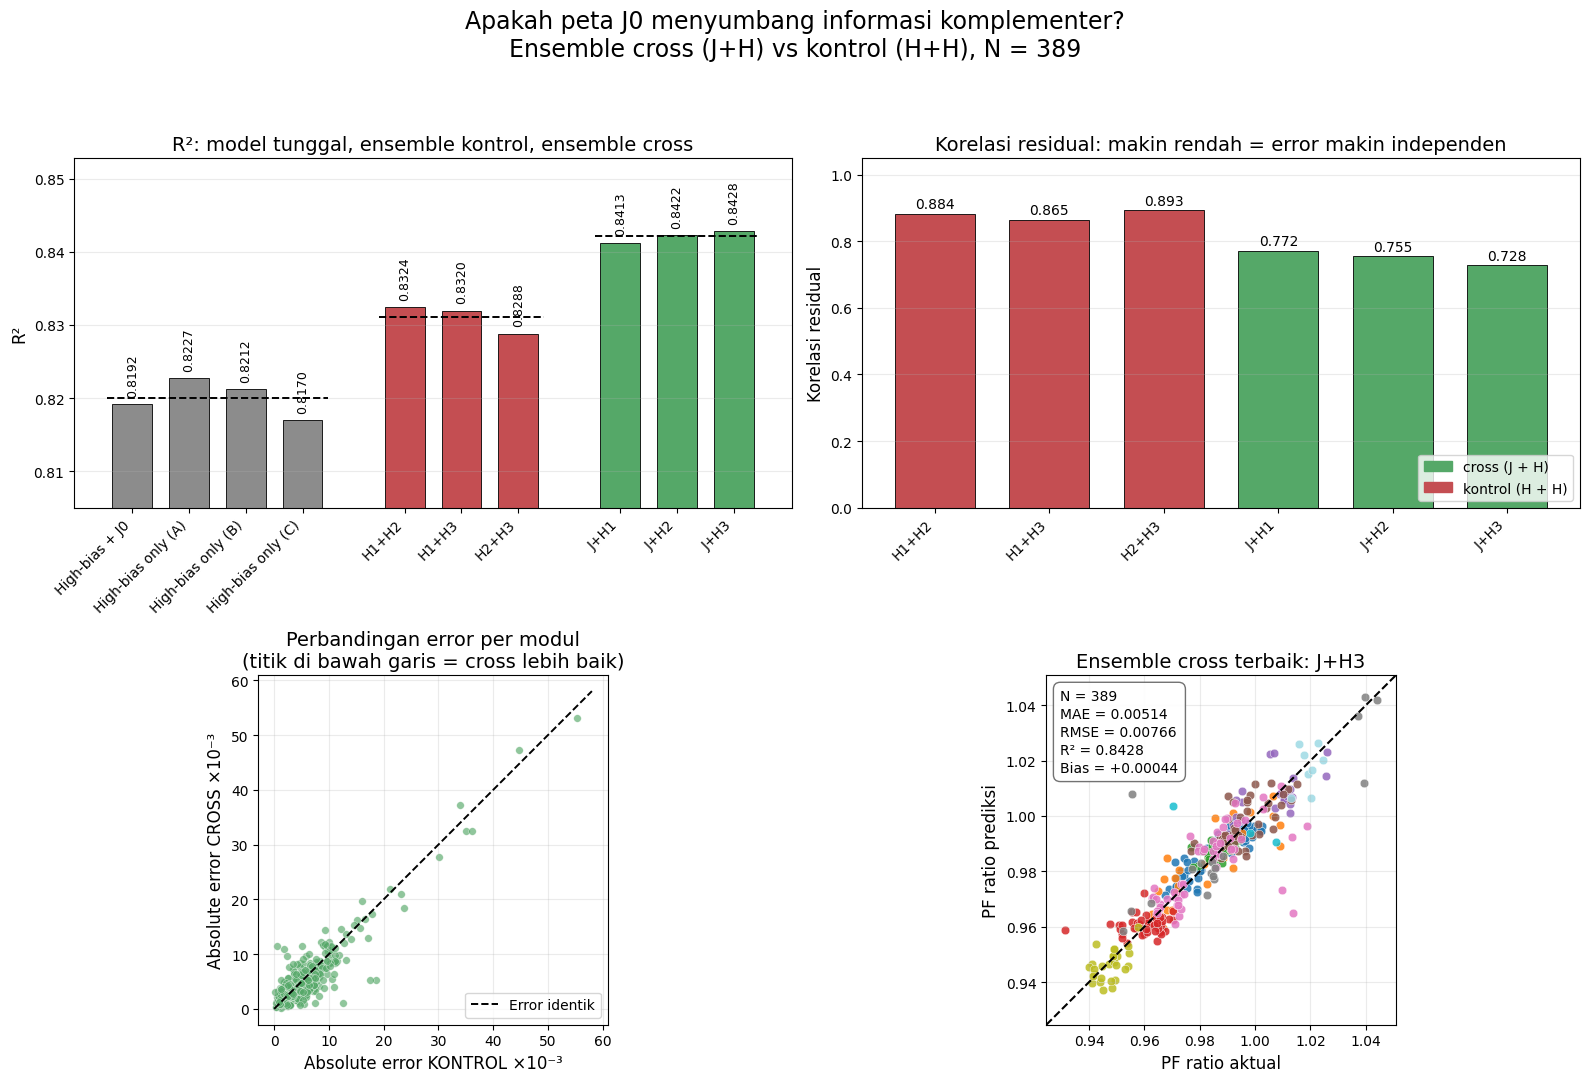


Disimpan:
- ensemble_cross_vs_control_figure.png
- ensemble_cross_vs_control_figure.pdf
- ensemble_cross_vs_control_metrics.csv
- ensemble_cross_vs_control_residual_correlations.csv
- ensemble_cross_vs_control_tests.csv
- ensemble_cross_vs_control_predictions.csv


In [8]:
"""
Analisis ensemble: apakah kanal J0 menyumbang informasi komplementer?

Desain
------
4 model, semuanya out-of-fold pada 389 modul yang sama:

    J   = high-bias + J0      (J0 diturunkan dari citra low-bias)
    H1  = high-bias only, seed A
    H2  = high-bias only, seed B
    H3  = high-bias only, seed C

Dari situ terbentuk dua kelompok ensemble berpasangan:

    CROSS   : J+H1, J+H2, J+H3        (input berbeda)
    KONTROL : H1+H2, H1+H3, H2+H3     (input identik, hanya beda seed)

Kontrol menangkap gain yang murni berasal dari variance reduction. Kelebihan
CROSS di atas KONTROL adalah bagian yang bisa diatribusikan ke informasi
komplementer dari peta J0.

Tiga bukti yang dihasilkan skrip ini
------------------------------------
1. Tabel R²/RMSE semua model tunggal dan semua ensemble.
2. Korelasi residual tiap pasangan. Ini MEKANISMEnya: kalau pasangan cross
   punya korelasi residual lebih rendah daripada kontrol, itulah alasan
   averaging lebih menolong. Bukti ini tidak butuh training tambahan dan
   jauh lebih stabil daripada selisih R².
3. Uji Wilcoxon berpasangan per-modul. Karena pasangan-pasangan ensemble
   saling berbagi model (H2 muncul di beberapa pasangan), baris tabel TIDAK
   independen dan tidak boleh diuji dengan t-test antar baris. Solusinya:
   rata-ratakan absolute error per modul dulu di dalam tiap kelompok, baru
   uji 389 nilai berpasangan itu.
"""

import os
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import mean_absolute_error, r2_score


# =========================================================
# CONFIG
# =========================================================
# Sesuaikan nama file di bawah ini.
MODEL_FILES = {
    "J":  "cv5_convnext_base_highbias_j0_oof_test_predictions.csv",
    "H1": "cv5_convnext_base_highbias_only_oof_test_predictions.csv",
    "H2": "cv5_convnext_base_highbias_only_seedB_oof_test_predictions.csv",
    "H3": "cv5_convnext_base_highbias_only_seedC_oof_test_predictions.csv",
}

PHYSICS_MODEL = "J"                       # model dengan kanal J0
BASELINE_MODELS = ["H1", "H2", "H3"]      # model high-bias only

MODEL_LABELS = {
    "J":  "High-bias + J0",
    "H1": "High-bias only (A)",
    "H2": "High-bias only (B)",
    "H3": "High-bias only (C)",
}

OUTPUT_PREFIX = "ensemble_cross_vs_control"

FONT = {
    "title": 14,
    "suptitle": 17,
    "axis_label": 12,
    "tick": 10,
    "legend": 10,
    "annotation": 10,
}

FIGSIZE = (16, 11)
DPI = 300
COLOR_CROSS = "#55A868"
COLOR_CONTROL = "#C44E52"
COLOR_SINGLE = "0.55"


def apply_font_sizes():
    plt.rcParams.update({
        "axes.titlesize": FONT["title"],
        "axes.labelsize": FONT["axis_label"],
        "xtick.labelsize": FONT["tick"],
        "ytick.labelsize": FONT["tick"],
        "legend.fontsize": FONT["legend"],
        "figure.titlesize": FONT["suptitle"],
    })


# =========================================================
# LOAD
# =========================================================
def load_all(model_files):
    frames = {}

    for key, path in model_files.items():
        if not os.path.exists(path):
            raise FileNotFoundError(f"Model '{key}': file tidak ditemukan -> {path}")

        df = pd.read_csv(path)

        needed = {"sample_uid", "actual_pf_ratio", "predicted_pf_ratio"}
        missing = needed - set(df.columns)
        if missing:
            raise ValueError(f"Model '{key}' kekurangan kolom: {sorted(missing)}")

        if df["sample_uid"].duplicated().any():
            raise ValueError(f"Model '{key}' punya sample_uid duplikat.")

        frames[key] = df.set_index("sample_uid").sort_index()

    keys = list(frames)
    common = frames[keys[0]].index
    for k in keys[1:]:
        common = common.intersection(frames[k].index)

    if len(common) == 0:
        raise ValueError("Tidak ada sample_uid yang sama di semua file.")

    for k in keys:
        if len(frames[k]) != len(common):
            print(
                f"PERINGATAN: '{k}' punya {len(frames[k])} modul, "
                f"irisan bersama {len(common)}. Memakai irisan saja."
            )
        frames[k] = frames[k].loc[common]

    actual = frames[keys[0]]["actual_pf_ratio"].to_numpy()

    for k in keys[1:]:
        if not np.allclose(actual, frames[k]["actual_pf_ratio"].to_numpy(), atol=1e-9):
            raise ValueError(
                f"Nilai aktual PF berbeda antara '{keys[0]}' dan '{k}'. "
                "Model-model ini bukan pada target yang sama."
            )

    preds = {k: frames[k]["predicted_pf_ratio"].to_numpy() for k in keys}
    meta = frames[keys[0]]

    return actual, preds, meta


def metrics(actual, predicted):
    residual = predicted - actual
    return {
        "N": len(actual),
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": float(np.sqrt(np.mean(residual ** 2))),
        "R2": r2_score(actual, predicted),
        "Bias": float(np.mean(residual)),
    }


# =========================================================
# ANALISIS
# =========================================================
def build_ensembles(preds):
    cross = {
        f"{PHYSICS_MODEL}+{h}": 0.5 * preds[PHYSICS_MODEL] + 0.5 * preds[h]
        for h in BASELINE_MODELS
    }

    control = {
        f"{x}+{y}": 0.5 * preds[x] + 0.5 * preds[y]
        for x, y in itertools.combinations(BASELINE_MODELS, 2)
    }

    return cross, control


def residual_correlations(actual, preds):
    rows = []
    keys = list(preds)

    for x, y in itertools.combinations(keys, 2):
        rx = preds[x] - actual
        ry = preds[y] - actual

        pair_type = (
            "cross" if PHYSICS_MODEL in (x, y) else "control"
        )

        rows.append({
            "pair": f"{x}+{y}",
            "type": pair_type,
            "residual_r": float(np.corrcoef(rx, ry)[0, 1]),
            "prediction_r": float(np.corrcoef(preds[x], preds[y])[0, 1]),
        })

    return pd.DataFrame(rows).sort_values(["type", "pair"]).reset_index(drop=True)


def exact_separation_test(cross_values, control_values):
    """
    Uji permutasi eksak pada nilai R² kelompok.

    Hipotesis nol: label 'cross'/'control' tidak berarti apa-apa, jadi setiap
    pembagian nilai ke dua kelompok sama mungkinnya. Dengan 3 lawan 3 ada
    C(6,3) = 20 pembagian, sehingga p satu sisi terkecil yang mungkin adalah
    1/20 = 0.05. Kalau kedua kelompok terpisah sempurna, p = 0.05.
    """
    all_values = np.concatenate([cross_values, control_values])
    n_cross = len(cross_values)
    observed = np.mean(cross_values) - np.mean(control_values)

    count = 0
    total = 0

    for combo in itertools.combinations(range(len(all_values)), n_cross):
        mask = np.zeros(len(all_values), dtype=bool)
        mask[list(combo)] = True

        diff = np.mean(all_values[mask]) - np.mean(all_values[~mask])

        total += 1
        if diff >= observed - 1e-12:
            count += 1

    return observed, count / total, total


def paired_module_test(actual, cross, control):
    """
    Wilcoxon berpasangan per-modul.

    Absolute error dirata-ratakan dulu di dalam tiap kelompok agar
    ketergantungan antar pasangan (model yang dipakai berulang) tidak
    dihitung sebagai bukti tambahan.
    """
    ae_cross = np.mean([np.abs(p - actual) for p in cross.values()], axis=0)
    ae_control = np.mean([np.abs(p - actual) for p in control.values()], axis=0)

    w = stats.wilcoxon(ae_cross, ae_control)
    t = stats.ttest_rel(ae_cross, ae_control)

    return {
        "mean_ae_cross": float(np.mean(ae_cross)),
        "mean_ae_control": float(np.mean(ae_control)),
        "mean_difference": float(np.mean(ae_cross - ae_control)),
        "cross_better_n": int((ae_cross < ae_control).sum()),
        "n_total": len(actual),
        "wilcoxon_p": float(w.pvalue),
        "ttest_p": float(t.pvalue),
    }, ae_cross, ae_control


# =========================================================
# PANEL
# =========================================================
def panel_r2_comparison(ax, single_rows, cross_rows, control_rows):
    groups = [
        ("Model tunggal", single_rows, COLOR_SINGLE),
        ("Kontrol\n(H+H)", control_rows, COLOR_CONTROL),
        ("Cross\n(J+H)", cross_rows, COLOR_CROSS),
    ]

    x_pos = 0
    ticks, labels = [], []

    for name, rows, color in groups:
        values = [r["R2"] for r in rows]
        xs = np.arange(len(values)) + x_pos

        ax.bar(xs, values, 0.7, color=color, edgecolor="black", linewidth=0.6)

        for xi, r in zip(xs, rows):
            ax.text(xi, r["R2"] + 0.001, f"{r['R2']:.4f}",
                    ha="center", va="bottom", fontsize=FONT["annotation"] - 1,
                    rotation=90)

        if len(values) > 1:
            ax.hlines(np.mean(values), xs[0] - 0.45, xs[-1] + 0.45,
                      linestyle="--", color="black", linewidth=1.4)

        ticks.extend(xs)
        labels.extend([r["model"] for r in rows])
        x_pos += len(values) + 0.8

    lo = min(r["R2"] for rows in [single_rows, cross_rows, control_rows] for r in rows)
    hi = max(r["R2"] for rows in [single_rows, cross_rows, control_rows] for r in rows)
    ax.set_ylim(lo - 0.012, hi + 0.010)

    ax.set_xticks(ticks)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_ylabel("R²")
    ax.set_title("R²: model tunggal, ensemble kontrol, ensemble cross")
    ax.grid(True, alpha=0.25, axis="y")


def panel_residual_corr(ax, corr_df):
    colors = [COLOR_CROSS if t == "cross" else COLOR_CONTROL
              for t in corr_df["type"]]

    xs = np.arange(len(corr_df))
    ax.bar(xs, corr_df["residual_r"], 0.7, color=colors,
           edgecolor="black", linewidth=0.6)

    for xi, v in zip(xs, corr_df["residual_r"]):
        ax.text(xi, v + 0.008, f"{v:.3f}", ha="center", va="bottom",
                fontsize=FONT["annotation"])

    ax.set_xticks(xs)
    ax.set_xticklabels(corr_df["pair"], rotation=45, ha="right")
    ax.set_ylabel("Korelasi residual")
    ax.set_title("Korelasi residual: makin rendah = error makin independen")
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.25, axis="y")

    handles = [
        plt.Rectangle((0, 0), 1, 1, color=COLOR_CROSS, label="cross (J + H)"),
        plt.Rectangle((0, 0), 1, 1, color=COLOR_CONTROL, label="kontrol (H + H)"),
    ]
    ax.legend(handles=handles, loc="lower right")


def panel_paired_scatter(ax, ae_cross, ae_control):
    lim = max(ae_cross.max(), ae_control.max()) * 1.05

    ax.scatter(ae_control * 1000, ae_cross * 1000, s=30, alpha=0.65,
               color=COLOR_CROSS, edgecolors="white", linewidths=0.35)
    ax.plot([0, lim * 1000], [0, lim * 1000], "--", color="black", linewidth=1.4,
            label="Error identik")

    ax.set_xlabel("Absolute error KONTROL ×10⁻³")
    ax.set_ylabel("Absolute error CROSS ×10⁻³")
    ax.set_title("Perbandingan error per modul\n(titik di bawah garis = cross lebih baik)")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="lower right")


def panel_best_ensemble(ax, actual, pred, label, make_values=None):
    lo = min(actual.min(), pred.min())
    hi = max(actual.max(), pred.max())
    pad = (hi - lo) * 0.06
    lo, hi = lo - pad, hi + pad

    if make_values is not None:
        makes = sorted(pd.Series(make_values).astype(str).unique())
        cmap = plt.colormaps.get_cmap("tab20")
        palette = {m: cmap(i / max(1, len(makes) - 1)) for i, m in enumerate(makes)}

        for m in makes:
            sel = np.asarray(make_values).astype(str) == m
            ax.scatter(actual[sel], pred[sel], s=38, color=palette[m],
                       alpha=0.85, edgecolors="white", linewidths=0.35)
    else:
        ax.scatter(actual, pred, s=38, color=COLOR_CROSS, alpha=0.85,
                   edgecolors="white", linewidths=0.35)

    ax.plot([lo, hi], [lo, hi], "--", color="black", linewidth=1.5)

    m = metrics(actual, pred)

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("PF ratio aktual")
    ax.set_ylabel("PF ratio prediksi")
    ax.set_title(f"Ensemble cross terbaik: {label}")
    ax.grid(True, alpha=0.25)

    ax.text(
        0.04, 0.96,
        f"N = {m['N']}\nMAE = {m['MAE']:.5f}\nRMSE = {m['RMSE']:.5f}\n"
        f"R² = {m['R2']:.4f}\nBias = {m['Bias']:+.5f}",
        transform=ax.transAxes, ha="left", va="top",
        fontsize=FONT["annotation"], linespacing=1.35,
        bbox=dict(boxstyle="round,pad=0.5", facecolor="white",
                  edgecolor="0.4", alpha=0.92),
    )


# =========================================================
# MAIN
# =========================================================
def main():
    apply_font_sizes()

    actual, preds, meta = load_all(MODEL_FILES)
    print(f"Modul yang dipakai: {len(actual)}")

    cross, control = build_ensembles(preds)

    single_rows = [
        {"model": MODEL_LABELS.get(k, k), **metrics(actual, preds[k])}
        for k in preds
    ]
    cross_rows = [{"model": k, **metrics(actual, v)} for k, v in cross.items()]
    control_rows = [{"model": k, **metrics(actual, v)} for k, v in control.items()]

    print("\n" + "=" * 78)
    print("MODEL TUNGGAL")
    print("=" * 78)
    print(pd.DataFrame(single_rows).to_string(
        index=False, float_format=lambda v: f"{v:.6f}"))

    print("\n" + "=" * 78)
    print("ENSEMBLE KONTROL (H+H, input identik)")
    print("=" * 78)
    print(pd.DataFrame(control_rows).to_string(
        index=False, float_format=lambda v: f"{v:.6f}"))

    print("\n" + "=" * 78)
    print("ENSEMBLE CROSS (J+H, input berbeda)")
    print("=" * 78)
    print(pd.DataFrame(cross_rows).to_string(
        index=False, float_format=lambda v: f"{v:.6f}"))

    cross_r2 = np.array([r["R2"] for r in cross_rows])
    control_r2 = np.array([r["R2"] for r in control_rows])
    best_single_r2 = max(r["R2"] for r in single_rows)

    print("\n" + "=" * 78)
    print("DEKOMPOSISI GAIN")
    print("=" * 78)
    print(f"  Model tunggal terbaik      : R² = {best_single_r2:.4f}")
    print(f"  Kontrol  (rata-rata ± sd)  : R² = {control_r2.mean():.4f} "
          f"± {control_r2.std(ddof=1):.4f}")
    print(f"  Cross    (rata-rata ± sd)  : R² = {cross_r2.mean():.4f} "
          f"± {cross_r2.std(ddof=1):.4f}")
    print()
    print(f"  Gain dari averaging saja   : {control_r2.mean() - best_single_r2:+.4f}")
    print(f"  Gain tambahan dari J0      : {cross_r2.mean() - control_r2.mean():+.4f}")
    print(f"  Total                      : {cross_r2.mean() - best_single_r2:+.4f}")

    overlap = cross_r2.min() <= control_r2.max()
    print(f"\n  Cross terendah  : {cross_r2.min():.4f}")
    print(f"  Kontrol tertinggi: {control_r2.max():.4f}")
    print(f"  Terpisah sempurna: {'TIDAK' if overlap else 'YA'}")

    # ---- Korelasi residual ----
    corr_df = residual_correlations(actual, preds)

    print("\n" + "=" * 78)
    print("KORELASI RESIDUAL (mekanisme)")
    print("=" * 78)
    print(corr_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

    r_cross = corr_df.loc[corr_df["type"] == "cross", "residual_r"]
    r_control = corr_df.loc[corr_df["type"] == "control", "residual_r"]
    print(f"\n  rata-rata cross   : {r_cross.mean():.4f}")
    print(f"  rata-rata kontrol : {r_control.mean():.4f}")
    print(f"  selisih           : {r_cross.mean() - r_control.mean():+.4f}")

    # ---- Uji ----
    observed, p_exact, n_perm = exact_separation_test(cross_r2, control_r2)

    print("\n" + "=" * 78)
    print("UJI STATISTIK")
    print("=" * 78)
    print(f"Uji permutasi eksak pada R² kelompok ({len(cross_r2)} vs {len(control_r2)}):")
    print(f"  selisih rata-rata teramati : {observed:+.4f}")
    print(f"  p satu sisi                : {p_exact:.4f}  "
          f"(dari {n_perm} permutasi, p minimum = {1 / n_perm:.4f})")

    test, ae_cross, ae_control = paired_module_test(actual, cross, control)

    print(f"\nWilcoxon berpasangan per-modul (absolute error rata-rata kelompok):")
    print(f"  MAE cross      : {test['mean_ae_cross']:.6f}")
    print(f"  MAE kontrol    : {test['mean_ae_control']:.6f}")
    print(f"  selisih        : {test['mean_difference']:+.6f}")
    print(f"  cross menang   : {test['cross_better_n']} / {test['n_total']} modul")
    print(f"  Wilcoxon p     : {test['wilcoxon_p']:.6f}")
    print(f"  t-test p       : {test['ttest_p']:.6f}")

    # ---- Figur ----
    best_cross_name = max(cross, key=lambda k: r2_score(actual, cross[k]))
    make_values = meta["make_plot"].to_numpy() if "make_plot" in meta.columns else None

    fig, axes = plt.subplots(2, 2, figsize=FIGSIZE)

    panel_r2_comparison(axes[0, 0], single_rows, cross_rows, control_rows)
    panel_residual_corr(axes[0, 1], corr_df)
    panel_paired_scatter(axes[1, 0], ae_cross, ae_control)
    panel_best_ensemble(axes[1, 1], actual, cross[best_cross_name],
                        best_cross_name, make_values)

    fig.suptitle(
        "Apakah peta J0 menyumbang informasi komplementer?\n"
        f"Ensemble cross (J+H) vs kontrol (H+H), N = {len(actual)}",
        y=0.98,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.94])

    fig.savefig(f"{OUTPUT_PREFIX}_figure.png", dpi=DPI, bbox_inches="tight")
    fig.savefig(f"{OUTPUT_PREFIX}_figure.pdf", bbox_inches="tight")
    plt.show()

    # ---- Simpan ----
    all_rows = (
        [{"group": "single", **r} for r in single_rows]
        + [{"group": "control", **r} for r in control_rows]
        + [{"group": "cross", **r} for r in cross_rows]
    )
    pd.DataFrame(all_rows).to_csv(f"{OUTPUT_PREFIX}_metrics.csv", index=False)
    corr_df.to_csv(f"{OUTPUT_PREFIX}_residual_correlations.csv", index=False)
    pd.DataFrame([{
        "permutation_observed_diff": observed,
        "permutation_p_one_sided": p_exact,
        "n_permutations": n_perm,
        **test,
    }]).to_csv(f"{OUTPUT_PREFIX}_tests.csv", index=False)

    out = meta[[c for c in ["Make", "make_plot", "fold"] if c in meta.columns]].copy()
    out["actual_pf_ratio"] = actual
    for k, v in preds.items():
        out[f"pred_{k}"] = v
    for k, v in {**cross, **control}.items():
        out[f"ens_{k}"] = v
    out.to_csv(f"{OUTPUT_PREFIX}_predictions.csv")

    print("\nDisimpan:")
    for suffix in ["figure.png", "figure.pdf", "metrics.csv",
                   "residual_correlations.csv", "tests.csv", "predictions.csv"]:
        print(f"- {OUTPUT_PREFIX}_{suffix}")


if __name__ == "__main__":
    main()


Modules used: 389

SINGLE MODELS
             model   N      MAE     RMSE       R2     Bias
    High-bias + J0 389 0.005572 0.008211 0.819191 0.000473
High-bias only (A) 389 0.005412 0.008131 0.822700 0.000512
High-bias only (B) 389 0.005410 0.008166 0.821177 0.000121
High-bias only (C) 389 0.005683 0.008260 0.817018 0.000406

CONTROL ENSEMBLES (H+H, identical inputs)
model   N      MAE     RMSE       R2     Bias
H1+H2 389 0.005155 0.007905 0.832388 0.000317
H1+H3 389 0.005302 0.007915 0.831975 0.000459
H2+H3 389 0.005354 0.007990 0.828793 0.000264

CROSS ENSEMBLES (J+H, different inputs)
model   N      MAE     RMSE       R2     Bias
 J+H1 389 0.005064 0.007693 0.841255 0.000493
 J+H2 389 0.005070 0.007669 0.842243 0.000297
 J+H3 389 0.005142 0.007656 0.842815 0.000440

GAIN DECOMPOSITION
  Best single model          : R² = 0.8227
  Control  (mean ± sd)       : R² = 0.8311 ± 0.0020
  Cross    (mean ± sd)       : R² = 0.8421 ± 0.0008

  Gain from averaging alone  : +0.0084
  Additional 

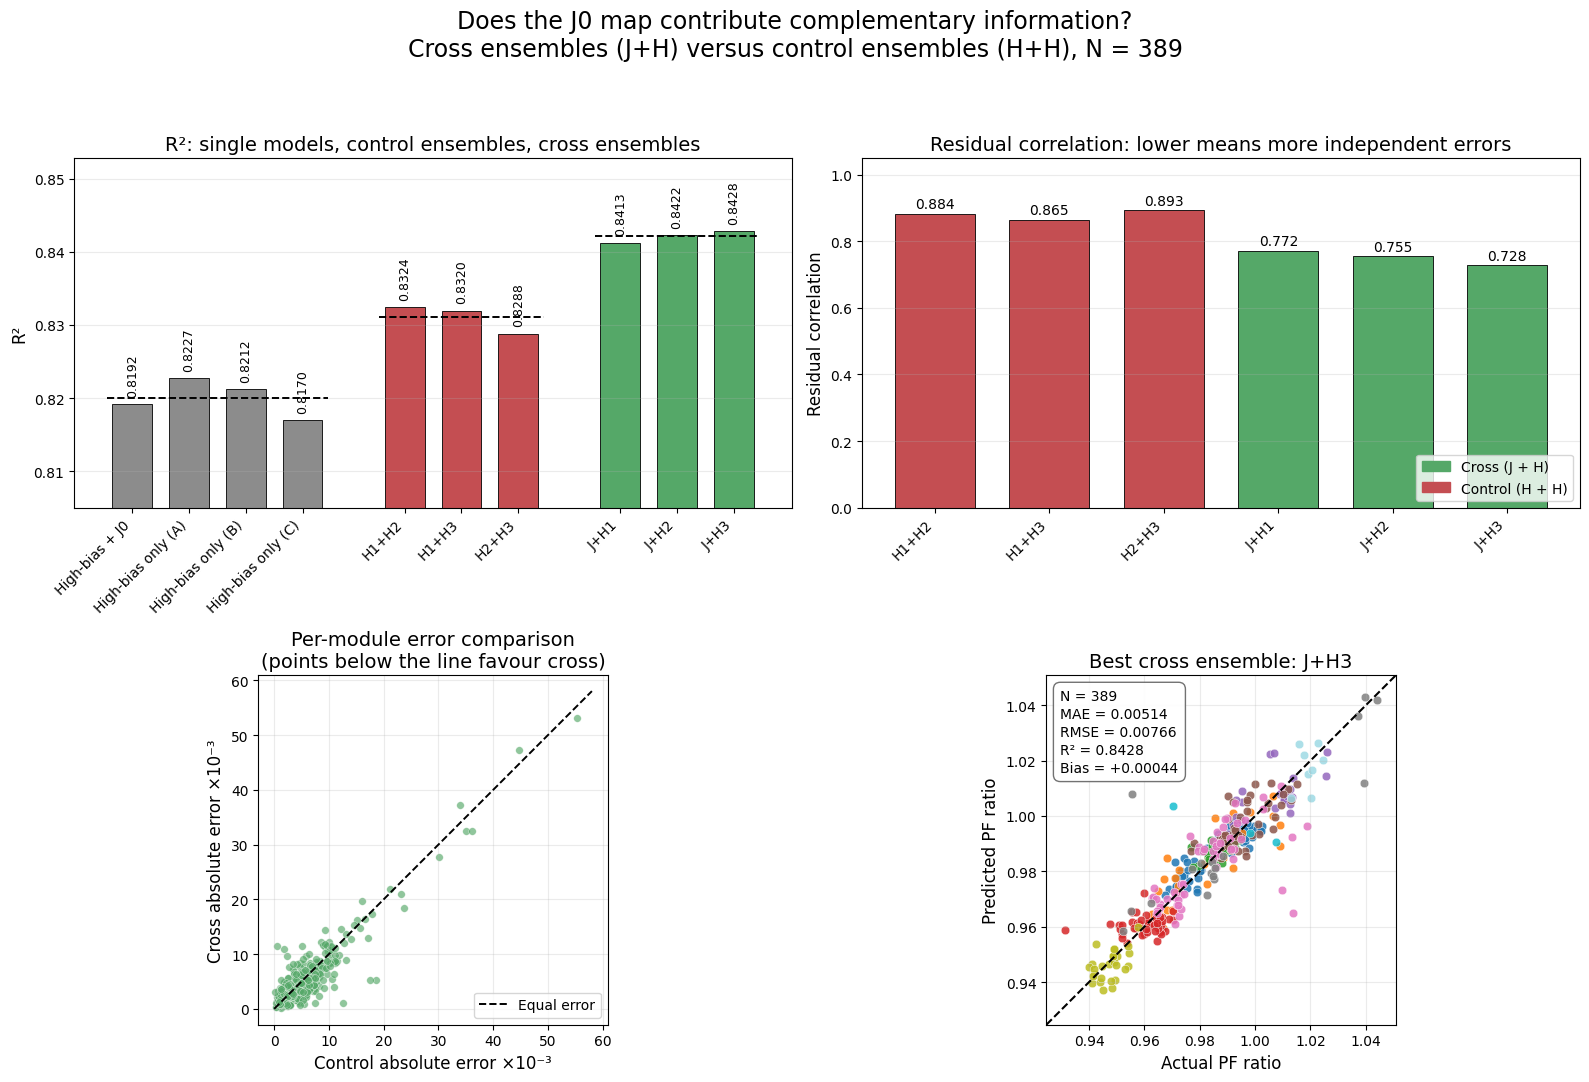


Saved:
- ensemble_cross_vs_control_figure.png
- ensemble_cross_vs_control_figure.pdf
- ensemble_cross_vs_control_metrics.csv
- ensemble_cross_vs_control_residual_correlations.csv
- ensemble_cross_vs_control_tests.csv
- ensemble_cross_vs_control_predictions.csv


In [9]:
"""
Ensemble analysis: does the J0 map contribute complementary information?

Design
------
Four models, all evaluated out-of-fold on the same 389 modules:

    J   = high-bias + J0      (J0 is derived from the low-bias image)
    H1  = high-bias only, seed A
    H2  = high-bias only, seed B
    H3  = high-bias only, seed C

These form two balanced groups of pairwise ensembles:

    CROSS   : J+H1, J+H2, J+H3        (different inputs)
    CONTROL : H1+H2, H1+H3, H2+H3     (identical inputs, seed differs only)

The control group captures the gain that comes purely from variance reduction
when averaging two models. Any excess of CROSS over CONTROL is what can be
attributed to complementary information carried by the J0 map.

Three lines of evidence produced by this script
-----------------------------------------------
1. R² and RMSE for every single model and every ensemble.

2. Residual correlation for each pair. This is the MECHANISM: if cross pairs
   show lower residual correlation than control pairs, that is precisely why
   averaging helps more. It requires no additional training and is far more
   stable than a difference in R².

3. Paired per-module Wilcoxon test. Because the ensemble pairs share member
   models (H2 appears in several pairs), the table rows are NOT independent
   and must not be compared with a t-test across rows. The fix is to average
   the absolute errors per module within each group first, then test those
   389 paired values.
"""

import os
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import mean_absolute_error, r2_score


# =========================================================
# CONFIG
# =========================================================
# Adjust the filenames below to match your outputs.
MODEL_FILES = {
    "J":  "cv5_convnext_base_highbias_j0_oof_test_predictions.csv",
    "H1": "cv5_convnext_base_highbias_only_oof_test_predictions.csv",
    "H2": "cv5_convnext_base_highbias_only_seedB_oof_test_predictions.csv",
    "H3": "cv5_convnext_base_highbias_only_seedC_oof_test_predictions.csv",
}

PHYSICS_MODEL = "J"                       # the model carrying the J0 channel
BASELINE_MODELS = ["H1", "H2", "H3"]      # high-bias only models

MODEL_LABELS = {
    "J":  "High-bias + J0",
    "H1": "High-bias only (A)",
    "H2": "High-bias only (B)",
    "H3": "High-bias only (C)",
}

OUTPUT_PREFIX = "ensemble_cross_vs_control"

# ---- Font sizes: change these to control all figure text ----
FONT = {
    "title": 14,          # panel titles
    "suptitle": 17,       # figure title
    "axis_label": 12,     # x and y axis labels
    "tick": 10,           # tick numbers
    "legend": 10,
    "annotation": 10,     # metric boxes and bar labels
}

FIGSIZE = (16, 11)
DPI = 300
COLOR_CROSS = "#55A868"
COLOR_CONTROL = "#C44E52"
COLOR_SINGLE = "0.55"


def apply_font_sizes():
    plt.rcParams.update({
        "axes.titlesize": FONT["title"],
        "axes.labelsize": FONT["axis_label"],
        "xtick.labelsize": FONT["tick"],
        "ytick.labelsize": FONT["tick"],
        "legend.fontsize": FONT["legend"],
        "figure.titlesize": FONT["suptitle"],
    })


# =========================================================
# LOAD
# =========================================================
def load_all(model_files):
    frames = {}

    for key, path in model_files.items():
        if not os.path.exists(path):
            raise FileNotFoundError(f"Model '{key}': file not found -> {path}")

        df = pd.read_csv(path)

        needed = {"sample_uid", "actual_pf_ratio", "predicted_pf_ratio"}
        missing = needed - set(df.columns)
        if missing:
            raise ValueError(f"Model '{key}' is missing columns: {sorted(missing)}")

        if df["sample_uid"].duplicated().any():
            raise ValueError(f"Model '{key}' contains duplicate sample_uid values.")

        frames[key] = df.set_index("sample_uid").sort_index()

    keys = list(frames)
    common = frames[keys[0]].index
    for k in keys[1:]:
        common = common.intersection(frames[k].index)

    if len(common) == 0:
        raise ValueError("The files share no sample_uid values.")

    for k in keys:
        if len(frames[k]) != len(common):
            print(
                f"WARNING: '{k}' has {len(frames[k])} modules, "
                f"common intersection is {len(common)}. Using the intersection."
            )
        frames[k] = frames[k].loc[common]

    actual = frames[keys[0]]["actual_pf_ratio"].to_numpy()

    for k in keys[1:]:
        if not np.allclose(actual, frames[k]["actual_pf_ratio"].to_numpy(), atol=1e-9):
            raise ValueError(
                f"Ground-truth PF ratios differ between '{keys[0]}' and '{k}'. "
                "These models are not on the same targets."
            )

    preds = {k: frames[k]["predicted_pf_ratio"].to_numpy() for k in keys}
    meta = frames[keys[0]]

    return actual, preds, meta


def metrics(actual, predicted):
    residual = predicted - actual
    return {
        "N": len(actual),
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": float(np.sqrt(np.mean(residual ** 2))),
        "R2": r2_score(actual, predicted),
        "Bias": float(np.mean(residual)),
    }


# =========================================================
# ANALYSIS
# =========================================================
def build_ensembles(preds):
    cross = {
        f"{PHYSICS_MODEL}+{h}": 0.5 * preds[PHYSICS_MODEL] + 0.5 * preds[h]
        for h in BASELINE_MODELS
    }

    control = {
        f"{x}+{y}": 0.5 * preds[x] + 0.5 * preds[y]
        for x, y in itertools.combinations(BASELINE_MODELS, 2)
    }

    return cross, control


def residual_correlations(actual, preds):
    rows = []
    keys = list(preds)

    for x, y in itertools.combinations(keys, 2):
        rx = preds[x] - actual
        ry = preds[y] - actual

        pair_type = "cross" if PHYSICS_MODEL in (x, y) else "control"

        rows.append({
            "pair": f"{x}+{y}",
            "type": pair_type,
            "residual_r": float(np.corrcoef(rx, ry)[0, 1]),
            "prediction_r": float(np.corrcoef(preds[x], preds[y])[0, 1]),
        })

    return pd.DataFrame(rows).sort_values(["type", "pair"]).reset_index(drop=True)


def exact_separation_test(cross_values, control_values):
    """
    Exact permutation test on the group R² values.

    Null hypothesis: the 'cross'/'control' labels carry no meaning, so every
    way of splitting the values into two groups is equally likely. With 3
    against 3 there are C(6,3) = 20 splits, so the smallest attainable
    one-sided p is 1/20 = 0.05. Perfect separation of the two groups gives
    exactly p = 0.05.
    """
    all_values = np.concatenate([cross_values, control_values])
    n_cross = len(cross_values)
    observed = np.mean(cross_values) - np.mean(control_values)

    count = 0
    total = 0

    for combo in itertools.combinations(range(len(all_values)), n_cross):
        mask = np.zeros(len(all_values), dtype=bool)
        mask[list(combo)] = True

        diff = np.mean(all_values[mask]) - np.mean(all_values[~mask])

        total += 1
        if diff >= observed - 1e-12:
            count += 1

    return observed, count / total, total


def paired_module_test(actual, cross, control):
    """
    Paired per-module Wilcoxon signed-rank test.

    Absolute errors are averaged within each group first, so that the
    dependence between pairs (member models are reused across pairs) is not
    counted as additional evidence.
    """
    ae_cross = np.mean([np.abs(p - actual) for p in cross.values()], axis=0)
    ae_control = np.mean([np.abs(p - actual) for p in control.values()], axis=0)

    w = stats.wilcoxon(ae_cross, ae_control)
    t = stats.ttest_rel(ae_cross, ae_control)

    return {
        "mean_ae_cross": float(np.mean(ae_cross)),
        "mean_ae_control": float(np.mean(ae_control)),
        "mean_difference": float(np.mean(ae_cross - ae_control)),
        "cross_better_n": int((ae_cross < ae_control).sum()),
        "n_total": len(actual),
        "wilcoxon_p": float(w.pvalue),
        "ttest_p": float(t.pvalue),
    }, ae_cross, ae_control


# =========================================================
# PANELS
# =========================================================
def panel_r2_comparison(ax, single_rows, cross_rows, control_rows):
    groups = [
        ("Single models", single_rows, COLOR_SINGLE),
        ("Control (H+H)", control_rows, COLOR_CONTROL),
        ("Cross (J+H)", cross_rows, COLOR_CROSS),
    ]

    x_pos = 0
    ticks, labels = [], []

    for name, rows, colour in groups:
        values = [r["R2"] for r in rows]
        xs = np.arange(len(values)) + x_pos

        ax.bar(xs, values, 0.7, color=colour, edgecolor="black", linewidth=0.6)

        for xi, r in zip(xs, rows):
            ax.text(xi, r["R2"] + 0.001, f"{r['R2']:.4f}",
                    ha="center", va="bottom", fontsize=FONT["annotation"] - 1,
                    rotation=90)

        if len(values) > 1:
            ax.hlines(np.mean(values), xs[0] - 0.45, xs[-1] + 0.45,
                      linestyle="--", color="black", linewidth=1.4)

        ticks.extend(xs)
        labels.extend([r["model"] for r in rows])
        x_pos += len(values) + 0.8

    lo = min(r["R2"] for rows in [single_rows, cross_rows, control_rows] for r in rows)
    hi = max(r["R2"] for rows in [single_rows, cross_rows, control_rows] for r in rows)
    ax.set_ylim(lo - 0.012, hi + 0.010)

    ax.set_xticks(ticks)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_ylabel("R²")
    ax.set_title("R²: single models, control ensembles, cross ensembles")
    ax.grid(True, alpha=0.25, axis="y")


def panel_residual_corr(ax, corr_df):
    colours = [COLOR_CROSS if t == "cross" else COLOR_CONTROL
               for t in corr_df["type"]]

    xs = np.arange(len(corr_df))
    ax.bar(xs, corr_df["residual_r"], 0.7, color=colours,
           edgecolor="black", linewidth=0.6)

    for xi, v in zip(xs, corr_df["residual_r"]):
        ax.text(xi, v + 0.008, f"{v:.3f}", ha="center", va="bottom",
                fontsize=FONT["annotation"])

    ax.set_xticks(xs)
    ax.set_xticklabels(corr_df["pair"], rotation=45, ha="right")
    ax.set_ylabel("Residual correlation")
    ax.set_title("Residual correlation: lower means more independent errors")
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.25, axis="y")

    handles = [
        plt.Rectangle((0, 0), 1, 1, color=COLOR_CROSS, label="Cross (J + H)"),
        plt.Rectangle((0, 0), 1, 1, color=COLOR_CONTROL, label="Control (H + H)"),
    ]
    ax.legend(handles=handles, loc="lower right")


def panel_paired_scatter(ax, ae_cross, ae_control):
    lim = max(ae_cross.max(), ae_control.max()) * 1.05

    ax.scatter(ae_control * 1000, ae_cross * 1000, s=30, alpha=0.65,
               color=COLOR_CROSS, edgecolors="white", linewidths=0.35)
    ax.plot([0, lim * 1000], [0, lim * 1000], "--", color="black", linewidth=1.4,
            label="Equal error")

    ax.set_xlabel("Control absolute error ×10⁻³")
    ax.set_ylabel("Cross absolute error ×10⁻³")
    ax.set_title("Per-module error comparison\n(points below the line favour cross)")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="lower right")


def panel_best_ensemble(ax, actual, pred, label, make_values=None):
    lo = min(actual.min(), pred.min())
    hi = max(actual.max(), pred.max())
    pad = (hi - lo) * 0.06
    lo, hi = lo - pad, hi + pad

    if make_values is not None:
        makes = sorted(pd.Series(make_values).astype(str).unique())
        cmap = plt.colormaps.get_cmap("tab20")
        palette = {m: cmap(i / max(1, len(makes) - 1)) for i, m in enumerate(makes)}

        for m in makes:
            sel = np.asarray(make_values).astype(str) == m
            ax.scatter(actual[sel], pred[sel], s=38, color=palette[m],
                       alpha=0.85, edgecolors="white", linewidths=0.35)
    else:
        ax.scatter(actual, pred, s=38, color=COLOR_CROSS, alpha=0.85,
                   edgecolors="white", linewidths=0.35)

    ax.plot([lo, hi], [lo, hi], "--", color="black", linewidth=1.5)

    m = metrics(actual, pred)

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Actual PF ratio")
    ax.set_ylabel("Predicted PF ratio")
    ax.set_title(f"Best cross ensemble: {label}")
    ax.grid(True, alpha=0.25)

    ax.text(
        0.04, 0.96,
        f"N = {m['N']}\nMAE = {m['MAE']:.5f}\nRMSE = {m['RMSE']:.5f}\n"
        f"R² = {m['R2']:.4f}\nBias = {m['Bias']:+.5f}",
        transform=ax.transAxes, ha="left", va="top",
        fontsize=FONT["annotation"], linespacing=1.35,
        bbox=dict(boxstyle="round,pad=0.5", facecolor="white",
                  edgecolor="0.4", alpha=0.92),
    )


# =========================================================
# MAIN
# =========================================================
def main():
    apply_font_sizes()

    actual, preds, meta = load_all(MODEL_FILES)
    print(f"Modules used: {len(actual)}")

    cross, control = build_ensembles(preds)

    single_rows = [
        {"model": MODEL_LABELS.get(k, k), **metrics(actual, preds[k])}
        for k in preds
    ]
    cross_rows = [{"model": k, **metrics(actual, v)} for k, v in cross.items()]
    control_rows = [{"model": k, **metrics(actual, v)} for k, v in control.items()]

    print("\n" + "=" * 78)
    print("SINGLE MODELS")
    print("=" * 78)
    print(pd.DataFrame(single_rows).to_string(
        index=False, float_format=lambda v: f"{v:.6f}"))

    print("\n" + "=" * 78)
    print("CONTROL ENSEMBLES (H+H, identical inputs)")
    print("=" * 78)
    print(pd.DataFrame(control_rows).to_string(
        index=False, float_format=lambda v: f"{v:.6f}"))

    print("\n" + "=" * 78)
    print("CROSS ENSEMBLES (J+H, different inputs)")
    print("=" * 78)
    print(pd.DataFrame(cross_rows).to_string(
        index=False, float_format=lambda v: f"{v:.6f}"))

    cross_r2 = np.array([r["R2"] for r in cross_rows])
    control_r2 = np.array([r["R2"] for r in control_rows])
    best_single_r2 = max(r["R2"] for r in single_rows)

    print("\n" + "=" * 78)
    print("GAIN DECOMPOSITION")
    print("=" * 78)
    print(f"  Best single model          : R² = {best_single_r2:.4f}")
    print(f"  Control  (mean ± sd)       : R² = {control_r2.mean():.4f} "
          f"± {control_r2.std(ddof=1):.4f}")
    print(f"  Cross    (mean ± sd)       : R² = {cross_r2.mean():.4f} "
          f"± {cross_r2.std(ddof=1):.4f}")
    print()
    print(f"  Gain from averaging alone  : {control_r2.mean() - best_single_r2:+.4f}")
    print(f"  Additional gain from J0    : {cross_r2.mean() - control_r2.mean():+.4f}")
    print(f"  Total                      : {cross_r2.mean() - best_single_r2:+.4f}")

    overlap = cross_r2.min() <= control_r2.max()
    print(f"\n  Lowest cross   : {cross_r2.min():.4f}")
    print(f"  Highest control: {control_r2.max():.4f}")
    print(f"  Fully separated: {'NO' if overlap else 'YES'}")

    # ---- Residual correlation ----
    corr_df = residual_correlations(actual, preds)

    print("\n" + "=" * 78)
    print("RESIDUAL CORRELATION (the mechanism)")
    print("=" * 78)
    print(corr_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

    r_cross = corr_df.loc[corr_df["type"] == "cross", "residual_r"]
    r_control = corr_df.loc[corr_df["type"] == "control", "residual_r"]
    print(f"\n  Cross mean   : {r_cross.mean():.4f}")
    print(f"  Control mean : {r_control.mean():.4f}")
    print(f"  Difference   : {r_cross.mean() - r_control.mean():+.4f}")

    # ---- Tests ----
    observed, p_exact, n_perm = exact_separation_test(cross_r2, control_r2)

    print("\n" + "=" * 78)
    print("STATISTICAL TESTS")
    print("=" * 78)
    print(f"Exact permutation test on group R² ({len(cross_r2)} vs {len(control_r2)}):")
    print(f"  observed mean difference : {observed:+.4f}")
    print(f"  one-sided p              : {p_exact:.4f}  "
          f"(from {n_perm} permutations, minimum attainable p = {1 / n_perm:.4f})")

    test, ae_cross, ae_control = paired_module_test(actual, cross, control)

    print(f"\nPaired per-module Wilcoxon (group-averaged absolute error):")
    print(f"  Cross MAE       : {test['mean_ae_cross']:.6f}")
    print(f"  Control MAE     : {test['mean_ae_control']:.6f}")
    print(f"  Difference      : {test['mean_difference']:+.6f}")
    print(f"  Cross better on : {test['cross_better_n']} / {test['n_total']} modules")
    print(f"  Wilcoxon p      : {test['wilcoxon_p']:.6f}")
    print(f"  t-test p        : {test['ttest_p']:.6f}")

    # ---- Figure ----
    best_cross_name = max(cross, key=lambda k: r2_score(actual, cross[k]))
    make_values = meta["make_plot"].to_numpy() if "make_plot" in meta.columns else None

    fig, axes = plt.subplots(2, 2, figsize=FIGSIZE)

    panel_r2_comparison(axes[0, 0], single_rows, cross_rows, control_rows)
    panel_residual_corr(axes[0, 1], corr_df)
    panel_paired_scatter(axes[1, 0], ae_cross, ae_control)
    panel_best_ensemble(axes[1, 1], actual, cross[best_cross_name],
                        best_cross_name, make_values)

    fig.suptitle(
        "Does the J0 map contribute complementary information?\n"
        f"Cross ensembles (J+H) versus control ensembles (H+H), N = {len(actual)}",
        y=0.98,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.94])

    fig.savefig(f"{OUTPUT_PREFIX}_figure.png", dpi=DPI, bbox_inches="tight")
    fig.savefig(f"{OUTPUT_PREFIX}_figure.pdf", bbox_inches="tight")
    plt.show()

    # ---- Save ----
    all_rows = (
        [{"group": "single", **r} for r in single_rows]
        + [{"group": "control", **r} for r in control_rows]
        + [{"group": "cross", **r} for r in cross_rows]
    )
    pd.DataFrame(all_rows).to_csv(f"{OUTPUT_PREFIX}_metrics.csv", index=False)
    corr_df.to_csv(f"{OUTPUT_PREFIX}_residual_correlations.csv", index=False)
    pd.DataFrame([{
        "permutation_observed_diff": observed,
        "permutation_p_one_sided": p_exact,
        "n_permutations": n_perm,
        **test,
    }]).to_csv(f"{OUTPUT_PREFIX}_tests.csv", index=False)

    out = meta[[c for c in ["Make", "make_plot", "fold"] if c in meta.columns]].copy()
    out["actual_pf_ratio"] = actual
    for k, v in preds.items():
        out[f"pred_{k}"] = v
    for k, v in {**cross, **control}.items():
        out[f"ens_{k}"] = v
    out.to_csv(f"{OUTPUT_PREFIX}_predictions.csv")

    print("\nSaved:")
    for suffix in ["figure.png", "figure.pdf", "metrics.csv",
                   "residual_correlations.csv", "tests.csv", "predictions.csv"]:
        print(f"- {OUTPUT_PREFIX}_{suffix}")


if __name__ == "__main__":
    main()


In [10]:
import pandas as pd, numpy as np
from scipy import stats

def load(path):
    return pd.read_csv(path).set_index('sample_uid').sort_index()

J  = load('cv5_convnext_base_highbias_j0_oof_test_predictions.csv')
H1 = load('cv5_convnext_base_highbias_only_oof_test_predictions.csv')
H2 = load('cv5_convnext_base_highbias_only_seedB_oof_test_predictions.csv')

y = J['actual_pf_ratio'].values

cross   = 0.5 * J['predicted_pf_ratio'].values  + 0.5 * H1['predicted_pf_ratio'].values
control = 0.5 * H1['predicted_pf_ratio'].values + 0.5 * H2['predicted_pf_ratio'].values

ae_cross   = np.abs(cross - y)
ae_control = np.abs(control - y)

w = stats.wilcoxon(ae_cross, ae_control)
print(f"selisih rata-rata AE : {np.mean(ae_cross - ae_control):+.6f}")
print(f"cross lebih baik pada: {(ae_cross < ae_control).sum()} / {len(y)} modul")
print(f"Wilcoxon p           : {w.pvalue:.6f}")

selisih rata-rata AE : -0.000091
cross lebih baik pada: 199 / 389 modul
Wilcoxon p           : 0.650950
